In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pywt
from scipy.signal import hilbert
from scipy.ndimage import binary_closing, binary_opening
from typing import Dict, Any, Tuple, Optional, List
from scipy.stats import skew, kurtosis, entropy
import joblib
import os

## Funciones de Procesamiento


In [4]:
# =============================================================================
# SECCIÓN 1: UTILIDADES BÁSICAS 
# =============================================================================

def muestras_por_ciclo(fs: int, f_nom: float = 60.0) -> int:
    """Número de muestras por ciclo de la señal de red."""
    return int(round(fs / f_nom))

def convertir_mascara_a_intervalos(mascara: np.ndarray) -> List[Tuple[int, int]]:
    """Convierte una máscara booleana en intervalos (ini, fin)."""
    if mascara.size == 0 or not mascara.any():
        return []
    m = mascara.astype(np.int8)
    dm = np.diff(np.r_[0, m, 0])
    inicios = np.flatnonzero(dm == 1)
    finales = np.flatnonzero(dm == -1)
    return list(zip(inicios, finales))

def unir_intervalos(intervalos: List[Tuple[int, int]], margen_muestras: int) -> List[Tuple[int, int]]:
    """Une intervalos cercanos o solapados."""
    if not intervalos:
        return []
    intervalos.sort(key=lambda x: x[0])
    union = [intervalos[0]]
    for ini, fin in intervalos[1:]:
        u_ini, u_fin = union[-1]
        if ini <= (u_fin + margen_muestras):
            union[-1] = (u_ini, max(u_fin, fin))
        else:
            union.append((ini, fin))
    return union

def postprocesar_mascara(mascara: np.ndarray, mpc: int) -> np.ndarray:
    """Suaviza la máscara eliminando picos y rellenando huecos pequeños."""
    se_cierre = np.ones(max(1, mpc // 4), dtype=bool)
    se_apertura = np.ones(max(1, mpc // 16), dtype=bool)
    m = binary_closing(mascara, structure=se_cierre)
    m = binary_opening(m, structure=se_apertura)
    return m


def rms_nominal(senal: np.ndarray, fs: int, f_nom: float = 60.0, percentil_ref: float = 99.0) -> float:
    muestras_por_ciclo = int(fs / f_nom)
    hop = muestras_por_ciclo // 2
    if hop <= 0: return 0.0
    rms_vals = [
        np.sqrt(np.mean(senal[i : i + muestras_por_ciclo]**2))
        for i in range(0, len(senal) - muestras_por_ciclo + 1, hop)
    ]
    return np.percentile(rms_vals, percentil_ref) if rms_vals else 0.0

# =============================================================================
# SECCIÓN 2: GENERACIÓN DE MÁSCARAS 
# =============================================================================
def generar_mascara_rms(senal: np.ndarray, fs: int, f_nom: float = 60.0,
                        umbral_sag: float = 0.90, percentil_ref: float = 99.0, umbral_normalizado:float = 0.7) -> np.ndarray:
    """Máscara basada en RMS por medio ciclo con solapamiento 50%."""
    mpc = muestras_por_ciclo(fs, f_nom)
    hop = mpc  // 2  
    if hop <= 0:
        return np.zeros(len(senal), dtype=bool)
    rms_vals, centros = [], []
    for ini in range(0, len(senal) - hop + 1, hop):
        fin = min(ini + mpc, len(senal))
        if fin - ini < hop: break
        rms_vals.append(np.sqrt(np.mean(senal[ini:fin]**2)))
        centros.append((ini + fin) // 2)
    if not rms_vals:
        return np.zeros(len(senal), dtype=bool)
    v_nominal = np.percentile(rms_vals, percentil_ref)
    v_nominal = np.median([v_nominal,umbral_normalizado]) 
    umbral = umbral_sag * v_nominal
    # print(umbral)
    # print(rms_vals)
    # print(centros)
    mascara = np.zeros(len(senal), dtype=bool)
    for centro, rms_val in zip(centros, rms_vals):
        if rms_val < umbral:
            ini_p = max(0, centro - hop)
            fin_p = min(len(senal), centro + hop)
            mascara[ini_p:fin_p] = True
    return postprocesar_mascara(mascara, mpc)

def generar_mascara_swt(senal: np.ndarray, fs: int, wavelet: str = 'db4', niveles: int = 4, percentil_ref: float = 95.0) -> np.ndarray:
    """Máscara basada en energía de la SWT (Wavelet Estacionaria)."""
    original_len = len(senal)
    required_divisor = 2**niveles
    padding_needed = (required_divisor - (original_len % required_divisor)) % required_divisor
    if padding_needed > 0:
        senal_padded = np.pad(senal, (0, padding_needed), mode='reflect')
    else:
        senal_padded = senal
    max_level = pywt.swt_max_level(len(senal_padded))
    niveles_a_usar = min(niveles, max_level)
    if niveles_a_usar < 1:
        return np.zeros(original_len, dtype=bool)
    coefs = pywt.swt(senal_padded, wavelet, level=niveles_a_usar)
    energia = np.sum([cD**2 for (_, cD) in coefs], axis=0)
    umbral = np.percentile(energia, percentil_ref)
    mascara_padded = energia > umbral
    mascara_original = mascara_padded[:original_len]
    #mpc = muestras_por_ciclo(fs)
    return mascara_original

def generar_mascara_hilbert(senal: np.ndarray, fs: int, percentil_ref: float = 95.0, umbral_sag: float = 0.90, umbral_swell: float = 1.10) -> np.ndarray:
    """Máscara basada en la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    v_ref = np.percentile(envolvente, percentil_ref)
    if v_ref < 1e-9:
        return np.zeros_like(envolvente, dtype=bool)
    caidas = envolvente < (umbral_sag * v_ref)
    subidas = envolvente > (umbral_swell * v_ref)
    mpc = muestras_por_ciclo(fs)
    return postprocesar_mascara(caidas | subidas, mpc)

# =============================================================================
# SECCIÓN 3: DETECTORES DE EVENTOS INDIVIDUALES
# =============================================================================

def detectar_eventos_rms(senal: np.ndarray, fs: int, umbral_sag: float = 0.90,
                         ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_rms(senal, fs, umbral_sag=umbral_sag)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

def detectar_eventos_hilbert(senal: np.ndarray, fs: int, umbral_sag: float = 0.90,
                             umbral_swell: float = 1.1, ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_hilbert(senal, fs, umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

def detectar_eventos_swt(senal: np.ndarray, fs: int, ciclos_minimos: float = 0.1) -> List[Tuple[int, int]]:
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_swt(senal, fs)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

# =============================================================================
# SECCIÓN 4: DETECTOR AVANZADO CON FUSIÓN
# =============================================================================
def detectar_eventos_con_fusion(senal: np.ndarray, fs: int, umbral_sag: float = 0.90,
                                umbral_swell: float = 1.1, ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    """
    Usa RMS como Región de Interés (ROI) para filtrar a 
    Hilbert y SWT, y luego refina los bordes del RMS con la mediana de las 
    sugerencias de los asistentes dentro de la ROI.
    """
    mpc = muestras_por_ciclo(fs)
    
    # Se generan las tres máscaras base.
    rms_mask = generar_mascara_rms(senal, fs, umbral_sag=umbral_sag)
    swt_mask = generar_mascara_swt(senal,fs)
    hilbert_mask = generar_mascara_hilbert(senal,fs, umbral_sag=umbral_sag, umbral_swell=umbral_swell)

    # Se filtran las máscaras de los asistentes para que solo existan DENTRO de la máscara del RMS.
    h_mask_filtrada = hilbert_mask & rms_mask
    w_mask_filtrada = swt_mask & rms_mask
    
    # Se extraen todos los puntos de borde (inicio y fin) de los asistentes ya filtrados.
    puntos_h = convertir_mascara_a_intervalos(h_mask_filtrada)
    puntos_w = convertir_mascara_a_intervalos(w_mask_filtrada)
    
    #print('puntos_h',puntos_h)
    
    #print('puntos_w',puntos_w)


    # Creamos dos listas: una con todas las sugerencias de INICIO y otra con las de FIN.
    inicios_sugeridos = np.array(sorted([ini for ini, fin in puntos_h] + [ini for ini, fin in puntos_w]))
    fines_sugeridos = np.array(sorted([fin for ini, fin in puntos_h] + [fin for ini, fin in puntos_w]))


    # Se obtienen los intervalos del RMS, que son nuestra guía principal.
    intervalos_guia_rms = convertir_mascara_a_intervalos(rms_mask)
    #print('intervalos_guia_rms',intervalos_guia_rms)
    eventos_refinados = []
    
    for ini_rms, fin_rms in intervalos_guia_rms:
        # Definimos una pequeña ventana de búsqueda alrededor de los bordes del RMS.
        ventana = mpc 
        #print('ventana',ventana)
        # Para el INICIO:
        # Buscamos todas las sugerencias de inicio que estén cerca del inicio del RMS.
        candidatos_ini = inicios_sugeridos[(inicios_sugeridos >= ini_rms - ventana) & 
                                            (inicios_sugeridos <= ini_rms + ventana)]
        # print('candidatos_ini',candidatos_ini)
        #print('ini_rms',ini_rms)
        # El nuevo inicio será la mediana de esas sugerencias. Si no hay, se queda el del RMS.
        nuevo_inicio = int(np.median(candidatos_ini)) if candidatos_ini.size > 0 else ini_rms

        # Para el FIN:
        # Buscamos todas las sugerencias de fin que estén cerca del fin del RMS.
        candidatos_fin = fines_sugeridos[(fines_sugeridos >= fin_rms - ventana) & 
                                          (fines_sugeridos <= fin_rms + ventana)]
        #print('candidatos_fin',candidatos_fin)
        #print('fin_rms',fin_rms)
        # El nuevo fin será la mediana.
        nuevo_fin = int(np.median(candidatos_fin)) if candidatos_fin.size > 0 else fin_rms
        
        if nuevo_fin > nuevo_inicio:
            eventos_refinados.append((nuevo_inicio, nuevo_fin))

    # --- PASO 5: Unir y filtrar como siempre ---
    unidos = unir_intervalos(eventos_refinados, margen_muestras=mpc // 2)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in unidos if (f - i) >= min_duracion]

# =============================================================================
# SECCIÓN 5: ORQUESTADORES TRIFÁSICOS 
# =============================================================================
def segmentar_evento_trifasico(va, vb, vc, fs, umbral_sag=0.97, umbral_swell=1.1):

    # 1. Detectar eventos en cada fase de forma independiente usando tu función
    intervalos_a = detectar_eventos_con_fusion(va, fs,umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    intervalos_b = detectar_eventos_con_fusion(vb, fs,umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    intervalos_c = detectar_eventos_con_fusion(vc, fs,umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    # 2. Juntar todos los intervalos encontrados en una sola lista
    todos_intervalos = intervalos_a + intervalos_b + intervalos_c
    #print('Todos_intervalos',todos_intervalos)
    # Si no se encontró ningún evento en ninguna fase, devuelve las señales originales
    if not todos_intervalos:
        return va, vb, vc

    # 3. Encontrar el inicio más temprano y el fin más tardío
    t_inicio_global = min(ini for ini, fin in todos_intervalos)
    t_fin_global = max(fin for ini, fin in todos_intervalos)

    # 4. Recortar las tres señales originales usando el rango global
    return va[t_inicio_global:t_fin_global], vb[t_inicio_global:t_fin_global], vc[t_inicio_global:t_fin_global]

def encontrar_intervalo_global(va, vb, vc, fs, umbral_sag=0.97, umbral_swell=1.1):
    """Encuentra el inicio y fin global de un evento trifásico."""
    intervalos_a = detectar_eventos_con_fusion(va, fs,umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    intervalos_b = detectar_eventos_con_fusion(vb, fs,umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    intervalos_c = detectar_eventos_con_fusion(vc, fs,umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    
    todos_intervalos = intervalos_a + intervalos_b + intervalos_c
    if not todos_intervalos:
        return None, None

    mpc = muestras_por_ciclo(fs)
    intervalos_unidos = unir_intervalos(todos_intervalos, margen_muestras=mpc // 2)

    t_inicio_global = min(ini for ini, fin in intervalos_unidos)
    t_fin_global = max(fin for ini, fin in intervalos_unidos)
    
    return t_inicio_global, t_fin_global

## Fucniones de Caracteristicas

In [5]:
# ==============================================================================
# 1. Dominio del Tiempo
# ==============================================================================
def caracteristicas_tiempo(segmento: np.ndarray, rms_nominal: float) -> dict:
    """Extrae las características seleccionadas del dominio del tiempo."""
    
    rms_segmento_val = np.sqrt(np.mean(segmento**2))
    profundidad_relativa_val = rms_segmento_val / rms_nominal if rms_nominal > 1e-6 else 0.0
    pico_abs = np.max(np.abs(segmento))
    factor_cresta_val = pico_abs / rms_segmento_val if rms_segmento_val > 1e-6 else 0.0
    curtosis_val = kurtosis(segmento)
    
    return {
        'rms_segmento': rms_segmento_val,
        'profundidad_relativa': profundidad_relativa_val,
        'factor_cresta': factor_cresta_val,
        'curtosis': curtosis_val,
    }

# ==============================================================================
# 2. Dominio de la Frecuencia 
# ==============================================================================
def caracteristicas_frecuencia(segmento: np.ndarray) -> dict:
    """Extrae únicamente la energía espectral (FFT)."""
    n = len(segmento)
    if n < 2: return {'fft_energia': 0}

    fft_vals = np.fft.fft(segmento)[:n // 2]
    psd = np.abs(fft_vals)**2 / n
    energia_espectral = np.sum(psd)
    
    return {
        'fft_energia': energia_espectral,
    }

# ==============================================================================
# 3. Dominio Wavelet y Envolvente 
# ==============================================================================
def caracteristicas_wavelet(segmento: np.ndarray, wavelet: str = 'db4', max_level: int = 4) -> dict:
    """Extrae energía, entropía y desviación estándar de los coeficientes wavelet."""
    coeffs = pywt.wavedec(segmento, wavelet, level=max_level)
    caracteristicas = {}
    
    for i in range(1, len(coeffs)):
        nivel_coeffs = coeffs[-i]
        nivel = i
        
        caracteristicas[f'wavelet_energia_cD{nivel}'] = np.sum(nivel_coeffs**2)
        
        energia = caracteristicas[f'wavelet_energia_cD{nivel}']
        p = (nivel_coeffs**2) / energia if energia > 1e-6 else 0
        caracteristicas[f'wavelet_entropia_cD{nivel}'] = -np.sum(p * np.log2(p + 1e-12))
        
        caracteristicas[f'wavelet_std_cD{nivel}'] = np.std(nivel_coeffs)
        
    return caracteristicas

def caracteristicas_envolvente(senal: np.ndarray) -> dict:
    """Calcula la media y desviación estándar de la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    return {
        'env_media': np.mean(envolvente),
        'env_std': np.std(envolvente)
    }

# ==============================================================================
# 4. FUNCIÓN MAESTRA 
# ==============================================================================
def extraer_caracteristicas(segmento_evento: np.ndarray, fs: int, rms_nominal_val: float) -> dict:
    caracteristicas = {}
    # Llama a las versiones ajustadas y a las que no necesitaron cambios
    caracteristicas.update(caracteristicas_tiempo(segmento_evento, rms_nominal_val))
    caracteristicas.update(caracteristicas_frecuencia(segmento_evento))
    caracteristicas.update(caracteristicas_wavelet(segmento_evento))
    caracteristicas.update(caracteristicas_envolvente(segmento_evento))
    # La lista final de características que se quiere mantener
    caracteristicas_top_1_requeridas = [
        'curtosis', 'env_media', 'env_std', 'factor_cresta', 'fft_energia', 
        'profundidad_relativa', 'rms_segmento', 'wavelet_energia_cD1', 
        'wavelet_energia_cD2', 'wavelet_energia_cD3', 'wavelet_energia_cD4', 
        'wavelet_entropia_cD1', 'wavelet_entropia_cD2', 'wavelet_entropia_cD3', 
        'wavelet_entropia_cD4', 'wavelet_std_cD1','wavelet_std_cD2','wavelet_std_cD3','wavelet_std_cD4'
    ]
    
    # Filtrar el diccionario para devolver solo las claves requeridas
    caracteristicas_filtradas = {clave: valor for clave, valor in caracteristicas.items() if clave in caracteristicas_top_1_requeridas}
    
    return caracteristicas_filtradas
# =============================================================================
# SECCIÓN 5: FUNCIONES DE TRANSFORMACIÓN Y EXTRACCIÓN DE CARACTERÍSTICAS
# =============================================================================\
    
def calcular_transformaciones_trifasicas(va, vb, vc):
    """
    Calcula las Componentes Simétricas (V0, V1, V2) y la Transformada de Clarke.
    """
    a = np.exp(1j * 2 * np.pi / 3)
    va_c, vb_c, vc_c = va.astype(complex), vb.astype(complex), vc.astype(complex)
    
    # --- CÁLCULO AÑADIDO ---
    v0 = (1/3) * (va_c + vb_c + vc_c)
    
    v1 = (1/3) * (va_c + a * vb_c + a**2 * vc_c)
    v2 = (1/3) * (va_c + a**2 * vb_c + a * vc_c)
    
    v_alpha = (2/3) * (va - 0.5 * vb - 0.5 * vc)
    v_beta = (2/3) * (np.sqrt(3)/2 * vb - np.sqrt(3)/2 * vc)
    
    # --- RETURN ACTUALIZADO ---
    return v0, v1, v2, v_alpha, v_beta

def extraer_caracteristicas_trifasicas(va_seg, vb_seg, vc_seg, fs, rms_nominal_val):
    """
    Versión definitiva que fusiona las características más potentes para resolver
    las confusiones específicas del dataset generado.
    """
    v0, v1, v2, _, _ = calcular_transformaciones_trifasicas(va_seg, vb_seg, vc_seg)
    v0_mag, v1_mag, v2_mag = np.abs(v0), np.abs(v1), np.abs(v2)
    features = {}
    print(rms_nominal_val)
    # --- Características de Magnitud Fundamentales ---
    rms_v0_temp = np.sqrt(np.mean(v0_mag**2))
    rms_v1_temp = np.sqrt(np.mean(v1_mag**2))
    rms_v2_temp = np.sqrt(np.mean(v2_mag**2))
    features['rms_V0mag'] = rms_v0_temp
    features['rms_V1mag'] = rms_v1_temp
    features['rms_V2mag'] = rms_v2_temp
    features['profundidad_V1mag'] = rms_v1_temp / rms_nominal_val if rms_nominal_val > 1e-6 else 0.0
    features['vuf'] = rms_v2_temp / rms_v1_temp if rms_v1_temp > 1e-6 else 0.0


    rms_a = np.sqrt(np.mean(va_seg**2))
    rms_b = np.sqrt(np.mean(vb_seg**2))
    rms_c = np.sqrt(np.mean(vc_seg**2))
    
    # Experto 1: Simetría Geométrica
    rms_sorted = np.sort([rms_a, rms_b, rms_c])
    rms_min, rms_mid, rms_max = rms_sorted[0], rms_sorted[1], rms_sorted[2]
    denominator = rms_max - rms_min
    features['rms_asymmetry_ratio'] = (rms_mid - rms_min) / denominator if denominator > 1e-6 else 0.0

    # Experto 2: Simetría de Energía
    features['unbalance_index'] = (rms_v0_temp + rms_v2_temp) / rms_v1_temp if rms_v1_temp > 1e-6 else 0.0
    
    # Experto 3: Simetría de Forma
    if len(va_seg) > 1:
        corr_matrix = np.corrcoef([va_seg, vb_seg, vc_seg])
        corr_values = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
        features['min_corr_abc'] = np.min(corr_values) if len(corr_values) > 0 else 1.0
    else:
        features['min_corr_abc'] = 1.0

    # --- Para distinguir fallas con y sin tierra (asumiendo que corriges C vs E) ---
    if pywt.dwt_max_level(len(v0_mag), 'db4') > 0:
        coeffs_v0 = pywt.wavedec(v0_mag, 'db4', level=1)
        features['wavelet_energia_cD1_V0mag'] = np.sum(coeffs_v0[1]**2)
    else:
        features['wavelet_energia_cD1_V0mag'] = 0.0

    # --- Características Auxiliares de Contexto ---
    umbral_sag = rms_nominal_val * 0.90 
    features['fase_afectada_A'] = 1 if rms_a < umbral_sag else 0
    features['fase_afectada_B'] = 1 if rms_b < umbral_sag else 0
    features['fase_afectada_C'] = 1 if rms_c < umbral_sag else 0
    fases_afectadas_count = features['fase_afectada_A'] + features['fase_afectada_B'] + features['fase_afectada_C']
    features['fase_afectada_N'] = 1 if fases_afectadas_count == 0 else 0
            
    return features


## Graficar Mascara

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# --- Configuración del Estilo de Gráficos ---
def _setup_academic_style():
    """Configura Matplotlib para un estilo visual formal/académico."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 16
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['lines.linewidth'] = 1.5

# --- Función de Visualización (Corregida y Refactorizada) ---
def visualizar_segmentacion_completa(va, vb, vc, fs, umbral_sag, umbral_swell, signal_id):
    """
    Genera un gráfico de 5 paneles para visualizar el proceso de segmentación.
    """
    _setup_academic_style()
    
    num_muestras = len(va)
    t = np.arange(num_muestras) / fs

    # --- Crear figura de 5 paneles ---
    fig, axes = plt.subplots(5, 1, figsize=(15, 12), sharex=True)

    # --- 1. Panel de la Señal Original ---
    axes[0].plot(t, va, label='Fase A')
    axes[0].plot(t, vb, label='Fase B')
    axes[0].plot(t, vc, label='Fase C')
    axes[0].set_ylabel('(Amplitud p.u.)')
    axes[0].set_title('Señal Original')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--')

    # --- 2. Paneles de Máscaras (Refactorizado con un Bucle for) ---
    fases = [(va, 'A'), (vb, 'B'), (vc, 'C')]
    for i, (fase_signal, fase_label) in enumerate(fases):
        ax = axes[i + 1] # Usar los paneles 1, 2 y 3
        
        # Calcular máscaras solo para la fase actual dentro del bucle
        mascara_rms = generar_mascara_rms(fase_signal, fs)
        mascara_swt = generar_mascara_swt(fase_signal, fs)
        mascara_hilbert = generar_mascara_hilbert(fase_signal, fs)
        
        ax.plot(t, fase_signal, color='blue', alpha=1, label=f'Fase {fase_label}')
        ax.fill_between(t, -1.5, 1.5, where=mascara_rms, alpha=0.4, label='Máscara RMS', step='post')
        ax.fill_between(t, -1.5, 1.5, where=mascara_hilbert, alpha=0.4, label='Máscara Hilbert', step='post')
        ax.fill_between(t, -1.5, 1.5, where=mascara_swt, alpha=0.4, label='Máscara SWT', step='post')
        ax.set_ylabel('Amplitud (p.u)')
        ax.set_title(f'Máscaras Individuales (sobre Fase {fase_label})')
        ax.set_ylim(-1.5, 1.5)
        ax.legend(loc='upper right')
        ax.grid(True, linestyle='--')

    # --- 3. Panel Final (Corregido) ---
    ax_final = axes[4]
    
    # Encontrar el segmento final trifásico
    t_inicio_idx, t_fin_idx = encontrar_intervalo_global(va, vb, vc, fs,umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    #print(t_inicio_idx)
    #print(t_fin_idx)

    # Dibujar las señales originales en gris como fondo
    ax_final.plot(t, va, color='lightgray', alpha=0.7)
    ax_final.plot(t, vb, color='lightgray', alpha=0.7)
    ax_final.plot(t, vc, color='lightgray', alpha=0.7)
    
    if t_inicio_idx is not None and t_fin_idx is not None:
        t_segmento = t[t_inicio_idx:t_fin_idx]
        
        # CORREGIDO: Dibujar en el panel correcto (ax_final, que es axes[4])
        ax_final.axvspan(t[t_inicio_idx], t[t_fin_idx], color='salmon', alpha=0.4, label='Segmento Global')
        ax_final.plot(t_segmento, va[t_inicio_idx:t_fin_idx], color='blue', label='Fase A.')
        ax_final.plot(t_segmento, vb[t_inicio_idx:t_fin_idx], color='orange', label='Fase B.')
        ax_final.plot(t_segmento, vc[t_inicio_idx:t_fin_idx], color='green', label='Fase C.')

    ax_final.set_xlabel('Tiempo (s)')
    ax_final.set_ylabel('Amplitud (p.u.)')
    ax_final.set_title('Resultado de Segmentación Trifásica')
    ax_final.legend(loc='upper right')
    ax_final.grid(True, linestyle='--')
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('Segmento.svg')
    plt.show()

## Trifasico

--- 1. Cargando modelo, encoder y orden de columnas (Trifásico)... ---
¡Archivos trifásicos cargados exitosamente!

--- 2. Cargando y preparando la señal 'Sag_5' de Señales_IEEE\Señales_IEEE.csv ---
Frecuencia de muestreo: 15370.01 Hz
RMS Nominal de referencia: 0.7000 p.u.
(379, 736)
Evento detectado (tiempo): 0.02465841566542319 a 0.047885472110162176
0.7
Caracteristicas: {'rms_V0mag': np.float64(0.29646238569778355), 'rms_V1mag': np.float64(0.4078143863908474), 'rms_V2mag': np.float64(0.4078143863908474), 'profundidad_V1mag': np.float64(0.5825919805583535), 'vuf': np.float64(1.0), 'rms_asymmetry_ratio': np.float64(0.9642787051002603), 'unbalance_index': np.float64(1.7269542115016399), 'min_corr_abc': np.float64(-0.8019590804700764), 'wavelet_energia_cD1_V0mag': np.float64(0.012990343497254267), 'fase_afectada_A': 1, 'fase_afectada_B': 0, 'fase_afectada_C': 0, 'fase_afectada_N': 0}

 El evento trifásico ha sido clasificado como: 'Sag_D'

Confianza del modelo:
 - Sag_D                |

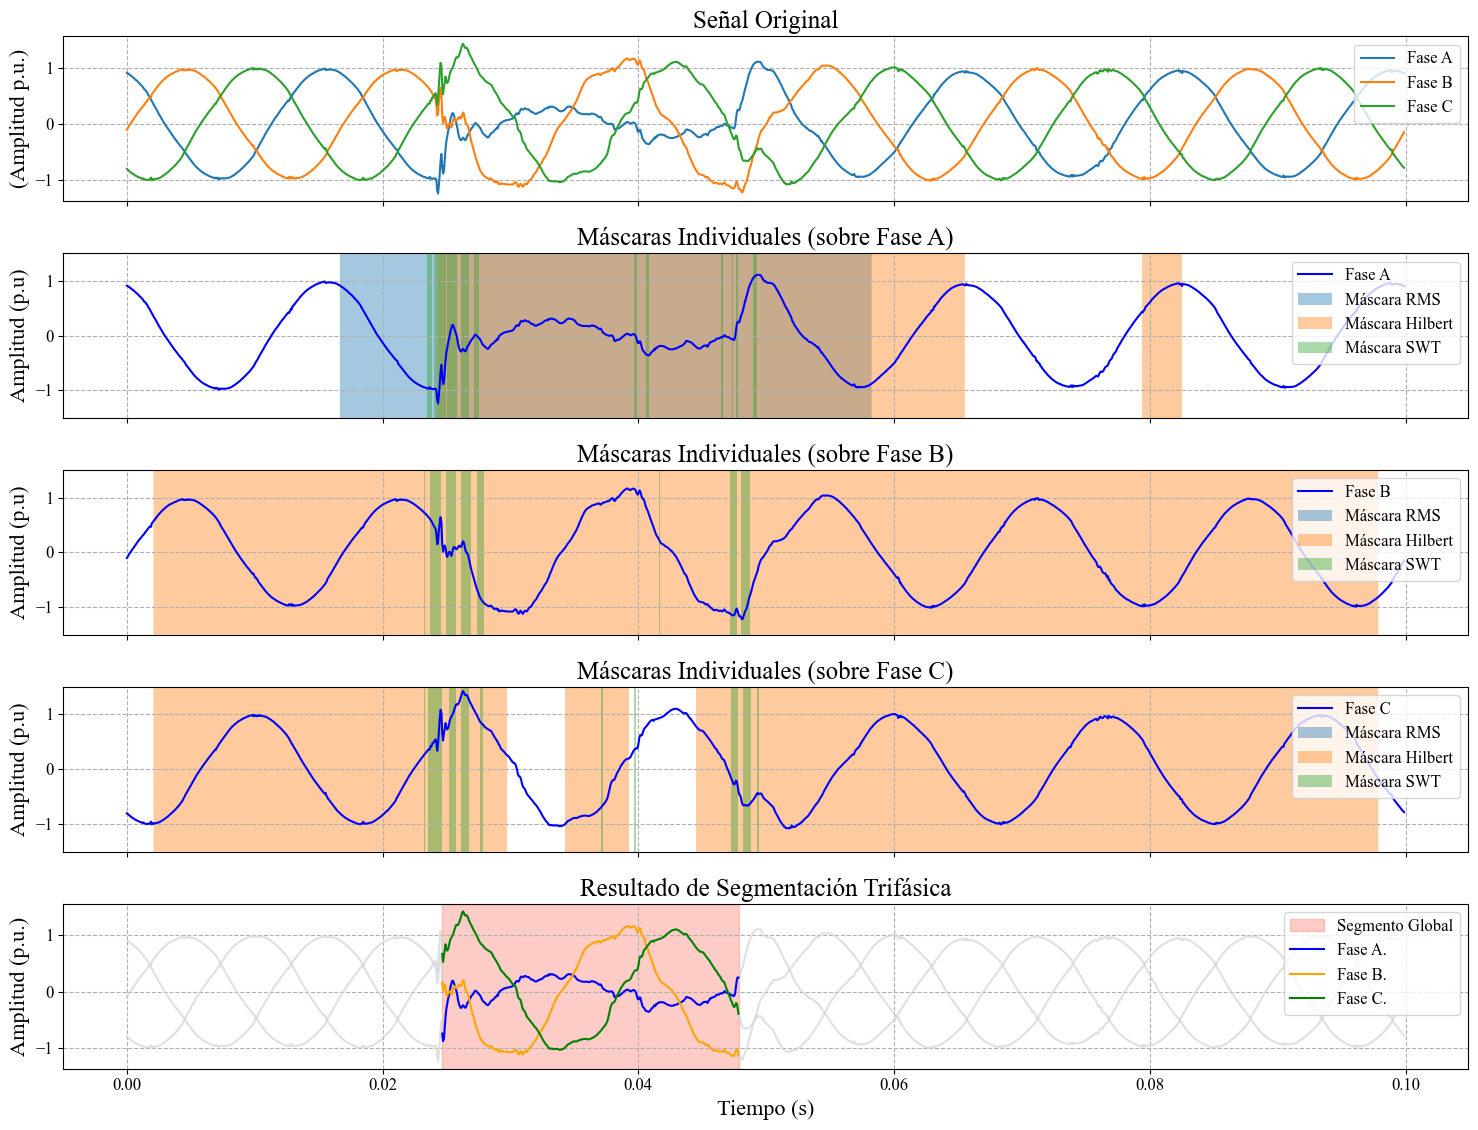

In [7]:
def clasificar_senal_trifasica(ruta_csv: str, id_falla: str, ruta_activos: str):
    """
    Carga la señal, detecta el evento, extrae características trifásicas y clasifica.
    """
    
    # --- 1. Carga de Activos y Datos ---
    print("--- 1. Cargando modelo, encoder y orden de columnas (Trifásico)... ---")
    try:
        modelo_cargado = joblib.load(os.path.join(ruta_activos, 'modelo_trifasico.joblib'))
        label_encoder_cargado = joblib.load(os.path.join(ruta_activos, 'label_encoder_trifasico.joblib'))
        model_columns = joblib.load(os.path.join(ruta_activos, 'model_columns_trifasico.joblib'))
        print("¡Archivos trifásicos cargados exitosamente!")
    except FileNotFoundError as e:
        print(f"Error: Asegúrate de que los archivos trifásicos (.joblib) estén en {ruta_activos}. {e}")
        return

    print(f"\n--- 2. Cargando y preparando la señal '{id_falla}' de {ruta_csv} ---")
    try:
        data = pd.read_csv(ruta_csv)
        senal_df = data[data['ID_Falla'] == id_falla].copy()
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo CSV en {ruta_csv}.")
        return

    if senal_df.empty:
        print(f"Advertencia: No se encontró la falla con ID '{id_falla}'.")
        return

    # Extracción de fases y tiempo
    x = senal_df['Time'] 
    y1, y2, y3 = senal_df['Va'].values, senal_df['Vb'].values, senal_df['Vc'].values

    # Cálculo de fs y RMS nominal global
    tiempo = x.iloc[-1]
    fs = len(x)/tiempo
    print(f"Frecuencia de muestreo: {fs:.2f} Hz")
    
    # Calclular RMS nominal sobre una fase (asumiendo estado estable al inicio)
    rms_nom = 0.7
    print(f"RMS Nominal de referencia: {rms_nom:.4f} p.u.")
    
    # --- 3. Detección del Evento (Usando Fase A como referencia) ---
    intervalo= encontrar_intervalo_global(y1,y2,y3, fs, umbral_sag=0.9)
    print(intervalo)

    if not intervalo:
        print("No se detectaron eventos para clasificar.")
        return

    # Usamos el primer evento detectado en A para segmentar las tres fases
    t_ini, t_final = intervalo
    print(f"Evento detectado (tiempo): {t_ini/fs} a {t_final/fs}")
    
    segmento_A = y1[t_ini:t_final]
    segmento_B = y2[t_ini:t_final]
    segmento_C = y3[t_ini:t_final]

    if len(segmento_A) == 0:
        print("El segmento de evento es nulo.")
        return

    # --- 4. Extracción de Características ---
    caracteristicas = extraer_caracteristicas_trifasicas(segmento_A, segmento_B, segmento_C, fs, rms_nom)
    print('Caracteristicas:',caracteristicas)

    # --- 5. Preparación y Predicción ---
    df_para_predecir = pd.DataFrame([caracteristicas])
    
    # Asegurar el orden de las columnas (¡CRÍTICO!)
    df_para_predecir = df_para_predecir[model_columns]

    probabilidades = modelo_cargado.predict_proba(df_para_predecir)
    prediccion_numerica = modelo_cargado.predict(df_para_predecir)
    prediccion_texto = label_encoder_cargado.inverse_transform(prediccion_numerica)

    # --- 6. Presentación de Resultados ---
    clases = label_encoder_cargado.classes_
    print(f"\n El evento trifásico ha sido clasificado como: '{prediccion_texto[0]}'")
    
    print("\nConfianza del modelo:")
    confianza_ordenada = sorted(zip(clases, probabilidades[0]), key=lambda item: item[1], reverse=True)
    
    for clase, confianza in confianza_ordenada:
        barra = '█' * int(confianza * 30)
        print(f" - {clase:<20} | {confianza:7.2%} | {barra}")
    visualizar_segmentacion_completa(y1, y2, y3, fs = fs ,umbral_sag=0.9, umbral_swell=1.1, signal_id=1)

if __name__ == "__main__":
    # --- CONFIGURACIÓN DE RUTAS ---
    # RUTA de la carpeta que contiene modelo_trifasico.joblib, etc.
    RUTA_CARPETA_ACTIVOS = r'Modelos\Tri' 
    
    # Señal de ejemplo (ajusta la ruta y la ID)
    RUTA_CSV_ENTRADA = r'Señales_IEEE\Señales_IEEE.csv'
    ID_FALLA_ANALIZAR = 'Sag_5'
    
    clasificar_senal_trifasica(RUTA_CSV_ENTRADA, ID_FALLA_ANALIZAR, RUTA_CARPETA_ACTIVOS)

## Implementación de Análisis Monofasico

In [8]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from typing import Dict, Any, Optional, List, Tuple
import os
import re
# try: # Opcional: Pyarrow
#     import pyarrow
# except ImportError:
#     print("Advertencia: 'pyarrow' no instalada.")
def analizar_una_sola_senal(senal_fase: np.ndarray, fs: float, activos_modelo: Dict[str, Any]) -> List[Dict[str, Any]]:
    """Analiza un array monofásico, detecta eventos y los clasifica."""
    # ... (Se mantiene igual, llamando a tus funciones globales monofásicas) ...
    resultados_eventos = []
    try: intervalos_detectados = detectar_eventos_con_fusion(senal_fase, fs=fs, umbral_sag=0.9) # MONO
    except NameError: print("Error Fatal: 'detectar_eventos_con_fusion' no definida."); return []
    except Exception as e: print(f"Error detección: {e}"); return []
    if not intervalos_detectados: return []
    modelo=activos_modelo.get('modelo'); encoder=activos_modelo.get('encoder'); columnas_modelo=activos_modelo.get('columnas')
    if not all([modelo, encoder, columnas_modelo is not None]): print("Error: Faltan activos."); return []
    for i, (t_ini, t_fin) in enumerate(intervalos_detectados):
        if not (isinstance(t_ini, int) and isinstance(t_fin, int) and 0<= t_ini < t_fin <= len(senal_fase)): print(f"Adv: Intervalo inválido ({t_ini},{t_fin}). Saltando."); continue
        segmento = senal_fase[t_ini:t_fin];
        if len(segmento)==0: continue
        try: rms_nom=rms_nominal(senal_fase, fs); caracteristicas=extraer_caracteristicas(segmento, fs, rms_nom) # MONO
        except NameError: print("Error Fatal: Funciones lógica mono no definidas."); return resultados_eventos
        except Exception as e: print(f"Error extracción ev {i+1}: {e}"); continue
        try: df_pred = pd.DataFrame([caracteristicas]); df_pred = df_pred[columnas_modelo]
        except KeyError as e: print(f"Error: Característica faltante/incorrecta mono. Espera:{list(columnas_modelo)}, Recibido:{list(caracteristicas.keys())}. E:{e}. Saltando ev {i+1}."); continue
        except Exception as e: print(f"Error preparando DF mono: {e}"); continue
        try: pred_num=modelo.predict(df_pred); pred_texto=encoder.inverse_transform(pred_num)[0]; probabilidades=modelo.predict_proba(df_pred)[0]
        except Exception as e: print(f"Error predicción mono ev {i+1}: {e}"); continue
        resultado_evento = {"evento_nro":i+1, "intervalo_muestras":(t_ini, t_fin), "clase":pred_texto, "confianza":dict(zip(encoder.classes_, probabilidades))}
        resultados_eventos.append(resultado_evento)
    return resultados_eventos
# -----------------------------------------------------------------------------
# 0. VERIFICACIÓN DE FUNCIONES DE LÓGICA (Definidas Previamente - MONOFÁSICO)
# -----------------------------------------------------------------------------
print("Verificando existencia de funciones de lógica MONOFÁSICAS...")
required_funcs = [
    'detectar_eventos_con_fusion', # Requerida para análisis monofásico
    'extraer_caracteristicas',    # Requerida para análisis monofásico
    'rms_nominal'                 # Usada por análisis monofásico
]
missing_funcs = [func for func in required_funcs if func not in globals()]
if missing_funcs:
     print(f"ERROR FATAL: Faltan funciones monofásicas: {', '.join(missing_funcs)}")
     # raise NameError(f"Funciones no definidas: {', '.join(missing_funcs)}")
else:
     print("Funciones de lógica monofásicas encontradas.")

# -----------------------------------------------------------------------------
# 1. FUNCIÓN DE CARGA DE ACTIVOS (Ajustada para nombres específicos)
# -----------------------------------------------------------------------------
def cargar_activos_modelo(ruta_carpeta: str, es_trifasico: bool = False) -> Dict[str, Any]:
    """Carga modelo, encoder y columnas, adaptando nombres."""
    print(f"--- Cargando activos {'TRIFÁSICOS' if es_trifasico else 'MONOFÁSICOS'} desde: {ruta_carpeta} ---")
    modelo_base = 'modelo_trifasico.joblib' if es_trifasico else 'modelo_xgboost.joblib'
    encoder_base = 'label_encoder_trifasico.joblib' if es_trifasico else 'label_encoder.joblib'
    columnas_base = 'model_columns_trifasico.joblib' if es_trifasico else 'model_columns.joblib'
    archivos_esperados = {"modelo": [modelo_base, 'modelo.joblib'], "encoder": [encoder_base], "columnas": [columnas_base]}
    activos = {}
    try:
        for activo_nombre, posibles_nombres in archivos_esperados.items():
            encontrado = False
            nombres_ordenados = sorted(posibles_nombres, key=lambda x: x != archivos_esperados[activo_nombre][0])
            for nombre_archivo in nombres_ordenados:
                ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
                if os.path.exists(ruta_completa):
                    activos[activo_nombre] = joblib.load(ruta_completa)
                    print(f"   - {activo_nombre} cargado desde {nombre_archivo}")
                    encontrado = True; break
            if not encontrado: raise FileNotFoundError(f"No se encontró '{activo_nombre}' en {ruta_carpeta} (buscado: {posibles_nombres})")
        print("¡Activos cargados exitosamente!")
        if 'encoder' in activos and 'columnas' in activos:
             print(f"   - Clases encoder: {list(activos['encoder'].classes_)}")
             print(f"   - Num columnas modelo: {len(activos['columnas'])}")
        return activos
    except FileNotFoundError as e: print(f"Error: {e}"); return {}
    except Exception as e: print(f"Error inesperado cargando activos: {e}"); return {}

# -----------------------------------------------------------------------------
# 2. FUNCIÓN DE CARGA DE SEÑAL TRIFÁSICA CSV (Adaptada de tu original)
# -----------------------------------------------------------------------------
def cargar_senal_trifasica_csv(ruta_csv: str, id_falla: str, col_id: str = 'ID_Falla') -> Optional[pd.DataFrame]:
    """Carga un DataFrame CSV y filtra una señal trifásica específica por su ID."""
    print(f"\n--- Cargando señal trifásica CSV '{id_falla}' de {ruta_csv} ---")
    try:
        data = pd.read_csv(ruta_csv)
        if col_id not in data.columns:
            print(f"Error: Falta la columna ID '{col_id}' en {ruta_csv}")
            return None
        senal_df = data[data[col_id] == id_falla].copy()
        if senal_df.empty:
            print(f"Advertencia: No se encontró la falla con ID '{id_falla}' en {ruta_csv}.")
            return None
        # Validar columnas de fase y tiempo (puedes hacerlas argumentos si cambian)
        if not all(col in senal_df.columns for col in ['Time', 'Va', 'Vb', 'Vc']):
            print(f"Error: CSV '{id_falla}' no contiene 'Time', 'Va', 'Vb', 'Vc'.")
            return None
        print(f"Señal CSV '{id_falla}' cargada ({len(senal_df)} muestras).")
        return senal_df
    except FileNotFoundError: print(f"Error: No se encontró archivo CSV en {ruta_csv}."); return None
    except Exception as e: print(f"Error inesperado cargando CSV trifásico: {e}"); return None


# -----------------------------------------------------------------------------
# 3. FUNCIÓN DE ANÁLISIS POR FASE (Adaptada para devolver resultados completos)
# -----------------------------------------------------------------------------
def analizar_trifasico_por_fase(senal_df: pd.DataFrame, # Recibe DF ya filtrado
                                activos_modelo: Dict[str, Any], # Activos MONOFÁSICOS
                                col_tiempo: str = 'Time',
                                cols_fase: List[str] = ['Va', 'Vb', 'Vc']
                                ) -> Dict[str, Any]:
    """
    Analiza cada fase INDEPENDIENTEMENTE usando lógica MONOFÁSICA,
    y devuelve diccionario completo para visualización.
    """
    print("\n--- Iniciando Análisis Trifásico por Fase (con modelo monofásico) ---")
    resultados_completos = {"fs": 0, "tipo": "trifasico_por_fase", "datos_ejes": {}, "resultados_ejes": {}}
    try:
        # Validar columnas
        columnas_requeridas = [col_tiempo] + cols_fase
        if not all(col in senal_df.columns for col in columnas_requeridas):
            print(f"Error: Faltan columnas {columnas_requeridas}. Encontradas: {list(senal_df.columns)}"); return resultados_completos
        x = senal_df[col_tiempo]
        fases_data = {fase_nombre: senal_df[fase_nombre].values for fase_nombre in cols_fase}
        resultados_completos["datos_ejes"] = fases_data # Guardar datos

        # Calcular Fs (asumiendo 'Time' es segundos)
        fs = 0
        if len(x) > 1 and x.iloc[-1] > x.iloc[0]: fs = (len(x) - 1) / (x.iloc[-1] - x.iloc[0]); print(f"Fs calculada de '{col_tiempo}': {fs:.2f} Hz")
        elif len(x) > 1: fs = 1.0 / np.mean(np.diff(x)); print(f"Adv: Tiempo no monótono? Fs estimada: {fs:.2f} Hz")
        else: print("Error: No se pudo calcular Fs.")
        if fs <= 0: print("Error Fatal: Fs no válida."); return resultados_completos
        resultados_completos["fs"] = fs

        # Iterar sobre cada fase para análisis MONOFÁSICO
        for nombre_fase, senal_fase in fases_data.items():
            print(f"Analizando Fase {nombre_fase} (como monofásica)...")
            # Llama a la función central monofásica
            # ¡Importante! Pasa los activos MONOFÁSICOS
            resultados_eventos = analizar_una_sola_senal(senal_fase, fs, activos_modelo)

            if not resultados_eventos:
                 print(f"No se detectaron eventos en Fase {nombre_fase}.")
                 # Añadir entrada vacía para que el gráfico sepa que existe el eje
                 resultados_completos["resultados_ejes"][nombre_fase] = []
            else:
                 print(f"Se detectaron y clasificaron {len(resultados_eventos)} eventos en Fase {nombre_fase}.")
                 resultados_completos["resultados_ejes"][nombre_fase] = resultados_eventos

    except KeyError as e: print(f"Error: Falta columna '{e}'.");
    except Exception as e: print(f"Error inesperado análisis por fase: {e}");

    return resultados_completos

# -----------------------------------------------------------------------------
# 4. FUNCIÓN DE PRESENTACIÓN DE RESULTADOS (GENERALIZADA Y CORREGIDA)
# -----------------------------------------------------------------------------
def presentar_resultados(resultados: Dict[str, Any], id_presentacion: str):
    """Muestra los resultados del análisis de forma estructurada."""
    print(f"\n===============================================")
    print(f"     RESULTADOS PARA: {id_presentacion} ")
    print("===============================================")
    if not resultados or "fs" not in resultados or not resultados.get("resultados_ejes"): print("Resultados no válidos."); return
    fs = resultados['fs']; print(f"Frecuencia de Muestreo: {fs:.2f} Hz")
    tipo_analisis = resultados.get("tipo", "desconocido") # Será 'trifasico_por_fase'

    # Iterar sobre cada eje (A, B, C en este caso)
    for nombre_eje, eventos in resultados['resultados_ejes'].items():
        print(f"\n--- Análisis de Eje/Fase: {nombre_eje} ---")
        if not eventos: print("No se encontraron eventos."); continue

        # Mostrar TODOS los eventos detectados en esta fase
        for evento in eventos:
            t_ini, t_fin = evento.get('intervalo_muestras', (None, None))
            clase = evento.get('clase', '?'); confianza_dict = evento.get('confianza', {})
            if t_ini is not None and t_fin is not None:
                 t_ini_s = t_ini / fs if fs > 0 else 0; t_fin_s = t_fin / fs if fs > 0 else 0
                 print(f"  Evento #{evento.get('evento_nro', '?')} [{t_ini}:{t_fin}] -> {t_ini_s:.4f}s a {t_fin_s:.4f}s")
            else: print(f"  Evento #{evento.get('evento_nro', '?')}") # Caso 'Normal' sin intervalo
            print(f"  Clasificación: '{clase}'")
            if confianza_dict:
                 print("  Confianza:"); conf_ord = sorted(confianza_dict.items(), key=lambda i: i[1], reverse=True)
                 for nc, conf in conf_ord:
                     # --- CORRECCIÓN UNBOUND LOCAL ERROR ---
                     if conf < 0.001: continue
                     barra = '█' * int(conf * 25) # Calcular barra DESPUÉS
                     print(f"    - {nc:<18} | {conf:7.2%} | {barra}")
                     # --- FIN CORRECCIÓN ---
            else: print("  (Confianza no disponible)")


# -----------------------------------------------------------------------------
# 5. FUNCIÓN DE VISUALIZACIÓN (GENERALIZADA - Paneles por eje/fase)
# -----------------------------------------------------------------------------
def _setup_academic_style():
    """Configura Matplotlib."""
    # ... (Sin cambios) ...
    try: plt.style.use('seaborn-v0_8-paper')
    except OSError: print("Estilo 'seaborn-v0_8-paper' no encontrado.")
    plt.rcParams.update({'font.family':'serif','font.serif':['Times New Roman'],'mathtext.fontset':'stix','font.size':20,'axes.labelsize':16,'axes.titlesize':20,'xtick.labelsize':20,'ytick.labelsize':20,'legend.fontsize':20,'figure.figsize':(18, 7),'lines.linewidth':1.2,'grid.color':'#DDDDDD','grid.linestyle':'--','grid.linewidth':0.5,'axes.spines.top':False,'axes.spines.right':False,'svg.fonttype':'none'})

def visualizar_analisis(resultados: dict,
                        id_presentacion: str,
                        directorio_salida: str = "graficos_svg"):
    """Crea gráfico (N paneles por fase), visualiza eventos Y GUARDA SVG."""
    if not resultados or not resultados.get("datos_ejes"): print("No hay datos que visualizar."); return
    _setup_academic_style()
    fs = resultados.get('fs', 0); datos_ejes = resultados['datos_ejes']; resultados_ejes = resultados.get('resultados_ejes', {}); tipo = resultados.get('tipo', 'desconocido')
    t = None; num_muestras = 0
    if datos_ejes: num_muestras = len(next(iter(datos_ejes.values()), []))
    if num_muestras > 0:
        if fs > 0: t = np.arange(num_muestras) / fs
        else: t = np.arange(num_muestras); print("Advertencia: Usando índices en eje X.")
    else: print("Error: No se puede determinar eje de tiempo."); return
    if t is None or len(t) == 0: print("Error: Eje de tiempo vacío."); return

    # --- DICCIONARIO DE COLORES PARA CLASES MONOFÁSICAS ---
    # ¡Verifica que coincidan con tu label_encoder.joblib!
    colores_clases = {
        'Normal':           '#1D3557', 'Sag':              '#E63946',
        'Sag_Armonico':     '#F4A261', 'Sag_Multiple':     '#E76F51',
        'Sag_Notch':        '#2A9D8F', 'Sag_Transitorios': '#457B9D',
        'default':          '#BDBDBD'
    }

    num_ejes_datos = len(datos_ejes)
    if num_ejes_datos == 0: print("No hay ejes para graficar."); return

    # --- N PANELES (uno por fase) ---
    num_paneles_plot = num_ejes_datos # =3 en este caso
    fig_height = max(8, 3 * num_paneles_plot)
    fig, axes = plt.subplots(num_paneles_plot, 1, figsize=(20, fig_height), sharex=True, squeeze=False);
    axes = axes.flatten(); legend_handles = {}

    # Iterar para graficar cada fase en su panel
    for i, (nombre_eje, senal_eje) in enumerate(datos_ejes.items()):
        ax = axes[i]
        if len(senal_eje) != len(t): print(f"Adv: Discrepancia longitud '{nombre_eje}'."); continue

        line, = ax.plot(t, senal_eje, color="#0D00FF", linewidth=1.0, label=f'Onda ({nombre_eje})')
        if f'Onda ({nombre_eje})' not in legend_handles: legend_handles[f'Onda ({nombre_eje})'] = line

        eventos_a_graficar = resultados_ejes.get(nombre_eje, []) # Eventos de ESTA fase
        if not eventos_a_graficar: ax.text(0.5, 0.5, 'Sin eventos detectados', ha='center', va='center', transform=ax.transAxes, fontsize=20, color='grey', style='italic')

        # Procesar CADA evento detectado en ESTA fase
        for evento_idx, evento in enumerate(eventos_a_graficar):
            t_ini, t_fin = evento.get('intervalo_muestras', (None, None)); clase = evento.get('clase', '?'); confianza_dict = evento.get('confianza', {})
            if clase == "Normal" and t_ini is None: continue
            if t_ini is None or t_fin is None or t_ini >= len(t) or t_fin > len(t) or t_ini >= t_fin: print(f"Adv: Intervalo inválido ({t_ini}, {t_fin}) ev {evento_idx+1} eje {nombre_eje}. Saltando."); continue

            confianza = max(confianza_dict.values()) if confianza_dict else 0.0
            color = colores_clases.get(clase, colores_clases['default']);
            if clase not in colores_clases: print(f"Adv: Clase '{clase}' sin color definido.")
            span = ax.axvspan(t[t_ini], t[t_fin], color=color, alpha=0.35, zorder=0)
            leyenda_clase = f'Evento: {clase}';
            if leyenda_clase not in legend_handles: legend_handles[leyenda_clase] = mpatches.Patch(color=color, alpha=0.35, label=leyenda_clase)
            y_min_lim, y_max_lim = ax.get_ylim(); y_range = y_max_lim - y_min_lim; y_pos_text = y_max_lim - y_range * (0.05 + (evento_idx % 5) * 0.12)
            ax.text(t[t_ini]+(t[t_fin]-t[t_ini])/2, y_pos_text, f"{clase}\n({confianza:.0%})", ha='center', va='top', fontsize=20, fontweight='bold', color=color, bbox=dict(facecolor='white', alpha=0.6, pad=0.1, boxstyle='round,pad=0.1'))

        ax.set_ylabel(f'{nombre_eje}\n(p.u.)'); ax.grid(True); ax.tick_params(axis='x', rotation=0)

    # Leyenda unificada arriba
    if legend_handles and axes.size > 0:
        axes[0].legend(handles=legend_handles.values(), labels=legend_handles.keys(),
                       loc='lower center', bbox_to_anchor=(0.5, 1.05), # Arriba
                       ncol=min(len(legend_handles), 6), fancybox=True, shadow=False, fontsize=20)

    if axes.size > 0: axes[-1].set_xlabel('Tiempo (s)');
    if len(t)>0: axes[-1].set_xlim(t[0], t[-1]);
    # Ajustar Y lims para todos los ejes (opcional)
    # y_min_all, y_max_all = -1.6, 1.6 # Ejemplo
    # for ax in axes: ax.set_ylim(y_min_all, y_max_all)
    for ax in axes: ax.set_ylim(-1.3, 1.3) # Límites fijos más simples

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]); # Ajustar rect para título/leyenda
    plt.subplots_adjust(hspace=0.15) # Espacio vertical entre paneles

    # Guardado SVG
    try:
        os.makedirs(directorio_salida, exist_ok=True); nombre_base_limpio = re.sub(r'[\\/*?:"<>|() ]', "_", id_presentacion); nombre_archivo = f"{nombre_base_limpio}.svg"; ruta_completa_svg = os.path.join(directorio_salida, nombre_archivo);
        plt.savefig(ruta_completa_svg, format='svg', bbox_inches='tight'); print(f"Gráfico guardado como: {ruta_completa_svg}")
    except Exception as e: print(f"Error al guardar SVG: {e}")
    plt.close(fig)

# -----------------------------------------------------------------------------
# 5. BLOQUE PRINCIPAL (Adaptado para ANÁLISIS POR FASE con modelo MONO)
# -----------------------------------------------------------------------------
if __name__ == "__main__":

    # --- ¡VERIFICAR FUNCIONES GLOBALES MONOFÁSICAS! ---
    print("Verificando funciones de lógica MONOFÁSICAS...")
    # (Código de verificación sin cambios)
    required_funcs_mono = ['detectar_eventos_con_fusion', 'extraer_caracteristicas', 'rms_nominal']
    missing_funcs_mono = [func for func in required_funcs_mono if func not in globals()]
    if missing_funcs_mono: print(f"ERROR FATAL: Faltan funciones monofásicas: {', '.join(missing_funcs_mono)}")
    else: print("Funciones de lógica monofásicas encontradas.")

    # --- CONFIGURACIÓN DE RUTAS Y PARÁMETROS ---
    RUTA_CARPETA_ACTIVOS_MONO = r'Modelos\Mono' # ¡RUTA MODELO MONOFÁSICO!
    DIRECTORIO_SALIDA_SVG_PORFASE = "Resultados_Graficos_SVG_PorFase_Mono" # Carpeta para SVGs

    # --- TAREAS A ANALIZAR (Archivos CSV Trifásicos y IDs) ---
    tareas_analisis = [
        #{"ruta_csv": r'EPRI\Señales_EPRI_Normalizadas.csv', "id_falla": 'Sag_1'},
        #{"ruta_csv": r'CHEC\Señales_CHEC_Normalizadas.csv', "id_falla": 'Sag_5'},
        {"ruta_csv": r'Señales_IEEE\Señales_IEEE.csv', "id_falla":'Sag_5'},
        #{"ruta_csv": r'ENEA\Multi_Estado\Señales_ENEA_Normalizadas.csv', "id_falla":'Sag_5'},
        
    ]

    # --- AJUSTES OPCIONALES ---
    COLUMNA_ID_CSV = 'ID_Falla'; COLUMNA_TIEMPO_CSV = 'Time'; COLUMNAS_FASE_CSV = ['Va', 'Vb', 'Vc']

    # --- EJECUTAR EL PROCESO PRINCIPAL ---
    if not missing_funcs_mono: # Solo si las funciones existen
        print(f"\n--- Iniciando Procesamiento por Fase (Modelo Monofásico) ---")
        # Cargar activos monofásicos UNA SOLA VEZ
        print(f"--- Cargando activos MONOFÁSICOS desde: {RUTA_CARPETA_ACTIVOS_MONO} ---")
        activos_mono = cargar_activos_modelo(RUTA_CARPETA_ACTIVOS_MONO, es_trifasico=False)

        if not activos_mono: print("Error: No se cargaron activos monofásicos. Terminando."); exit()

        # --- Bucle de Procesamiento por Tarea ---
        for i, tarea in enumerate(tareas_analisis):
            ruta_csv_actual = tarea.get('ruta_csv')
            id_falla_actual = tarea.get('id_falla')

            if not ruta_csv_actual or not id_falla_actual:
                 print(f"Error: Tarea {i+1} inválida (falta ruta o id). Saltando."); continue

            print(f"\n---====================================---")
            print(f"--- PROCESANDO Señal '{id_falla_actual}' de {os.path.basename(ruta_csv_actual)} ({i+1}/{len(tareas_analisis)}) ---")
            print(f"---====================================---")

            # 1. Cargar la señal trifásica específica del CSV
            df_senal = cargar_senal_trifasica_csv(ruta_csv_actual, id_falla_actual, col_id=COLUMNA_ID_CSV)

            if df_senal is None: continue # Saltar si no se pudo cargar

            # 2. Llamar a la función de análisis por fase (pasando activos MONO)
            resultados_completos = analizar_trifasico_por_fase(
                senal_df=df_senal,
                activos_modelo=activos_mono, # ¡Modelo Monofásico!
                col_tiempo=COLUMNA_TIEMPO_CSV,
                cols_fase=COLUMNAS_FASE_CSV
            )

            # 3. Presentar y Visualizar si hay resultados
            if resultados_completos and resultados_completos.get("datos_ejes"):
                etiqueta_presentacion = f"{os.path.basename(ruta_csv_actual).replace('.csv','')}_{id_falla_actual}_PorFase"

                presentar_resultados(resultados_completos, etiqueta_presentacion) # Mostrar en consola
                try:
                    print("\nGenerando y guardando visualización SVG...")
                    visualizar_analisis(resultados_completos, etiqueta_presentacion, DIRECTORIO_SALIDA_SVG_PORFASE)
                except Exception as e:
                    print(f"\nError Crítico al generar/guardar visualización para '{etiqueta_presentacion}': {e}")
                    # import traceback; traceback.print_exc() # Para debug
            else:
                 print(f"No se generaron resultados válidos para '{id_falla_actual}'.")

        print(f"\n--- Procesamiento por Fase completado. Revisa la carpeta: '{DIRECTORIO_SALIDA_SVG_PORFASE}' ---")
    else:
         print("\nEl script no puede continuar porque faltan funciones de lógica monofásica.")

Verificando existencia de funciones de lógica MONOFÁSICAS...
Funciones de lógica monofásicas encontradas.
Verificando funciones de lógica MONOFÁSICAS...
Funciones de lógica monofásicas encontradas.

--- Iniciando Procesamiento por Fase (Modelo Monofásico) ---
--- Cargando activos MONOFÁSICOS desde: Modelos\Mono ---
--- Cargando activos MONOFÁSICOS desde: Modelos\Mono ---
   - modelo cargado desde modelo_xgboost.joblib
   - encoder cargado desde label_encoder.joblib
   - columnas cargado desde model_columns.joblib
¡Activos cargados exitosamente!
   - Clases encoder: ['Normal', 'Sag', 'Sag_Armonico', 'Sag_Multiple', 'Sag_Notch', 'Sag_Transitorios']
   - Num columnas modelo: 19

---====================================---
--- PROCESANDO Señal 'Sag_5' de Señales_IEEE.csv (1/1) ---
---====================================---

--- Cargando señal trifásica CSV 'Sag_5' de Señales_IEEE\Señales_IEEE.csv ---
Señal CSV 'Sag_5' cargada (1536 muestras).

--- Iniciando Análisis Trifásico por Fase (con 

## Grafica para documento Monofasico

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from typing import Dict, Any, Optional, List, Tuple
import os
import re
# try: # Opcional: Pyarrow solo si lees parquet en otras partes
#     import pyarrow
# except ImportError:
#     print("Advertencia: 'pyarrow' no instalada.")

# -----------------------------------------------------------------------------
# 0. VERIFICACIÓN DE FUNCIONES DE LÓGICA (Definidas Previamente - MONOFÁSICO)
# -----------------------------------------------------------------------------
print("Verificando existencia de funciones de lógica MONOFÁSICAS...")
# --- AJUSTADO PARA MONOFÁSICO ---
required_funcs = [
    'detectar_eventos_con_fusion', # Requerida para análisis monofásico
    'extraer_caracteristicas',    # Requerida para análisis monofásico
    'rms_nominal'                 # Usada por análisis monofásico
]
missing_funcs = [func for func in required_funcs if func not in globals()]
if missing_funcs:
     print(f"ERROR FATAL: Faltan funciones monofásicas: {', '.join(missing_funcs)}")
     # raise NameError(f"Funciones no definidas: {', '.join(missing_funcs)}") # Descomenta para detener
else:
     print("Funciones de lógica monofásicas encontradas.")

# -----------------------------------------------------------------------------
# 1. FUNCIÓN DE CARGA DE ACTIVOS (Ajustada para nombres específicos)
# -----------------------------------------------------------------------------
def cargar_activos_modelo(ruta_carpeta: str, es_trifasico: bool = False) -> Dict[str, Any]:
    """Carga modelo, encoder y columnas, adaptando nombres si es trifásico."""
    print(f"--- Cargando activos {'TRIFÁSICOS' if es_trifasico else 'MONOFÁSICOS'} desde: {ruta_carpeta} ---")
    modelo_base = 'modelo_trifasico.joblib' if es_trifasico else 'modelo_xgboost.joblib' # ¡Nombre modelo MONO!
    encoder_base = 'label_encoder_trifasico.joblib' if es_trifasico else 'label_encoder.joblib' # ¡Nombre encoder MONO!
    columnas_base = 'model_columns_trifasico.joblib' if es_trifasico else 'model_columns.joblib' # ¡Nombre columnas MONO!
    archivos_esperados = {"modelo": [modelo_base, 'modelo.joblib'], "encoder": [encoder_base], "columnas": [columnas_base]}
    activos = {}
    try:
        for activo_nombre, posibles_nombres in archivos_esperados.items():
            encontrado = False
            nombres_ordenados = sorted(posibles_nombres, key=lambda x: x != archivos_esperados[activo_nombre][0])
            for nombre_archivo in nombres_ordenados:
                ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
                if os.path.exists(ruta_completa):
                    activos[activo_nombre] = joblib.load(ruta_completa)
                    print(f"   - {activo_nombre} cargado desde {nombre_archivo}")
                    encontrado = True; break
            if not encontrado: raise FileNotFoundError(f"No se encontró '{activo_nombre}' en {ruta_carpeta} (buscado: {posibles_nombres})")
        print("¡Activos cargados exitosamente!")
        if 'encoder' in activos and 'columnas' in activos:
             print(f"   - Clases encoder: {list(activos['encoder'].classes_)}")
             print(f"   - Num columnas modelo: {len(activos['columnas'])}")
        return activos
    except FileNotFoundError as e: print(f"Error: {e}"); return {}
    except Exception as e: print(f"Error inesperado cargando activos: {e}"); return {}

# -----------------------------------------------------------------------------
# 2.A FUNCIÓN DE LÓGICA CENTRAL MONOFÁSICA (Sin cambios, llama a globales)
# -----------------------------------------------------------------------------


# --- Funciones de análisis/carga trifásica y parquet OMITIDAS ---

# -----------------------------------------------------------------------------
# 3. FUNCIÓN DE PRESENTACIÓN DE RESULTADOS (GENERALIZADA - Sin cambios)
# -----------------------------------------------------------------------------
def presentar_resultados(resultados: Dict[str, Any], id_presentacion: str):
    """Muestra los resultados del análisis de forma estructurada."""
    # ... (Sin cambios) ...
    print(f"\n===============================================")
    print(f"     RESULTADOS PARA: {id_presentacion} ")
    print("===============================================")
    if not resultados or "fs" not in resultados or not resultados.get("resultados_ejes"): print("Resultados no válidos."); return
    fs = resultados['fs']; print(f"Frecuencia de Muestreo: {fs:.2f} Hz")
    tipo_analisis = resultados.get("tipo", "desconocido") # Será 'monofasico'

    for nombre_eje, eventos in resultados['resultados_ejes'].items(): # Iterará solo una vez
        print(f"\n--- Análisis de Señal: {nombre_eje} ---")
        if not eventos: print("No se encontraron eventos."); continue
        for evento in eventos:
            t_ini, t_fin = evento.get('intervalo_muestras', (None, None))
            clase = evento.get('clase', '?'); confianza_dict = evento.get('confianza', {})
            if t_ini is not None and t_fin is not None:
                 t_ini_s = t_ini / fs if fs > 0 else 0; t_fin_s = t_fin / fs if fs > 0 else 0
                 print(f"  Evento #{evento.get('evento_nro', '?')} [{t_ini}:{t_fin}] -> {t_ini_s:.4f}s a {t_fin_s:.4f}s")
            else: print(f"  Evento #{evento.get('evento_nro', '?')}") # Caso 'Normal'
            print(f"  Clasificación: '{clase}'")
            if confianza_dict:
                 print("  Confianza:"); conf_ord = sorted(confianza_dict.items(), key=lambda i: i[1], reverse=True)
                 for nc, conf in conf_ord:
                     if conf < 0.001: continue
                     barra = '█' * int(conf * 25)
                     print(f"    - {nc:<18} | {conf:7.2%} | {barra}")
            else: print("  (Confianza no disponible)")


# -----------------------------------------------------------------------------
# 4. FUNCIÓN DE VISUALIZACIÓN (Ajustada para colores monofásicos y 1 panel)
# -----------------------------------------------------------------------------
def _setup_academic_style():
    """Configura Matplotlib."""
    # ... (Sin cambios) ...
    try: plt.style.use('seaborn-v0_8-paper')
    except OSError: print("Estilo 'seaborn-v0_8-paper' no encontrado.")
    plt.rcParams.update({'font.family':'serif','font.serif':['Times New Roman'],'mathtext.fontset':'stix','font.size':14,'axes.labelsize':16,'axes.titlesize':18,'xtick.labelsize':12,'ytick.labelsize':14,'legend.fontsize':10,'figure.figsize':(18, 7),'lines.linewidth':1.2,'grid.color':'#DDDDDD','grid.linestyle':'--','grid.linewidth':0.5,'axes.spines.top':False,'axes.spines.right':False,'svg.fonttype':'none'})

def visualizar_analisis(resultados: dict,
                        id_presentacion: str,
                        directorio_salida: str = "graficos_svg"):
    """Crea gráfico (1 panel para mono), visualiza eventos Y GUARDA SVG."""
    if not resultados or not resultados.get("datos_ejes"): print("No hay datos que visualizar."); return
    _setup_academic_style()
    fs = resultados.get('fs', 0); datos_ejes = resultados['datos_ejes']; resultados_ejes = resultados.get('resultados_ejes', {}); tipo = resultados.get('tipo', 'desconocido')
    t = None; num_muestras = 0
    if datos_ejes: num_muestras = len(next(iter(datos_ejes.values()), []))
    if num_muestras > 0:
        if fs > 0: t = np.arange(num_muestras) / fs # Siempre calcula tiempo real
        else: t = np.arange(num_muestras); print("Advertencia: Usando índices en eje X.")
    else: print("Error: No se puede determinar eje de tiempo."); return
    if t is None or len(t) == 0: print("Error: Eje de tiempo vacío."); return

    # --- DICCIONARIO DE COLORES PARA CLASES MONOFÁSICAS ---
    colores_clases = {
        'Normal':           '#1D3557',  'Sag':              '#E63946',
        'Sag_Armonico':     '#F4A261', 'Sag_Multiple':     '#E76F51',
        'Sag_Notch':        '#2A9D8F', 'Sag_Transitorios': '#457B9D',
        'default':          '#BDBDBD'
    }

    num_ejes_datos = len(datos_ejes)
    if num_ejes_datos == 0: print("No hay ejes para graficar."); return

    # --- SIEMPRE UN SOLO PANEL PARA ANÁLISIS MONOFÁSICO ---
    num_paneles_plot = 1; fig_height = 7
    fig, axes = plt.subplots(num_paneles_plot, 1, figsize=(20, fig_height), sharex=True, squeeze=False);
    axes = axes.flatten(); legend_handles = {}
    titulo_graf = f'Análisis Monofásico: {id_presentacion}'; fig.suptitle(titulo_graf, fontsize=22, y=0.99)
    ax = axes[0]

    nombre_eje = list(datos_ejes.keys())[0] # El nombre de la columna
    senal_eje = datos_ejes[nombre_eje]
    if len(senal_eje) != len(t): print(f"Adv: Discrepancia longitud '{nombre_eje}'."); return

    line, = ax.plot(t, senal_eje, color="#0D00FF", linewidth=1.2, label=f'Onda ({nombre_eje})')
    legend_handles[f'Onda ({nombre_eje})'] = line

    eventos_a_graficar = resultados_ejes.get(nombre_eje, [])
    if not eventos_a_graficar: ax.text(0.5, 0.5, 'Sin eventos detectados', ha='center', va='center', transform=ax.transAxes, fontsize=14, color='grey', style='italic')

    for evento_idx, evento in enumerate(eventos_a_graficar):
        t_ini, t_fin = evento.get('intervalo_muestras', (None, None)); clase = evento.get('clase', '?'); confianza_dict = evento.get('confianza', {})
        if clase == "Normal" and t_ini is None: continue
        if t_ini is None or t_fin is None or t_ini >= len(t) or t_fin > len(t) or t_ini >= t_fin: print(f"Adv: Intervalo inválido ({t_ini}, {t_fin}) ev {evento_idx+1}. Saltando."); continue

        confianza = max(confianza_dict.values()) if confianza_dict else 0.0
        color = colores_clases.get(clase, colores_clases['default']);
        if clase not in colores_clases: print(f"Adv: Clase '{clase}' sin color definido.")
        span = ax.axvspan(t[t_ini], t[t_fin], color=color, alpha=0.35, zorder=0)
        leyenda_clase = f'Evento: {clase}';
        if leyenda_clase not in legend_handles: legend_handles[leyenda_clase] = mpatches.Patch(color=color, alpha=0.35, label=leyenda_clase)
        y_min_lim, y_max_lim = ax.get_ylim(); y_range = y_max_lim - y_min_lim; y_pos_text = y_max_lim - y_range * (0.05 + (evento_idx % 5) * 0.12)
        ax.text(t[t_ini]+(t[t_fin]-t[t_ini])/2, y_pos_text, f"{clase}\n({confianza:.0%})", ha='center', va='top', fontsize=9, fontweight='bold', color=color, bbox=dict(facecolor='white', alpha=0.6, pad=0.1, boxstyle='round,pad=0.1'))

    ax.set_ylabel('Amplitud (p.u.)'); ax.grid(True); ax.tick_params(axis='x', rotation=0)
    if legend_handles and axes.size > 0: axes[0].legend(handles=legend_handles.values(), labels=legend_handles.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=min(len(legend_handles), 5), fancybox=True, shadow=False, fontsize=10)
    if axes.size > 0: axes[-1].set_xlabel('Tiempo (s)');
    if len(t)>0: axes[-1].set_xlim(t[0], t[-1]); ax.set_ylim(-1.6, 1.6)
    plt.tight_layout(rect=[0, 0.08, 1, 0.95]) # Más espacio abajo

    # Guardado SVG
    try:
        os.makedirs(directorio_salida, exist_ok=True); nombre_base_limpio = re.sub(r'[\\/*?:"<>|() ]', "_", id_presentacion); nombre_archivo = f"{nombre_base_limpio}.svg"; ruta_completa_svg = os.path.join(directorio_salida, nombre_archivo);
        plt.savefig(ruta_completa_svg, format='svg', bbox_inches='tight'); print(f"Gráfico guardado como: {ruta_completa_svg}")
    except Exception as e: print(f"Error al guardar SVG: {e}")
    plt.close(fig)

# -----------------------------------------------------------------------------
# 5. BLOQUE PRINCIPAL (Adaptado para ANÁLISIS MONOFÁSICO desde CSV por Columna)
# -----------------------------------------------------------------------------
if __name__ == "__main__":

    # --- ¡VERIFICAR FUNCIONES GLOBALES MONOFÁSICAS! ---
    print("Verificando funciones de lógica MONOFÁSICAS...")
    # (El código de verificación se mantiene igual)
    required_funcs_mono = ['detectar_eventos_con_fusion', 'extraer_caracteristicas', 'rms_nominal']
    missing_funcs_mono = [func for func in required_funcs_mono if func not in globals()]
    if missing_funcs_mono: print(f"ERROR FATAL: Faltan funciones monofásicas: {', '.join(missing_funcs_mono)}")
    else: print("Funciones de lógica monofásicas encontradas.")

    # --- CONFIGURACIÓN DE RUTAS Y PARÁMETROS ---
    RUTA_CARPETA_ACTIVOS_MONO = r'Modelos\Mono' # ¡RUTA MODELO MONOFÁSICO!
    RUTA_CSV_ENTRADA_MONO = r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv' # ¡RUTA CSV MONOFÁSICO!
    DIRECTORIO_SALIDA_SVG_MONO = "Resultados_Graficos_SVG_Mono_Individual" # Carpeta para SVGs MONO

    # --- SELECCIÓN DE COLUMNAS A ANALIZAR ---
    # Lista de nombres de columnas EXACTOS que quieres analizar
    COLUMNAS_A_ANALIZAR = ['Sag_1', 'Sag_10', 'Sag_50'] # <-- EJEMPLO
    # O SOLO UNA:
    # COLUMNAS_A_ANALIZAR = ['Sag_1']

    # --- FRECUENCIA DE MUESTREO (Obligatoria) ---
    FS_CONOCIDA_MONO = 7200.0 # <-- ¡PON LA FS CORRECTA!

    # --- AJUSTES OPCIONALES ---
    COLUMNA_TIEMPO_MONO = 'Time' # Nombre columna tiempo/índice

    # --- EJECUTAR EL PROCESO PRINCIPAL ---
    if not missing_funcs_mono: # Solo si las funciones existen
        print(f"\n--- Iniciando Procesamiento Monofásico CSV ---")
        # Cargar activos monofásicos UNA SOLA VEZ
        print(f"--- Cargando activos MONOFÁSICOS desde: {RUTA_CARPETA_ACTIVOS_MONO} ---")
        activos_mono = cargar_activos_modelo(RUTA_CARPETA_ACTIVOS_MONO, es_trifasico=False)

        if not activos_mono: print("Error: No se cargaron activos monofásicos. Terminando."); exit()

        # Cargar datos CSV UNA SOLA VEZ (más eficiente)
        print(f"--- Cargando datos COMPLETOS desde: {RUTA_CSV_ENTRADA_MONO} ---")
        data_completa_mono = None # Inicializar
        try:
             # Intentar leer solo las columnas necesarias
             columnas_a_leer_inicial = [COLUMNA_TIEMPO_MONO] + COLUMNAS_A_ANALIZAR
             data_completa_mono = pd.read_csv(RUTA_CSV_ENTRADA_MONO, usecols=lambda c: c in columnas_a_leer_inicial)
             # Validar
             columnas_faltantes_post_carga = [col for col in COLUMNAS_A_ANALIZAR if col not in data_completa_mono.columns]
             if COLUMNA_TIEMPO_MONO not in data_completa_mono.columns: raise ValueError(f"Falta columna '{COLUMNA_TIEMPO_MONO}'")
             if columnas_faltantes_post_carga: print(f"Advertencia: Columnas no encontradas: {columnas_faltantes_post_carga}")
        except FileNotFoundError: print(f"Error: No se encontró CSV en {RUTA_CSV_ENTRADA_MONO}."); exit()
        except ValueError as e: print(f"Error: Columnas no encontradas/inválidas. {e}"); exit()
        except Exception as e: print(f"Error inesperado cargando CSV: {e}"); exit()

        # Filtrar la lista final de columnas a procesar
        columnas_a_procesar_final = [col for col in COLUMNAS_A_ANALIZAR if col in data_completa_mono.columns]
        if not columnas_a_procesar_final: print("No hay columnas válidas para procesar."); exit()
        print(f"\nSe procesarán {len(columnas_a_procesar_final)} columnas: {columnas_a_procesar_final}")

        # --- Bucle de Procesamiento por Columna ---
        for i, nombre_columna_actual in enumerate(columnas_a_procesar_final):
            print(f"\n---====================================---")
            print(f"--- PROCESANDO Columna '{nombre_columna_actual}' ({i+1}/{len(columnas_a_procesar_final)}) ---")
            print(f"---====================================---")

            # Preparar datos para la función de análisis
            # Extraer la señal y el tiempo (o índices) para esta columna
            senal_actual = data_completa_mono[nombre_columna_actual].values
            tiempo_actual = data_completa_mono[COLUMNA_TIEMPO_MONO].values # Necesario para Fs implícita y visualización

            # Construir el diccionario 'resultados_completos' inicial
            resultados_completos = {
                "fs": FS_CONOCIDA_MONO,
                "tipo": "monofasico",
                "datos_ejes": {nombre_columna_actual: senal_actual},
                "resultados_ejes": {}, # Se llenará con el análisis
                "tiempo_indices_o_real": tiempo_actual # Guardar el eje X original
            }

            # Llamar a la función central de análisis
            resultados_eventos = analizar_una_sola_senal(
                senal_actual,
                FS_CONOCIDA_MONO,
                activos_mono
            )

            # Poblar el diccionario de resultados
            if not resultados_eventos:
                 print("No se detectaron eventos. Clasificando como 'Normal'.")
                 resultados_completos["resultados_ejes"][nombre_columna_actual] = [{"evento_nro": 1, "intervalo_muestras": (None, None), "clase": "Normal", "confianza": {"Normal": 1.0}}]
            else:
                 print(f"Se detectaron y clasificaron {len(resultados_eventos)} eventos.")
                 resultados_completos["resultados_ejes"][nombre_columna_actual] = resultados_eventos


            # --- Generar Gráfico si hay resultados ---
            if resultados_completos and resultados_completos.get("datos_ejes"):
                etiqueta_presentacion = f"{os.path.basename(RUTA_CSV_ENTRADA_MONO).replace('.csv','')}_{nombre_columna_actual}"

                presentar_resultados(resultados_completos, etiqueta_presentacion) # Mostrar en consola
                try:
                    print("\nGenerando y guardando visualización SVG...")
                    visualizar_analisis(resultados_completos, etiqueta_presentacion, DIRECTORIO_SALIDA_SVG_MONO)
                except Exception as e:
                    print(f"\nError Crítico al generar/guardar visualización para '{etiqueta_presentacion}': {e}")
                    # import traceback; traceback.print_exc() # Para debug
            else:
                 print(f"No se generaron resultados válidos para '{nombre_columna_actual}'.")

        print(f"\n--- Procesamiento Monofásico completado. Revisa la carpeta: '{DIRECTORIO_SALIDA_SVG_MONO}' ---")
    else:
         print("\nEl script no puede continuar porque faltan funciones de lógica monofásica.")

Verificando existencia de funciones de lógica MONOFÁSICAS...
Funciones de lógica monofásicas encontradas.
Verificando funciones de lógica MONOFÁSICAS...
Funciones de lógica monofásicas encontradas.

--- Iniciando Procesamiento Monofásico CSV ---
--- Cargando activos MONOFÁSICOS desde: Modelos\Mono ---
--- Cargando activos MONOFÁSICOS desde: Modelos\Mono ---
   - modelo cargado desde modelo_xgboost.joblib
   - encoder cargado desde label_encoder.joblib
   - columnas cargado desde model_columns.joblib
¡Activos cargados exitosamente!
   - Clases encoder: ['Normal', 'Sag', 'Sag_Armonico', 'Sag_Multiple', 'Sag_Notch', 'Sag_Transitorios']
   - Num columnas modelo: 19
--- Cargando datos COMPLETOS desde: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv ---

Se procesarán 3 columnas: ['Sag_1', 'Sag_10', 'Sag_50']

---====================================---
--- PROCESANDO Columna 'Sag_1' (1/3) ---
---====================================---
Se detectaron 

## Graficas para documento Trifasico

In [16]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from typing import Dict, Any, Optional, List, Tuple
import os
import re
# try: # Opcional: Pyarrow solo si lees parquet en otras partes
#     import pyarrow
# except ImportError:
#     print("Advertencia: 'pyarrow' no instalada.")

# -----------------------------------------------------------------------------
# 0. VERIFICACIÓN DE FUNCIONES DE LÓGICA (Definidas Previamente)
# -----------------------------------------------------------------------------
print("Verificando existencia de funciones de lógica...")
required_funcs = [
    'rms_nominal',                # Usada por análisis global
    'encontrar_intervalo_global', # Requerida para análisis global
    'extraer_caracteristicas_trifasicas' # Requerida para análisis global
]
missing_funcs = [func for func in required_funcs if func not in globals()]
if missing_funcs:
     print(f"ERROR FATAL: Faltan funciones: {', '.join(missing_funcs)}")
     # raise NameError(f"Funciones no definidas: {', '.join(missing_funcs)}")
else:
     print("Funciones de lógica encontradas.")

# -----------------------------------------------------------------------------
# 1. FUNCIÓN DE CARGA DE ACTIVOS (Ajustada para nombres trifásicos)
# -----------------------------------------------------------------------------
def cargar_activos_modelo(ruta_carpeta: str, es_trifasico: bool = False) -> Dict[str, Any]:
    """Carga modelo, encoder y columnas, adaptando nombres si es trifásico."""
    print(f"--- Cargando activos {'TRIFÁSICOS' if es_trifasico else 'MONOFÁSICOS'} desde: {ruta_carpeta} ---")
    modelo_base = 'modelo_trifasico.joblib' if es_trifasico else 'modelo_xgboost.joblib'
    encoder_base = 'label_encoder_trifasico.joblib' if es_trifasico else 'label_encoder.joblib'
    columnas_base = 'model_columns_trifasico.joblib' if es_trifasico else 'model_columns.joblib'
    archivos_esperados = {"modelo": [modelo_base, 'modelo.joblib'], "encoder": [encoder_base], "columnas": [columnas_base]}
    activos = {}
    try:
        for activo_nombre, posibles_nombres in archivos_esperados.items():
            encontrado = False
            nombres_ordenados = sorted(posibles_nombres, key=lambda x: x != archivos_esperados[activo_nombre][0])
            for nombre_archivo in nombres_ordenados:
                ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
                if os.path.exists(ruta_completa):
                    activos[activo_nombre] = joblib.load(ruta_completa)
                    print(f"   - {activo_nombre} cargado desde {nombre_archivo}")
                    encontrado = True; break
            if not encontrado: raise FileNotFoundError(f"No se encontró '{activo_nombre}' en {ruta_carpeta} (buscado: {posibles_nombres})")
        print("¡Activos cargados exitosamente!")
        if 'encoder' in activos and 'columnas' in activos:
             print(f"   - Clases encoder: {list(activos['encoder'].classes_)}")
             print(f"   - Num columnas modelo: {len(activos['columnas'])}")
        return activos
    except FileNotFoundError as e: print(f"Error: {e}"); return {}
    except Exception as e: print(f"Error inesperado cargando activos: {e}"); return {}


# -----------------------------------------------------------------------------
# 2. FUNCIÓN DE ANÁLISIS TRIFÁSICO GLOBAL DESDE CSV (MODIFICADA PARA DEVOLVER RESULTADOS)
# -----------------------------------------------------------------------------
def analizar_senal_trifasica_csv_global(ruta_csv: str,
                                        id_falla: str,
                                        ruta_activos: str,
                                        col_tiempo: str = 'Time',
                                        cols_fase: List[str] = ['Va', 'Vb', 'Vc'],
                                        col_id: str = 'ID_Falla',
                                        fs_conocida: Optional[float] = None
                                        ) -> Optional[Dict[str, Any]]: # <-- CAMBIO: Devuelve diccionario o None
    """
    Carga señal CSV, detecta evento GLOBAL, extrae características trifásicas, clasifica,
    IMPRIME resultados y DEVUELVE diccionario completo para visualización.
    """
    # --- 1. Carga de Activos (Movido fuera para que se haga una sola vez) ---
    # Lo haremos en el __main__ ahora

    # --- 2. Carga y Preparación de Datos ---
    print(f"\n--- Cargando y preparando la señal '{id_falla}' de {ruta_csv} ---")
    resultados_completos = {"fs": 0, "tipo": "trifasico_global", "datos_ejes": {}, "resultados_ejes": {}} # <-- CAMBIO: Diccionario de resultados
    try:
        data = pd.read_csv(ruta_csv)
        senal_df = data[data[col_id] == id_falla].copy()
    except FileNotFoundError: print(f"Error: No se encontró CSV en {ruta_csv}."); return None
    except KeyError: print(f"Error: Falta columna ID '{col_id}' en {ruta_csv}."); return None
    except Exception as e: print(f"Error cargando CSV: {e}"); return None

    if senal_df.empty: print(f"Advertencia: No se encontró ID '{id_falla}'."); return None

    # Validar columnas y extraer datos
    columnas_requeridas = [col_tiempo] + cols_fase
    if not all(col in senal_df.columns for col in columnas_requeridas):
        print(f"Error: Faltan columnas {columnas_requeridas}. Encontradas: {list(senal_df.columns)}"); return None
    x = senal_df[col_tiempo]
    y1, y2, y3 = senal_df[cols_fase[0]].values, senal_df[cols_fase[1]].values, senal_df[cols_fase[2]].values
    resultados_completos["datos_ejes"] = {cols_fase[0]: y1, cols_fase[1]: y2, cols_fase[2]: y3} # Guardar datos

    # --- Cálculo de Fs ---
    fs = 0
    if fs_conocida is not None and fs_conocida > 0: fs = fs_conocida; print(f"Fs proporcionada: {fs:.2f} Hz")
    elif len(x) > 1 and x.iloc[-1] > x.iloc[0]: fs = (len(x) - 1) / (x.iloc[-1] - x.iloc[0]); print(f"Fs calculada de '{col_tiempo}': {fs:.2f} Hz")
    elif len(x) > 1: fs = 1.0 / np.mean(np.diff(x)); print(f"Adv: Tiempo no monótono? Fs estimada: {fs:.2f} Hz")
    else: print("Error: No se pudo calcular Fs.")
    if fs <= 0: print("Error Fatal: Fs no válida."); return None
    resultados_completos["fs"] = fs

    # --- Cargar Activos (necesario aquí si no se pasan como argumento) ---
    activos = cargar_activos_modelo(ruta_activos, es_trifasico=True) # <-- CAMBIO: Cargar activos aquí
    if not activos: return None # Salir si no se cargan

    modelo = activos.get('modelo'); encoder = activos.get('encoder'); columnas_modelo = activos.get('columnas')
    if not all([modelo, encoder, columnas_modelo is not None]): print("Error: Faltan activos."); return None

    # --- 3. Detección del Evento GLOBAL ---
    print("Detectando intervalo global...")
    t_ini, t_final = None, None
    try: t_ini, t_final = encontrar_intervalo_global(y1, y2, y3, fs, umbral_sag=0.9)
    except NameError: print("Error Fatal: 'encontrar_intervalo_global' no definida."); return None
    except Exception as e: print(f"Error detección global: {e}"); return None

    resultado_evento_global = {}
    if t_ini is None or t_final is None or t_ini >= t_final or t_ini >= len(y1) or t_final > len(y1):
        print("No se detectó evento global válido. Clasificando como 'Normal'.")
        resultado_evento_global = {"evento_nro": 1, "intervalo_muestras": (None, None), "clase": "Normal", "confianza": {"Normal": 1.0}}
    else:
        print(f"Evento global detectado: [{t_ini}:{t_final}]")
        segmento_A, segmento_B, segmento_C = y1[t_ini:t_final], y2[t_ini:t_final], y3[t_ini:t_final]
        if not all(len(s)>0 for s in [segmento_A, segmento_B, segmento_C]): print("Error: Segmento vacío."); return None

        # --- 4. Extracción de Características TRIFÁSICAS ---
        print("Extrayendo características trifásicas...")
        caracteristicas = {}
        try:
            rms_nom = rms_nominal(y1, fs) if 'rms_nominal' in globals() else 1.0
            caracteristicas = extraer_caracteristicas_trifasicas(segmento_A, segmento_B, segmento_C, fs, rms_nom)
        except NameError: print("Error Fatal: 'extraer_caracteristicas_trifasicas' no definida."); return None
        except Exception as e: print(f"Error extracción caract. tri: {e}"); return None
        if not caracteristicas: print("Error: Extracción no devolvió resultados."); return None

        # --- 5. Predicción ---
        try:
            df_pred = pd.DataFrame([caracteristicas]); df_pred = df_pred[columnas_modelo]
        except KeyError as e: print(f"Error: Caract. TRI faltante/incorrecta. Espera:{list(columnas_modelo)}, Recibido:{list(caracteristicas.keys())}. E:{e}."); return None
        except Exception as e: print(f"Error preparando DF tri: {e}"); return None

        try:
            print("Clasificando..."); pred_num = modelo.predict(df_pred); pred_texto = encoder.inverse_transform(pred_num)[0]; probabilidades = modelo.predict_proba(df_pred)[0]
            print(f"Clasificación: {pred_texto}")
            resultado_evento_global = {"evento_nro": 1, "intervalo_muestras": (t_ini, t_final), "clase": pred_texto, "confianza": dict(zip(encoder.classes_, probabilidades))}
        except Exception as e: print(f"Error predicción tri: {e}"); return None

    # --- 6. IMPRIMIR Resultados (como antes) Y GUARDAR para visualización ---
    if resultado_evento_global:
        clase_predicha = resultado_evento_global['clase']
        confianza_dict = resultado_evento_global['confianza']
        print(f"\n El evento trifásico '{id_falla}' ha sido clasificado como: '{clase_predicha}'")
        if confianza_dict:
            print("\nConfianza del modelo:")
            confianza_ordenada = sorted(confianza_dict.items(), key=lambda item: item[1], reverse=True)
            for clase, confianza in confianza_ordenada:
                 if confianza < 0.001: continue
                 barra = '█' * int(confianza * 30) # Barra más larga para consola
                 print(f" - {clase:<20} | {confianza:7.2%} | {barra}")
        # Guardar en formato esperado por visualizar_analisis
        for nombre_fase in cols_fase: resultados_completos["resultados_ejes"][nombre_fase] = [resultado_evento_global.copy()]
    else:
        # Si algo falló, asegurar que los ejes estén vacíos
         for nombre_fase in cols_fase: resultados_completos["resultados_ejes"][nombre_fase] = []

    # --- 7. DEVOLVER diccionario completo ---  <-- CAMBIO CLAVE
    return resultados_completos


# --- Se OMITE la función procesar_csv_por_lotes_trifasico ---
# --- El bloque __main__ ahora hará el bucle y llamará a visualizar ---


# -----------------------------------------------------------------------------
# 4. FUNCIÓN DE VISUALIZACIÓN (CORREGIDA y Ajustada para modo global)
# -----------------------------------------------------------------------------
def _setup_academic_style():
    """Configura Matplotlib."""
    # ... (Sin cambios) ...
    try: plt.style.use('seaborn-v0_8-paper')
    except OSError: print("Estilo 'seaborn-v0_8-paper' no encontrado.")
    plt.rcParams.update({'font.family':'serif','font.serif':['Times New Roman'],'mathtext.fontset':'stix','font.size':20,'axes.labelsize':20,'axes.titlesize':20,'xtick.labelsize':20,'ytick.labelsize':20,'legend.fontsize':20,'figure.figsize':(18, 7),'lines.linewidth':1.2,'grid.color':'#DDDDDD','grid.linestyle':'--','grid.linewidth':0.5,'axes.spines.top':False,'axes.spines.right':False,'svg.fonttype':'none'})

def visualizar_analisis(resultados: dict,
                        id_presentacion: str,
                        directorio_salida: str = "graficos_svg"):
    """Crea UN SOLO gráfico para trifásico global, visualiza eventos Y GUARDA SVG."""
    # ... (Esta función se mantiene IGUAL que en la respuesta anterior,
    #      incluyendo la corrección de colores_clases y el gráfico único) ...
    if not resultados or not resultados.get("datos_ejes"): print("No hay datos que visualizar."); return
    _setup_academic_style()
    fs = resultados.get('fs', 0); datos_ejes = resultados['datos_ejes']; resultados_ejes = resultados.get('resultados_ejes', {}); tipo = resultados.get('tipo', 'desconocido')
    t = None; num_muestras = 0
    if datos_ejes: num_muestras = len(next(iter(datos_ejes.values()), []))
    if num_muestras > 0:
        if fs > 0: t = np.arange(num_muestras) / fs
        else: t = np.arange(num_muestras); print("Advertencia: Usando índices en eje X.")
    else: print("Error: No se puede determinar eje de tiempo."); return
    if t is None or len(t) == 0: print("Error: Eje de tiempo vacío."); return

    # --- ¡ASEGÚRATE QUE ESTAS CLAVES COINCIDAN CON TU ENCODER TRIFÁSICO! ---
    colores_clases = {
        'Sag A': '#E63946', 'Sag B': '#F4A261', 'Sag C': '#E76F51',
        'Sag D': '#2A9D8F', 'Sag E': '#457B9D', 'Sag F': '#1D3557',
        'Sag G': '#6A0DAD', 'Normal': '#4CAF50', 'default': '#BDBDBD'
    }

    num_ejes_datos = len(datos_ejes)
    if num_ejes_datos == 0: print("No hay ejes para graficar."); return
    num_paneles_plot = 1 # Siempre uno para trifásico global
    fig_height = 7; fig, axes = plt.subplots(num_paneles_plot, 1, figsize=(20, fig_height), sharex=True, squeeze=False); axes = axes.flatten(); legend_handles = {}
    ax = axes[0]
    fases_a_plotear = list(datos_ejes.keys()); colores_fases = ['#0D00FF', '#FF7F0E', '#2CA02C']

    for i, nombre_fase in enumerate(fases_a_plotear):
        if nombre_fase in datos_ejes:
            senal_eje = datos_ejes[nombre_fase]
            if len(senal_eje) == len(t): line, = ax.plot(t, senal_eje, color=colores_fases[i % len(colores_fases)], linewidth=1.2, label=f'{nombre_fase}'); legend_handles[nombre_fase] = line
            else: print(f"Adv: Discrepancia longitud '{nombre_fase}'.")
        else: print(f"Adv: Fase '{nombre_fase}' no encontrada.")

    evento_global_info = None
    for eje, eventos in resultados_ejes.items():
        if eventos: evento_global_info = eventos[0]; break

    if evento_global_info:
        t_ini, t_fin = evento_global_info.get('intervalo_muestras', (None, None)); clase = evento_global_info.get('clase', '?'); confianza_dict = evento_global_info.get('confianza', {})
        if clase != "Normal" and t_ini is not None and t_fin is not None and 0 <= t_ini < t_fin <= len(t):
            confianza = max(confianza_dict.values()) if confianza_dict else 0.0
            color = colores_clases.get(clase, colores_clases['default']);
            if clase not in colores_clases: print(f"Adv: Clase '{clase}' sin color.")
            span = ax.axvspan(t[t_ini], t[t_fin], color=color, alpha=0.30, zorder=0)
            leyenda_clase = f'Evento: {clase}';
            if leyenda_clase not in legend_handles: legend_handles[leyenda_clase] = mpatches.Patch(color=color, alpha=0.30, label=leyenda_clase)
            y_min_lim, y_max_lim = ax.get_ylim(); y_range = y_max_lim - y_min_lim; y_pos_text = y_max_lim - y_range * 0.1
            ax.text(t[t_ini]+(t[t_fin]-t[t_ini])/2, y_pos_text, f"{clase}\n({confianza:.0%})", ha='center', va='top', fontsize=20, fontweight='bold', color=color, bbox=dict(facecolor='white', alpha=0.75, pad=0.2, boxstyle='round,pad=0.2'))
        elif clase == "Normal": ax.text(0.5, 0.5, 'Normal (Sin evento)', ha='center', va='center', transform=ax.transAxes, fontsize=20, color='green', style='italic', alpha=0.8)
        elif t_ini is not None: print(f"Adv: Intervalo global inválido ({t_ini}, {t_fin}).")
    else: ax.text(0.5, 0.5, 'Sin eventos detectados', ha='center', va='center', transform=ax.transAxes, fontsize=20, color='grey', style='italic')

    ax.set_ylabel('Amplitud (p.u.)'); ax.grid(True); ax.tick_params(axis='x', rotation=0)
    if legend_handles and axes.size > 0: axes[0].legend(handles=legend_handles.values(), labels=legend_handles.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=min(len(legend_handles), 4), fancybox=True, shadow=False, fontsize=20)
    if axes.size > 0: axes[-1].set_xlabel('Tiempo (s)');
    if len(t)>0: axes[-1].set_xlim(t[0], t[-1]); ax.set_ylim(-1.1, 1.1)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    try: # Guardado SVG
        os.makedirs(directorio_salida, exist_ok=True); nombre_base_limpio = re.sub(r'[\\/*?:"<>|() ]', "\_", id_presentacion); nombre_archivo = f"{nombre_base_limpio}.svg"; ruta_completa_svg = os.path.join(directorio_salida, nombre_archivo);
        plt.savefig(ruta_completa_svg, format='svg', bbox_inches='tight'); print(f"Gráfico guardado como: {ruta_completa_svg}")
    except Exception as e: print(f"Error al guardar SVG: {e}")
    plt.close(fig)

# -----------------------------------------------------------------------------
# 5. BLOQUE PRINCIPAL (Adaptado para usar el flujo del CSV original + gráficos)
# -----------------------------------------------------------------------------
if __name__ == "__main__":

    # --- ¡VERIFICAR FUNCIONES GLOBALES! ---
    print("Verificando funciones de lógica...")
    required_funcs = ['rms_nominal', 'encontrar_intervalo_global', 'extraer_caracteristicas_trifasicas']
    missing_funcs = [func for func in required_funcs if func not in globals()]
    if missing_funcs: print(f"ERROR FATAL: Faltan funciones: {', '.join(missing_funcs)}")
    else: print("Funciones de lógica encontradas.")

    # --- CONFIGURACIÓN DE RUTAS ---
    RUTA_CARPETA_ACTIVOS = r'Modelos\Tri'             # ¡RUTA MODELO TRIFÁSICO!
    RUTA_CSV_ENTRADA = r'CHEC\Señales_CHEC_Normalizadas.csv' # ¡RUTA CSV ENTRADA!
    DIRECTORIO_SALIDA_SVG = "Resultados_Graficos_SVG_CHEC_Global" # Carpeta para SVGs

    # --- SELECCIÓN DE SEÑALES A ANALIZAR ---
    # Puedes poner una lista de IDs aquí si quieres analizar varios
    IDS_FALLA_A_ANALIZAR = ['Sag_1', 'Sag_2', 'Sag_3'] # <-- EJEMPLO: Analizar estas 3 señales
    # O si quieres analizar SOLO UNO:
    # IDS_FALLA_A_ANALIZAR = ['Sag_3']

    # --- AJUSTES OPCIONALES ---
    COLUMNA_ID = 'ID_Falla'; COLUMNA_TIEMPO = 'Time'; COLUMNAS_FASE = ['Va', 'Vb', 'Vc']

    # --- EJECUTAR EL PROCESO PRINCIPAL ---
    if not missing_funcs: # Solo continuar si las funciones existen
        # --- A. Cargar datos UNA SOLA VEZ ---
        print(f"\n--- Cargando datos COMPLETOS desde: {RUTA_CSV_ENTRADA} ---")
        try: data_completa = pd.read_csv(RUTA_CSV_ENTRADA)
        except FileNotFoundError: print(f"Error: No se encontró CSV en {RUTA_CSV_ENTRADA}."); exit()
        except Exception as e: print(f"Error inesperado cargando CSV: {e}"); exit()
        if COLUMNA_ID not in data_completa.columns: print(f"Error: Falta columna ID '{COLUMNA_ID}'."); exit()

        # --- B. Bucle de Procesamiento ---
        ids_encontrados = data_completa[COLUMNA_ID].unique()
        print(f"\nSe encontraron {len(ids_encontrados)} IDs únicos en el archivo.")

        # Filtrar los IDs que realmente queremos procesar
        ids_a_procesar = [id_f for id_f in IDS_FALLA_A_ANALIZAR if id_f in ids_encontrados]
        ids_no_encontrados = [id_f for id_f in IDS_FALLA_A_ANALIZAR if id_f not in ids_encontrados]
        if ids_no_encontrados: print(f"Advertencia: Los siguientes IDs no se encontraron en el archivo: {ids_no_encontrados}")
        if not ids_a_procesar: print("No hay IDs válidos para procesar."); exit()

        print(f"Se procesarán {len(ids_a_procesar)} señales: {ids_a_procesar}")

        for i, id_falla_actual in enumerate(ids_a_procesar):
            print(f"\n---====================================---")
            print(f"--- PROCESANDO {id_falla_actual} ({i+1}/{len(ids_a_procesar)}) ---")
            print(f"---====================================---")

            # Llamar a la función de análisis modificada (que carga el modelo dentro)
            resultados_completos = analizar_senal_trifasica_csv_global(
                ruta_csv=RUTA_CSV_ENTRADA, # Pasa la ruta, aunque carga activos dentro
                id_falla=id_falla_actual,
                ruta_activos=RUTA_CARPETA_ACTIVOS, # Necesita saber dónde está el modelo
                col_tiempo=COLUMNA_TIEMPO,
                cols_fase=COLUMNAS_FASE,
                col_id=COLUMNA_ID
            )

            # --- Generar Gráfico si hay resultados ---
            if resultados_completos and resultados_completos.get("datos_ejes"):
                try:
                    print("\nGenerando y guardando visualización SVG...")
                    visualizar_analisis(resultados_completos, id_falla_actual, DIRECTORIO_SALIDA_SVG)
                except Exception as e:
                    print(f"\nError Crítico al generar/guardar visualización para '{id_falla_actual}': {e}")
                    # import traceback; traceback.print_exc() # Para debug
            else:
                 print(f"No se generaron resultados válidos para '{id_falla_actual}'. No se generará gráfico.")

        print(f"\n--- Procesamiento completado. Revisa la carpeta de gráficos: '{DIRECTORIO_SALIDA_SVG}' ---")
    else:
         print("\nEl script no puede continuar porque faltan funciones de lógica.")

<>:254: SyntaxWarning: invalid escape sequence '\_'
<>:254: SyntaxWarning: invalid escape sequence '\_'
C:\Users\Juan_Saa\AppData\Local\Temp\ipykernel_4064\3255065186.py:254: SyntaxWarning: invalid escape sequence '\_'
  os.makedirs(directorio_salida, exist_ok=True); nombre_base_limpio = re.sub(r'[\\/*?:"<>|() ]', "\_", id_presentacion); nombre_archivo = f"{nombre_base_limpio}.svg"; ruta_completa_svg = os.path.join(directorio_salida, nombre_archivo);


Verificando existencia de funciones de lógica...
Funciones de lógica encontradas.
Verificando funciones de lógica...
Funciones de lógica encontradas.

--- Cargando datos COMPLETOS desde: CHEC\Señales_CHEC_Normalizadas.csv ---

Se encontraron 31 IDs únicos en el archivo.
Se procesarán 3 señales: ['Sag_1', 'Sag_2', 'Sag_3']

---====================================---
--- PROCESANDO Sag_1 (1/3) ---
---====================================---

--- Cargando y preparando la señal 'Sag_1' de CHEC\Señales_CHEC_Normalizadas.csv ---
Fs calculada de 'Time': 30726.69 Hz
--- Cargando activos TRIFÁSICOS desde: Modelos\Tri ---
   - modelo cargado desde modelo_trifasico.joblib
   - encoder cargado desde label_encoder_trifasico.joblib
   - columnas cargado desde model_columns_trifasico.joblib
¡Activos cargados exitosamente!
   - Clases encoder: ['Normal', 'Sag_A', 'Sag_B', 'Sag_C', 'Sag_D', 'Sag_E', 'Sag_F', 'Sag_G']
   - Num columnas modelo: 13
Detectando intervalo global...
Evento global detectado: [9

## Grafica Detallada

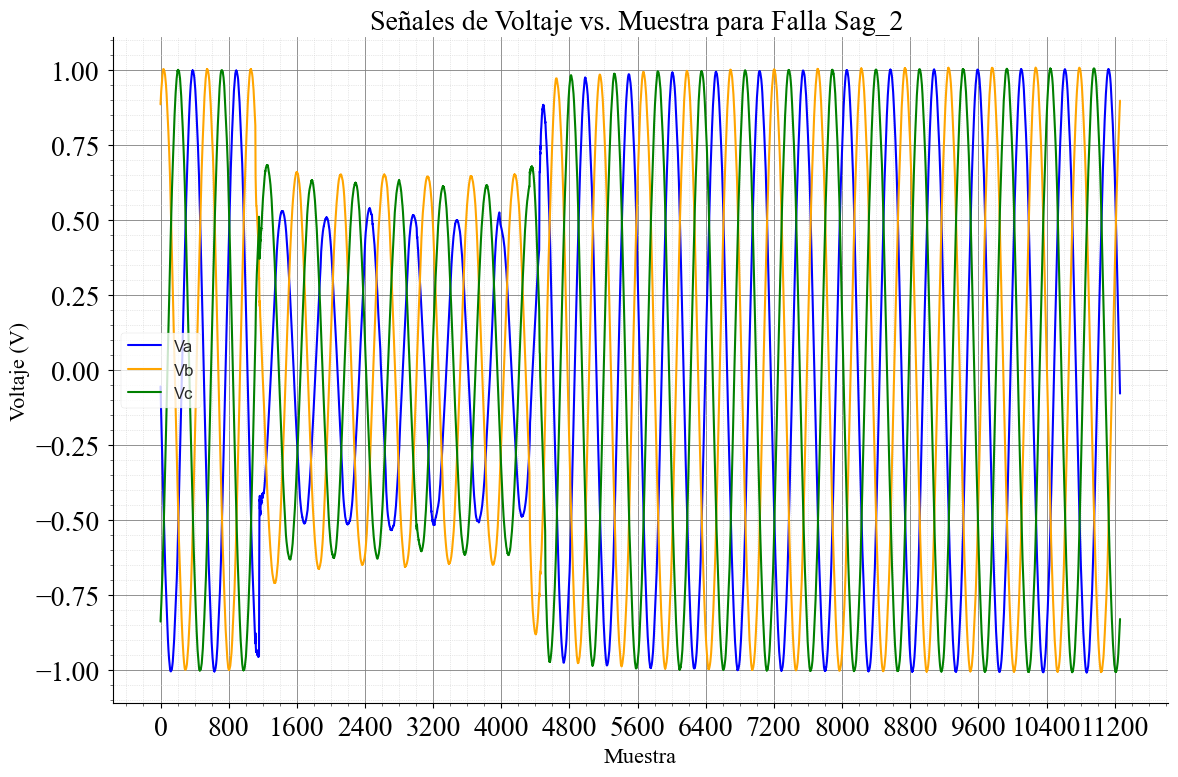

Gráfica generada y guardada como 'voltaje_vs_muestra_cada_100.png'


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.ticker as mticker
def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 14
    plt.rcParams['axes.labelsize'] = 18
    plt.rcParams['axes.titlesize'] = 20
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14
    plt.rcParams['legend.fontsize'] = 12
    plt.rcParams['lines.linewidth'] = 1.5

# Asegúrate de que la ruta al archivo sea la correcta
ruta = r'CHEC\Señales_CHEC_Normalizadas.csv'
try:
    data = pd.read_csv(ruta)
    id_falla_a_graficar = 'Sag_2'
    senal = data[data['ID_Falla'] == id_falla_a_graficar]

    x = np.arange(len(senal))
    #print(len(senal))
    y1 = senal['Va']
    y2 = senal['Vb']
    y3 = senal['Vc']

    # Usamos subplots para tener un control más directo sobre los ejes (ax)
    fig, ax = plt.subplots(figsize=(12, 8))
    _setup_academic_style()
    sns.set_style("whitegrid")

    ax.plot(x, y1, label='Va', color='blue')   
    ax.plot(x, y2, label='Vb', color='orange')
    ax.plot(x, y3, label='Vc', color='green')
    
    ax.set_xlabel('Muestra')
    ax.set_ylabel('Voltaje (V)')
    ax.set_title(f'Señales de Voltaje vs. Muestra para Falla {id_falla_a_graficar} ')
    ax.legend()
    
    # --- AJUSTE PARA GRILLA CADA 100 MUESTRAS ---
    # La única línea que cambia es esta: el número pasa de 10 a 100.
    ax.xaxis.set_major_locator(mticker.MultipleLocator(800))

    # Activamos las marcas menores para las subdivisiones
    ax.minorticks_on()
    
    # Configuramos la apariencia de las grillas
    ax.grid(which='major', linestyle='-', linewidth='0.6', color='gray')
    ax.grid(which='minor', linestyle=':', linewidth='0.5', color='lightgray')
    # --- FIN DE LA MODIFICACIÓN ---
    
    fig.tight_layout()
    plt.show()
    #fig.savefig('voltaje_vs_muestra_cada_100.png')
    #plt.close(fig)
    
    print("Gráfica generada y guardada como 'voltaje_vs_muestra_cada_100.png'")

except FileNotFoundError:
    print(f"Error: No se pudo encontrar el archivo en la ruta '{ruta}'")
except Exception as e:
    print(f"Ocurrió un error: {e}")

## Extracción de Metadatos

In [36]:
# -----------------------------------------------------------------------------
# 5. FUNCIÓN DE CONSOLIDACIÓN DE RESULTADOS 
# -----------------------------------------------------------------------------
def consolidar_resultados(id_falla: str, resultados_analisis: Dict[str, Any]) -> pd.DataFrame:
    """
    Convierte el diccionario de resultados estructurado en un DataFrame plano,
    agrupando las tres fases en una sola fila por ID_Falla y asumiendo que 
    Segmento_Algoritmo_1 es el inicio del primer evento en la fase A.
    """
    
    # Estructura de la fila final (solo una por ID_Falla)
    fila_final = {
        'ID_Falla': id_falla,
        'Segmento_Algoritmo_1': -1,  # Inicio en muestras del evento dominante (ej. Fase A)
        'Segmento_Algoritmo_2': -1,  # Fin en muestras del evento dominante (ej. Fase A)
        
        # Indicadores de fase afectada (0: No, 1: Sí)
        'Va_2': 0,
        'Vb_2': 0,
        'Vc_2': 0,
        
        # Clases asignadas por fase
        'Clase_Clasificador_Mono_A': 'Normal',
        'Clase_Clasificador_Mono_B': 'Normal',
        'Clase_Clasificador_Mono_C': 'Normal'
    }

    primer_segmento_establecido = False
    
    # 1. Procesar resultados por fase para llenar la fila_final
    for nombre_fase, eventos in resultados_analisis['resultados_por_fase'].items():
        
        # Check si se detectó al menos un evento en esta fase
        if eventos:
            # Por simplicidad, tomamos el PRIMER evento detectado para la clasificación de la fila
            primer_evento = eventos[0]
            t_ini, t_fin = primer_evento['intervalo_muestras']

            # A. Establecer la CLASE ASIGNADA (Clase_Clasificador_Mono_X)
            fila_final[f'Clase_Clasificador_Mono_{nombre_fase}'] = primer_evento['clase']
            
            # B. Establecer el indicador de FASE AFECTADA (Va_2, Vb_2, Vc_2)
            fila_final[f'V{nombre_fase.lower()}_2'] = 1 # 1 indica que está afectada
            
            # C. Establecer el Segmento_Algoritmo_1 y Segmento_Algoritmo_2
            # Se usa el primer evento detectado en la primera fase con evento como referencia
            if not primer_segmento_establecido:
                fila_final['Segmento_Algoritmo_1'] = t_ini
                fila_final['Segmento_Algoritmo_2'] = t_fin
                primer_segmento_establecido = True
                
        # Si NO hay eventos, los valores por defecto (0 para VX_2, 'Normal' para Clase_Mono_X) se mantienen.

    # 2. Manejar el caso donde no se detectó NINGÚN evento en ninguna fase
    if fila_final['Segmento_Algoritmo_1'] == -1:
        # Si no se detectó nada, por convención, el segmento puede ser (0, 0) o simplemente mantener -1
        # Aquí lo dejamos en (0, 0) para indicar que se revisó la señal, pero no se encontró nada.
        fila_final['Segmento_Algoritmo_1'] = 0
        fila_final['Segmento_Algoritmo_2'] = 0
        
    
    # 3. Devolver un DataFrame con la única fila resultante
    return pd.DataFrame([fila_final])


# -----------------------------------------------------------------------------
# 6. FUNCIÓN PRINCIPAL DE PROCESAMIENTO POR LOTES 
# -----------------------------------------------------------------------------
# Esta función permanece igual, ya que solo llama a la nueva 'consolidar_resultados'
# que devuelve un DataFrame con el formato deseado.
def procesar_csv_por_lotes(ruta_activos: str, ruta_csv_entrada: str, ruta_csv_salida: str):
    """
    Carga todos los activos y procesa cada ID_Falla único del CSV, 
    guardando los resultados en un único archivo de salida.
    """
    
    # --- A. CARGA Y PREPARACIÓN INICIAL ---
    
    # 1. Cargar activos del modelo una sola vez
    activos = cargar_activos_modelo(ruta_activos)
    if not activos:
        print("Terminando el proceso debido a errores de carga de activos.")
        return

    # 2. Cargar el CSV completo para obtener todos los ID_Falla únicos
    try:
        data_completa = pd.read_csv(ruta_csv_entrada)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo CSV en {ruta_csv_entrada}.")
        return

    # Obtener y ordenar los ID_Falla (usando la lógica de ordenación numérica)
    ids_falla = data_completa['ID_Falla'].unique()
    
    # Creación de la columna numérica temporal para ordenar 'Sag_1', 'Sag_2', ..., 'Sag_10'
    id_df = pd.DataFrame({'ID_Falla': ids_falla})
    # Asegúrate de manejar posibles errores si 'ID_Falla' no siempre tiene el prefijo 'Sag_'
    id_df['ID_Num'] = id_df['ID_Falla'].str.replace('Sag_', '', regex=False).str.extract(r'(\d+)').fillna(-1).astype(int)
    ids_ordenados = id_df.sort_values(by='ID_Num')['ID_Falla'].tolist()
    
    print(f"\nSe encontraron {len(ids_ordenados)} IDs de Falla únicos para procesar.")
    
    
    # --- B. PROCESAMIENTO Y CONSOLIDACIÓN ---
    
    resultados_finales_df = [] # Lista para almacenar DataFrames de cada ID_Falla
    
    for i, id_falla in enumerate(ids_ordenados):
        print(f"\n====================== Procesando {id_falla} ({i+1}/{len(ids_ordenados)}) ======================")
        
        # 3. Cargar (filtrar) la señal específica
        # Usamos el DataFrame completo filtrando, que es más rápido que leer el CSV en cada iteración
        senal_df = data_completa[data_completa['ID_Falla'] == id_falla].copy()
        
        if senal_df.empty:
            print(f"Advertencia: No se encontraron datos para {id_falla}. Saltando.")
            continue
            
        # 4. Análisis de la señal (Clasificación y Segmentación)
        # NOTA: 'analizar_evento_por_fase' debe estar definida y disponible.
        resultados_analisis = analizar_evento_por_fase(senal_df, activos)
        
        # 5. Consolidación del resultado (AHORA UNA SOLA FILA POR FALLA)
        df_consolidado = consolidar_resultados(id_falla, resultados_analisis)
        
        if not df_consolidado.empty:
            resultados_finales_df.append(df_consolidado)
            
    # 6. Unir todos los resultados y guardar
    if resultados_finales_df:
        df_final_guardar = pd.concat(resultados_finales_df, ignore_index=True)
        # Reordenar las columnas para coincidir con la imagen (opcional, pero buena práctica)
        orden_columnas = ['ID_Falla', 'Segmento_Algoritmo_1', 'Segmento_Algoritmo_2', 
                          'Va_2', 'Vb_2', 'Vc_2', 
                          'Clase_Clasificador_Mono_A', 'Clase_Clasificador_Mono_B', 'Clase_Clasificador_Mono_C']
        
        # Asegurarse de que solo existen las columnas necesarias antes de reordenar
        cols_existentes = [col for col in orden_columnas if col in df_final_guardar.columns]
        df_final_guardar = df_final_guardar[cols_existentes]
        
        df_final_guardar.to_csv(ruta_csv_salida, index=False)
        print(f"\n========================================================")
        print(f"Proceso COMPLETADO. Resultados guardados en: {ruta_csv_salida}")
        print(f"Total de fallas procesadas: {len(df_final_guardar)}")
        print("========================================================")
    else:
        print("\nNo se generaron resultados para guardar.")

# -----------------------------------------------------------------------------
# 7. FUNCIÓN MAIN (PUNTO DE ENTRADA)
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    # --- CONFIGURACIÓN DE RUTAS ---
    RUTA_CARPETA_ACTIVOS = r'Modelos\Mono' 
    RUTA_CSV_ENTRADA = r'CHEC\Señales_CHEC_Normalizadas.csv'
    RUTA_CSV_SALIDA = r'CHEC\Señales_CHEC_Clasificadas_1.csv'


    # Ejecutar el proceso principal
    procesar_csv_por_lotes(RUTA_CARPETA_ACTIVOS, RUTA_CSV_ENTRADA, RUTA_CSV_SALIDA)

--- Cargando activos desde: Modelos\Mono ---
¡Activos cargados exitosamente!

Se encontraron 31 IDs de Falla únicos para procesar.

====================== Procesando Sag_1 (1/31) ======================
Frecuencia de Muestreo 34774.16842218355
No se detectaron eventos en la Fase B.

====================== Procesando Sag_2 (2/31) ======================
Frecuencia de Muestreo 34670.5871762812

====================== Procesando Sag_3 (3/31) ======================
Frecuencia de Muestreo 35234.39554589809
No se detectaron eventos en la Fase C.

====================== Procesando Sag_4 (4/31) ======================
Frecuencia de Muestreo 18893.39872604154

====================== Procesando Sag_5 (5/31) ======================
Frecuencia de Muestreo 35988.69300098481
No se detectaron eventos en la Fase B.
No se detectaron eventos en la Fase C.

====================== Procesando Sag_6 (6/31) ======================
Frecuencia de Muestreo 35829.27486486195
No se detectaron eventos en la Fase B.

==

## Extracción Trifasico

In [7]:
def clasificar_senal_trifasica_retorno(ruta_csv: str, id_falla: str, activos: Dict[str, Any], data_completa: pd.DataFrame):
    """
    Carga la señal, detecta el evento GLOBAL, extrae características trifásicas y clasifica,
    DEVOLVIENDO el resultado principal.
    """
    modelo_cargado = activos['modelo']
    label_encoder_cargado = activos['encoder']
    model_columns = activos['columnas']
    
    # Filtrar la señal (más rápido que leer el CSV)
    senal_df = data_completa[data_completa['ID_Falla'] == id_falla].copy()
    if senal_df.empty:
        return None

    x = senal_df['Time'] 
    y1, y2, y3 = senal_df['Va'].values, senal_df['Vb'].values, senal_df['Vc'].values

    tiempo = x.iloc[-1]
    fs = len(x)/tiempo
    
    # Calcular RMS nominal (Asumido)
    rms_nom = rms_nominal(y1, fs) 
    
    # Detección del Evento GLOBAL
    t_ini, t_final = encontrar_intervalo_global(y1, y2, y3, fs, umbral_sag=0.9)
    
    if t_ini is None or t_ini == t_final:
        return {'ID_Falla': id_falla, 'Clase_Clasificador_Tri': 'Normal'}

    # Segmentación trifásica
    segmento_A = y1[t_ini:t_final]
    segmento_B = y2[t_ini:t_final]
    segmento_C = y3[t_ini:t_final]

    # Extracción de Características
    caracteristicas = extraer_caracteristicas_trifasicas(segmento_A, segmento_B, segmento_C, fs, rms_nom)

    # Preparación y Predicción
    df_para_predecir = pd.DataFrame([caracteristicas])
    df_para_predecir = df_para_predecir[model_columns]

    prediccion_numerica = modelo_cargado.predict(df_para_predecir)
    prediccion_texto = label_encoder_cargado.inverse_transform(prediccion_numerica)[0]
    
    return {'ID_Falla': id_falla, 'Clase_Clasificador_Tri': prediccion_texto}


def procesar_csv_por_lotes_trifasico(ruta_activos: str, ruta_csv_entrada: str, ruta_csv_salida: str):
    """
    Carga el modelo trifásico y procesa cada ID_Falla único del CSV, 
    guardando únicamente la ID_Falla y la clase asignada global.
    """
    
    # --- A. CARGA Y PREPARACIÓN INICIAL ---
    
    # 1. Cargar activos del modelo trifásico
    print(f"--- 1. Cargando activos del modelo TRIFÁSICO desde: {ruta_activos} ---")
    try:
        activos = {
            "modelo": joblib.load(os.path.join(ruta_activos, 'modelo_trifasico.joblib')),
            "encoder": joblib.load(os.path.join(ruta_activos, 'label_encoder_trifasico.joblib')),
            "columnas": joblib.load(os.path.join(ruta_activos, 'model_columns_trifasico.joblib'))
        }
        print("¡Activos trifásicos cargados exitosamente!")
    except FileNotFoundError as e:
        print(f"Error: No se encontraron los archivos trifásicos en {ruta_activos}. {e}")
        return

    # 2. Cargar el CSV completo 
    try:
        data_completa = pd.read_csv(ruta_csv_entrada)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo CSV en {ruta_csv_entrada}.")
        return

    # Obtener IDs de Falla
    ids_falla = data_completa['ID_Falla'].unique()
    
    # Ordenar los IDs para un procesamiento secuencial
    id_df = pd.DataFrame({'ID_Falla': ids_falla})
    id_df['ID_Num'] = id_df['ID_Falla'].str.replace('Sag_', '', regex=False).str.extract(r'(\d+)').fillna(-1).astype(int)
    ids_ordenados = id_df.sort_values(by='ID_Num')['ID_Falla'].tolist()
    
    print(f"\nSe encontraron {len(ids_ordenados)} IDs de Falla únicos para procesar.")
    
    
    # --- B. PROCESAMIENTO Y CONSOLIDACIÓN ---
    
    resultados_finales: List[Dict[str, str]] = [] # Lista para almacenar diccionarios simples
    
    for i, id_falla in enumerate(ids_ordenados):
        print(f"\n====================== Procesando {id_falla} ({i+1}/{len(ids_ordenados)}) ======================")
        
        # Llamar a la función de clasificación adaptada
        resultado = clasificar_senal_trifasica_retorno(
            ruta_csv_entrada, 
            id_falla, 
            activos, 
            data_completa
        )
        
        if resultado is not None:
            resultados_finales.append(resultado)
            print(f"Clasificación final: {resultado['Clase_Clasificador_Tri']}")

    # 3. Unir todos los resultados y guardar
    if resultados_finales:
        df_final_guardar = pd.DataFrame(resultados_finales)
        df_final_guardar.to_csv(ruta_csv_salida, index=False)
        
        print(f"\n========================================================")
        print(f"Proceso COMPLETADO. Resultados guardados en: {ruta_csv_salida}")
        print(f"Total de fallas clasificadas: {len(df_final_guardar)}")
        print("========================================================")
    else:
        print("\nNo se generaron resultados para guardar.")


# -----------------------------------------------------------------------------
# 7. FUNCIÓN MAIN (PUNTO DE ENTRADA)
# -----------------------------------------------------------------------------
if __name__ == "__main__":
    # --- CONFIGURACIÓN DE RUTAS ---
    # RUTA de la carpeta que contiene modelo_trifasico.joblib, etc.
    RUTA_CARPETA_ACTIVOS = r'Modelos\Tri' 
    
    # RUTA del CSV de entrada con todas las señales
    RUTA_CSV_ENTRADA = r'CHEC\Señales_CHEC_Normalizadas.csv'
    
    # RUTA del CSV de salida con los resultados consolidados (solo ID y Clase)
    RUTA_CSV_SALIDA = r'CHEC\Señales_CHEC_Tri_Clasificadas_1.csv'

    # Ejecutar el proceso principal
    procesar_csv_por_lotes_trifasico(RUTA_CARPETA_ACTIVOS, RUTA_CSV_ENTRADA, RUTA_CSV_SALIDA)

--- 1. Cargando activos del modelo TRIFÁSICO desde: Modelos\Tri ---
¡Activos trifásicos cargados exitosamente!

Se encontraron 31 IDs de Falla únicos para procesar.

====================== Procesando Sag_1 (1/31) ======================
0.7392130860560705
Clasificación final: Sag_A

====================== Procesando Sag_2 (2/31) ======================
0.7401084214312619
Clasificación final: Sag_F

====================== Procesando Sag_3 (3/31) ======================
0.734954059804114
Clasificación final: Sag_A

====================== Procesando Sag_4 (4/31) ======================
0.7498516151546071
Clasificación final: Sag_A

====================== Procesando Sag_5 (5/31) ======================
0.7409692203749862
Clasificación final: Sag_A

====================== Procesando Sag_6 (6/31) ======================
0.7440937421089375
Clasificación final: Sag_A

====================== Procesando Sag_7 (7/31) ======================
0.7337538821461436
Clasificación final: Sag_A

================

## Graficas

Verificando existencia de funciones de lógica...
Funciones de lógica encontradas.
--- Cargando activos desde: Modelos\Mono ---
¡Activos cargados exitosamente!

--- Iniciando Procesamiento de Tareas ---

--- PROCESANDO TAREA 1/5 ---

--- Cargando CSV Monofásico: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv ---
Frecuencia de Muestreo (Monofásico): 15360.00 Hz (Usando valor proporcionado)
Objetivo: Analizar únicamente la columna 'Sag_1'.
Analizando Columna (Evento): Sag_1...

     RESULTADOS PARA: Prueba_Clase5_Sag1 (Col: Sag_1) 
Frecuencia de Muestreo: 15360.00 Hz

--- Análisis de Eje: Sag_1 ---
  Evento #1 detectado entre 0.0783s y 0.1598s
  Clasificación: 'Sag'
  Confianza del modelo:
    - Sag                |  81.56% | ████████████████████████
    - Sag_Multiple       |  18.26% | █████
    - Sag_Armonico       |   0.11% | 
Generando visualización...
Generando eje de tiempo en segundos usando Fs.

Error Crítico al generar la visualización 

KeyboardInterrupt: 

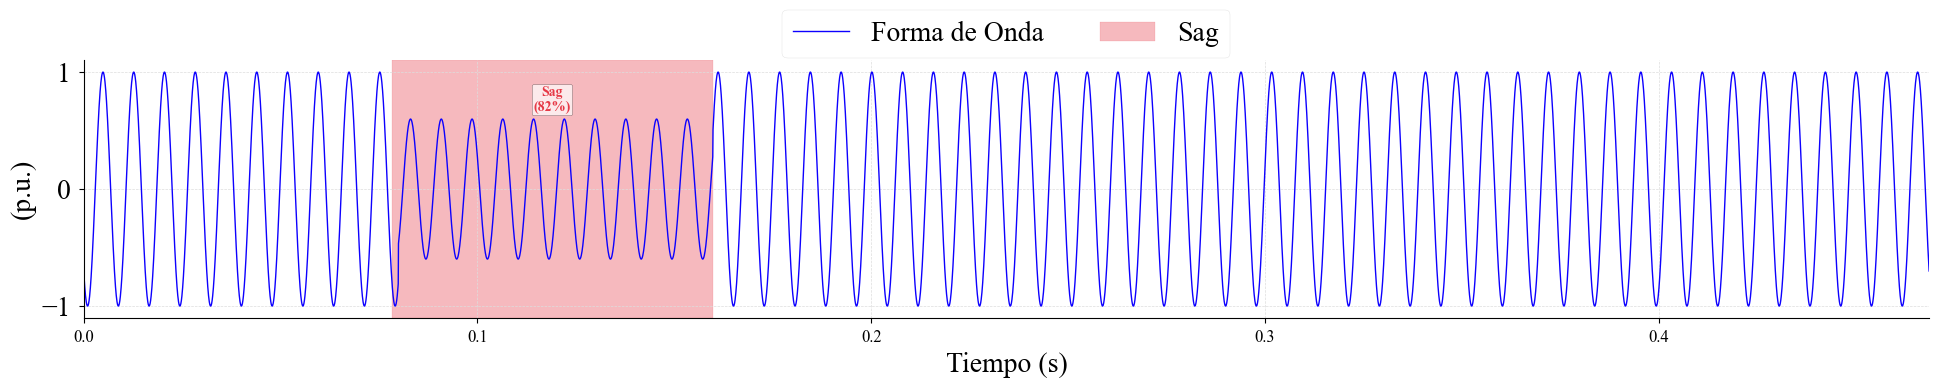

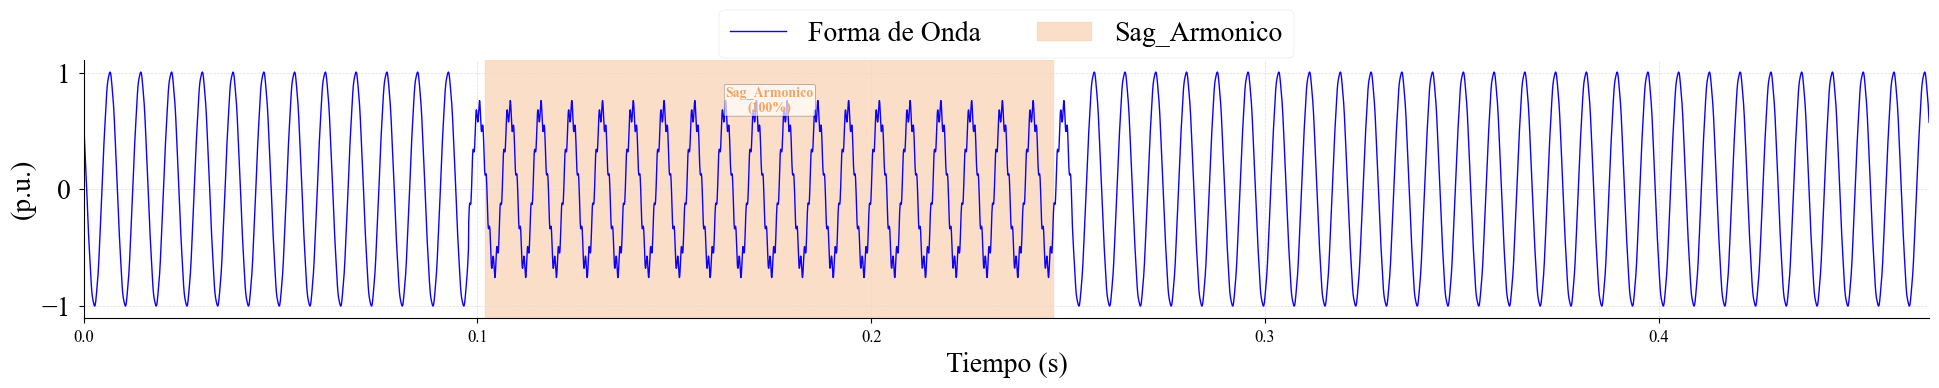

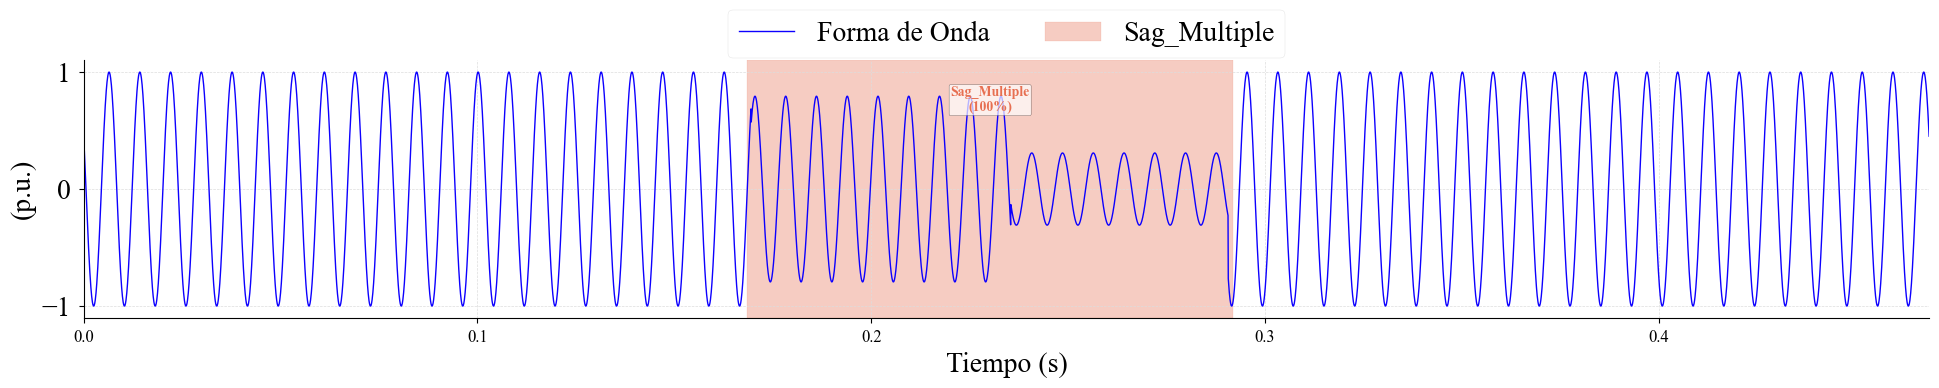

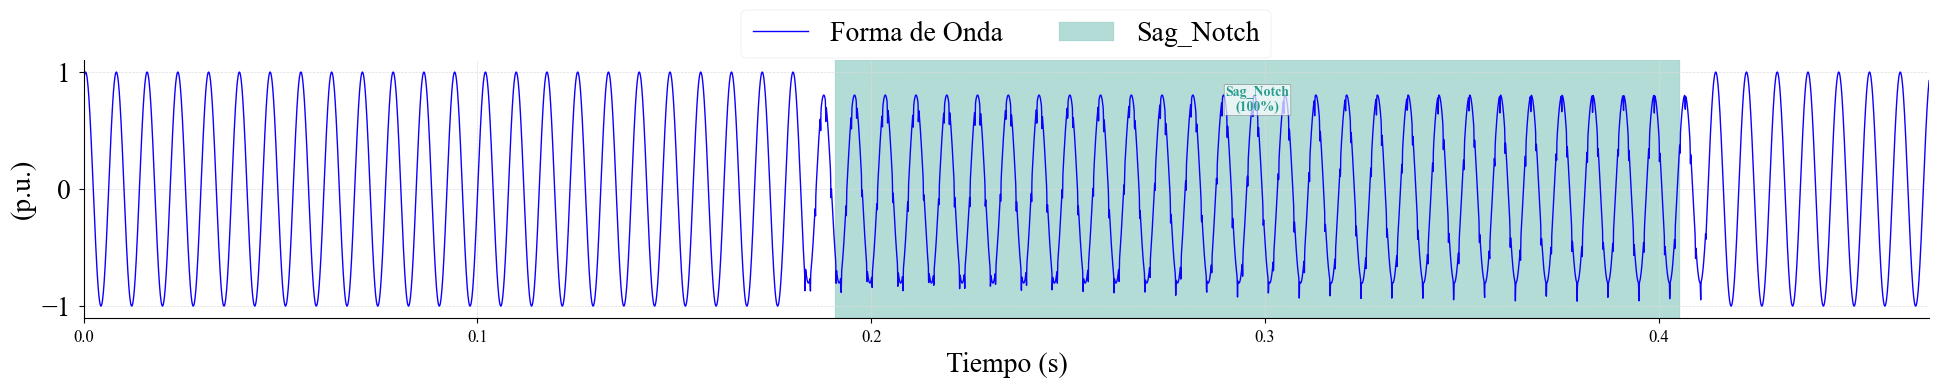

In [10]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib # ¡Asegúrate de importar joblib!
from typing import Dict, Any, Optional, List # Para mejor 'type hinting'

# -----------------------------------------------------------------------------
# 1. FUNCIÓN DE CARGA DE ACTIVOS (Sin cambios)
# -----------------------------------------------------------------------------
def cargar_activos_modelo(ruta_carpeta: str) -> Dict[str, Any]:
    """Carga el modelo, encoder y columnas desde una carpeta específica."""
    print(f"--- Cargando activos desde: {ruta_carpeta} ---")
    try:
        activos = {
            "modelo": joblib.load(f'{ruta_carpeta}/modelo_xgboost.joblib'),
            "encoder": joblib.load(f'{ruta_carpeta}/label_encoder.joblib'),
            "columnas": joblib.load(f'{ruta_carpeta}/model_columns.joblib')
        }
        print("¡Activos cargados exitosamente!")
        return activos
    except FileNotFoundError as e:
        print(f"Error: No se encontraron los archivos en {ruta_carpeta}. {e}")
        return {}
    except Exception as e:
        print(f"Error inesperado al cargar activos: {e}")
        return {}

# -----------------------------------------------------------------------------
# 2.A FUNCIÓN DE LÓGICA CENTRAL (REUTILIZABLE)
# -----------------------------------------------------------------------------
def analizar_una_sola_senal(senal_fase: np.ndarray,
                            fs: float,
                            activos_modelo: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Toma UN array (una fase o una columna), detecta todos los eventos
    y devuelve una lista de resultados de clasificación.

    Llama a las funciones globales definidas en el notebook.
    """
    resultados_eventos = []
    # ¡Llamando a tu función global!
    try:
        # Asegúrate que tu función exista y tenga estos parámetros
        intervalos_detectados = detectar_eventos_con_fusion(senal_fase, fs=fs, umbral_sag=0.9)
    except NameError:
        print("Error Fatal: La función 'detectar_eventos_con_fusion' no está definida en el notebook.")
        return []
    except Exception as e:
        print(f"Error durante la detección de eventos: {e}")
        return []

    if not intervalos_detectados:
        return [] # Devuelve lista vacía si no hay eventos

    modelo = activos_modelo.get('modelo')
    encoder = activos_modelo.get('encoder')
    columnas_modelo = activos_modelo.get('columnas')

    if not all([modelo, encoder, columnas_modelo is not None]):
         print("Error: Faltan activos del modelo (modelo, encoder o columnas).")
         return []

    # Procesa CADA evento encontrado en la señal
    for i, (t_ini, t_fin) in enumerate(intervalos_detectados):
        # Validar índices
        if not (isinstance(t_ini, int) and isinstance(t_fin, int) and 0 <= t_ini < t_fin <= len(senal_fase)):
            print(f"Advertencia: Intervalo inválido ({t_ini}, {t_fin}) detectado. Saltando evento.")
            continue
            
        segmento = senal_fase[t_ini:t_fin]
        if len(segmento) == 0: continue

        # ¡Llamando a tus funciones globales!
        try:
            # Asegúrate que tus funciones existan y tengan estos parámetros
            rms_nom = rms_nominal(segmento, fs)
            caracteristicas = extraer_caracteristicas(segmento, fs, rms_nom)
        except NameError:
             print("Error Fatal: 'extraer_caracteristicas' o 'rms_nominal' no están definidas en el notebook.")
             return resultados_eventos # Devuelve lo que tenga hasta ahora
        except Exception as e:
            print(f"Error durante la extracción de características para el evento {i+1}: {e}")
            continue # Salta este evento problemático

        # Preparación del DataFrame para el modelo
        try:
            df_pred = pd.DataFrame([caracteristicas])
            # Reordenar y seleccionar columnas que el modelo espera
            df_pred = df_pred[columnas_modelo]
        except KeyError as e:
            print(f"Error: Característica faltante o nombre incorrecto devuelto por 'extraer_caracteristicas'.")
            print(f"El modelo espera: {list(columnas_modelo)}")
            print(f"Recibido: {list(caracteristicas.keys())}")
            print(f"Error específico: {e}. Saltando evento {i+1}.")
            continue
        except Exception as e:
             print(f"Error al preparar DataFrame para predicción: {e}")
             continue

        # Predicción
        try:
            pred_num = modelo.predict(df_pred)
            pred_texto = encoder.inverse_transform(pred_num)[0]
            probabilidades = modelo.predict_proba(df_pred)[0]
        except Exception as e:
            print(f"Error durante la predicción del modelo para el evento {i+1}: {e}")
            continue # Salta este evento

        resultado_evento = {
            "evento_nro": i + 1,
            "intervalo_muestras": (t_ini, t_fin),
            "clase": pred_texto,
            "confianza": dict(zip(encoder.classes_, probabilidades))
        }
        resultados_eventos.append(resultado_evento)

    return resultados_eventos

# -----------------------------------------------------------------------------
# 2.B PIPELINE TRIFÁSICO (Carga y Análisis)
# -----------------------------------------------------------------------------
def cargar_senal_trifasica(ruta_csv: str, id_falla: str) -> Optional[pd.DataFrame]:
    """Carga un DataFrame y filtra una señal trifásica específica por su ID."""
    print(f"\n--- Cargando señal trifásica '{id_falla}' de {ruta_csv} ---")
    try:
        data = pd.read_csv(ruta_csv)
        # Filtrar por ID_Falla
        senal_df = data[data['ID_Falla'] == id_falla].copy()
        if senal_df.empty:
            print(f"Advertencia: No se encontró la falla con ID '{id_falla}' en {ruta_csv}.")
            return None

        # Validar columnas necesarias
        columnas_requeridas = ['Time', 'Va', 'Vb', 'Vc']
        if not all(col in senal_df.columns for col in columnas_requeridas):
            print(f"Error: El CSV trifásico {ruta_csv} (filtrado por '{id_falla}') no contiene todas las columnas: {columnas_requeridas}.")
            return None
        print(f"Señal '{id_falla}' cargada correctamente ({len(senal_df)} muestras).")
        return senal_df
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo CSV en {ruta_csv}.")
        return None
    except Exception as e:
        print(f"Error inesperado al cargar señal trifásica: {e}")
        return None

def analizar_evento_trifasico(senal_df: pd.DataFrame,
                              activos_modelo: Dict[str, Any]) -> Dict[str, Any]:
    """
    Analiza un DataFrame trifásico (Va, Vb, Vc) llamando a
    la función 'analizar_una_sola_senal' para cada fase.
    """
    resultados_generales = {"fs": 0, "tipo": "trifasico", "datos_ejes": {}, "resultados_ejes": {}}
    try:
        x, va, vb, vc = senal_df['Time'], senal_df['Va'], senal_df['Vb'], senal_df['Vc']
        # Cálculo robusto de Fs
        if len(x) > 1 and x.iloc[-1] > x.iloc[0]:
             fs = (len(x) - 1) / (x.iloc[-1] - x.iloc[0])
        elif len(x) > 1:
             fs = 1.0 / np.mean(np.diff(x)) # Alternativa si el tiempo no empieza en 0
             print(f"Advertencia: Tiempo no parece empezar en 0 o ser monótono. Fs estimada: {fs:.2f} Hz")
        else:
             fs = 0 # No se puede calcular fs
             print("Advertencia: No se pudo calcular la frecuencia de muestreo.")
             
        resultados_generales["fs"] = fs
        print(f"Frecuencia de Muestreo (Trifásico): {fs:.2f} Hz")

        fases = {'A': va.values, 'B': vb.values, 'C': vc.values}

        for nombre_fase, senal_fase in fases.items():
            print(f"Analizando Fase {nombre_fase}...")
            # Llama a la función central
            resultados_eventos = analizar_una_sola_senal(senal_fase, fs, activos_modelo)

            if not resultados_eventos:
                print(f"No se detectaron eventos en la Fase {nombre_fase}.")

            resultados_generales["datos_ejes"][nombre_fase] = senal_fase
            resultados_generales["resultados_ejes"][nombre_fase] = resultados_eventos

    except KeyError as e:
         print(f"Error: Falta una columna esperada en el DataFrame trifásico: {e}")
    except Exception as e:
         print(f"Error inesperado durante el análisis trifásico: {e}")
         
    return resultados_generales

# -----------------------------------------------------------------------------
# 2.C PIPELINE MONOFÁSICO (Carga y Análisis - MODIFICADO PARA COLUMNA ÚNICA)
# -----------------------------------------------------------------------------
def analizar_csv_monofasico(ruta_csv: str,
                            activos_modelo: Dict[str, Any],
                            fs_conocida: Optional[float] = None, # <-- NUEVO PARÁMETRO
                            columna_especifica: Optional[str] = None) -> Dict[str, Any]:
    """
    Carga un CSV monofásico, usa la FS proporcionada, y analiza la columna
    específica o todas las columnas.
    """
    print(f"\n--- Cargando CSV Monofásico: {ruta_csv} ---")
    resultados_generales = {"fs": 0, "tipo": "monofasico", "datos_ejes": {}, "resultados_ejes": {}, "tiempo_indices": np.array([])} # Cambiado 'tiempo' a 'tiempo_indices'
    try:
        df = pd.read_csv(ruta_csv)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo CSV en {ruta_csv}.")
        return resultados_generales
    except Exception as e:
        print(f"Error inesperado al cargar CSV monofásico: {e}")
        return resultados_generales

    # --- LÓGICA DE FS MODIFICADA ---
    if fs_conocida is None or fs_conocida <= 0:
        print(f"Error Fatal: No se proporcionó una frecuencia de muestreo válida ('fs_conocida') para el archivo monofásico {ruta_csv}.")
        # Intentar calcular como fallback (puede ser incorrecto si 'Time' no es tiempo real)
        if 'Time' in df.columns and len(df['Time']) > 1 and df['Time'].iloc[-1] > df['Time'].iloc[0]:
             fs_calculada = (len(df['Time']) - 1) / (df['Time'].iloc[-1] - df['Time'].iloc[0])
             print(f"Advertencia: Usando Fs calculada ({fs_calculada:.2f} Hz) como fallback. Esto puede ser incorrecto si la columna 'Time' son índices.")
             fs = fs_calculada
        else:
             print("Error: Imposible determinar Fs.")
             return resultados_generales # Salir si no hay fs válida
    else:
        fs = fs_conocida # Usar la Fs proporcionada
    # --- FIN LÓGICA DE FS ---

    resultados_generales["fs"] = fs
    print(f"Frecuencia de Muestreo (Monofásico): {fs:.2f} Hz (Usando valor proporcionado)")

    # Guardar los índices (columna 'Time') si existe, si no, generar índices
    if 'Time' in df.columns:
        resultados_generales["tiempo_indices"] = df['Time'].values
        tiempo_col_presente = True
    else:
        # Si no hay columna 'Time', asumimos que las filas son las muestras
        num_muestras_temp = len(df)
        resultados_generales["tiempo_indices"] = np.arange(num_muestras_temp)
        tiempo_col_presente = False
        print("Advertencia: No se encontró columna 'Time'. Se usarán índices de fila como referencia.")


    # --- LÓGICA PARA SELECCIONAR COLUMNAS (Sin cambios) ---
    columnas_a_procesar = []
    columna_time_lower = 'time' if tiempo_col_presente else None # Solo excluir 'time' si existe

    if columna_especifica:
        if columna_especifica in df.columns:
            print(f"Objetivo: Analizar únicamente la columna '{columna_especifica}'.")
            columnas_a_procesar = [columna_especifica]
        else:
            print(f"Error: La columna especificada '{columna_especifica}' no existe en {ruta_csv}. Columnas disponibles: {list(df.columns)}")
            return resultados_generales
    else:
        print(f"Objetivo: Analizar todas las columnas de señal (excepto '{columna_time_lower}' si existe).")
        columnas_a_procesar = [col for col in df.columns if col.lower() != columna_time_lower]


    if not columnas_a_procesar:
        print("Advertencia: No se encontraron columnas de señal para analizar en el archivo.")
        return resultados_generales

    # --- BUCLE DE ANÁLISIS (Sin cambios en la lógica interna) ---
    for nombre_columna in columnas_a_procesar:
        print(f"Analizando Columna (Evento): {nombre_columna}...")
        if pd.api.types.is_numeric_dtype(df[nombre_columna]):
            senal_columna = df[nombre_columna].values

            # Llama a la función central (pasando la FS correcta)
            resultados_eventos = analizar_una_sola_senal(senal_columna, fs, activos_modelo)

            if not resultados_eventos:
                print(f"No se detectaron eventos en la columna {nombre_columna}.")

            resultados_generales["datos_ejes"][nombre_columna] = senal_columna
            resultados_generales["resultados_ejes"][nombre_columna] = resultados_eventos
        else:
            print(f"Advertencia: La columna '{nombre_columna}' no es numérica y será omitida.")

    return resultados_generales
# -----------------------------------------------------------------------------
# 3. FUNCIÓN DE PRESENTACIÓN DE RESULTADOS (GENERALIZADA)
# -----------------------------------------------------------------------------
def presentar_resultados(resultados: Dict[str, Any], id_falla_o_archivo: str):
    """Muestra los resultados del análisis (trifásico o monofásico) de forma estructurada."""
    print(f"\n===============================================")
    print(f"     RESULTADOS PARA: {id_falla_o_archivo} ")
    print("===============================================")

    if not resultados or "fs" not in resultados or not resultados.get("resultados_ejes"):
        print("Resultados no válidos, vacíos o sin ejes analizados.")
        return

    fs = resultados['fs']
    print(f"Frecuencia de Muestreo: {fs:.2f} Hz")

    for nombre_eje, eventos in resultados['resultados_ejes'].items():
        print(f"\n--- Análisis de Eje: {nombre_eje} ---")
        if not eventos:
            print("No se encontraron eventos.")
            continue

        for evento in eventos:
            t_ini, t_fin = evento.get('intervalo_muestras', (0, 0))
            clase = evento.get('clase', 'Desconocida')
            confianza_dict = evento.get('confianza', {})
            
            # Cálculo seguro de tiempos en segundos
            t_ini_s = t_ini / fs if fs > 0 else 0
            t_fin_s = t_fin / fs if fs > 0 else 0

            print(f"  Evento #{evento.get('evento_nro', '?')} detectado entre {t_ini_s:.4f}s y {t_fin_s:.4f}s")
            print(f"  Clasificación: '{clase}'")
            if confianza_dict:
                 print("  Confianza del modelo:")
                 confianza_ordenada = sorted(confianza_dict.items(), key=lambda item: item[1], reverse=True)
                 for nombre_clase, conf in confianza_ordenada:
                     if conf < 0.001: continue # Umbral más bajo para mostrar algo
                     barra = '█' * int(conf * 30)
                     print(f"    - {nombre_clase:<18} | {conf:7.2%} | {barra}")
            else:
                 print("  (Confianza no disponible)")


# -----------------------------------------------------------------------------
# 4. FUNCIÓN DE VISUALIZACIÓN (GENERALIZADA Y CON MEJORAS)
# -----------------------------------------------------------------------------
def _setup_academic_style():
    """Configura Matplotlib para un estilo visual formal/académico."""
    try:
        plt.style.use('seaborn-v0_8-paper')
    except OSError:
        print("Estilo 'seaborn-v0_8-paper' no encontrado, usando estilo por defecto.")
        
    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix', 'font.size': 20,
        'axes.labelsize': 20, 'axes.titlesize': 20,
        'xtick.labelsize': 12, 'ytick.labelsize': 20,
        'legend.fontsize': 20, # Reducido para más espacio
        'figure.figsize': (20, 6), # Más ancho, menos alto por defecto
        'lines.linewidth': 1.0, # Líneas más finas
        'grid.color': '#DDDDDD', # Gris más claro
        'grid.linestyle': '--', 'grid.linewidth': 0.5,
        'axes.spines.top': False, # Ocultar borde superior
        'axes.spines.right': False # Ocultar borde derecho
    })

def visualizar_analisis(resultados: dict, id_falla_o_archivo: str):
    """
    Crea un gráfico de N paneles (uno por eje) que visualiza los eventos
    detectados y clasificados.
    """
    if not resultados or not resultados.get("datos_ejes"):
        print("No hay datos que visualizar.")
        return

    _setup_academic_style()

    fs = resultados.get('fs', 0)
    datos_ejes = resultados['datos_ejes']
    resultados_ejes = resultados.get('resultados_ejes', {})
    tipo = resultados.get('tipo', 'desconocido')

    # --- DETERMINACIÓN DEL EJE DE TIEMPO (MODIFICADO) ---
    t = None
    num_muestras = 0
    if datos_ejes:
        # Tomar la longitud de la primera señal como referencia
        num_muestras = len(next(iter(datos_ejes.values()), []))

    if num_muestras > 0:
        if fs > 0:
            # SIEMPRE calcular el tiempo en segundos si FS es válida
            t = np.arange(num_muestras) / fs
            print("Generando eje de tiempo en segundos usando Fs.")
        else:
            # Fallback a índices si FS no es válida
            t = np.arange(num_muestras)
            print("Advertencia: Fs no válida. Usando índices de muestra en el eje X.")
    else:
        print("Error: No se encontraron datos de señal para determinar el eje de tiempo.")
        return # Salir si no hay datos

    if t is None or len(t) == 0:
         print("Error: El eje de tiempo está vacío o no se pudo calcular.")
         return

    colores_clases = {
        'Sag': '#E63946', 'Sag_Armonico': '#F4A261', 'Sag_Multiple': '#E76F51',
        'Sag_Notch': '#2A9D8F', 'Sag_Transitorios': '#457B9D', 'Normal': '#1D3557',
        'default': '#A8DADC' # Color por defecto más claro
    }

    num_ejes = len(datos_ejes)
    if num_ejes == 0:
        print("No hay ejes de datos para graficar.")
        return

    # Ajustar altura de la figura dinámicamente
    fig_height = max(5, 3 * num_ejes) # Mínimo 5, 3 por cada eje adicional
    fig, axes = plt.subplots(num_ejes, 1, figsize=(20, fig_height), sharex=True, squeeze=False)
    axes = axes.flatten() # Asegura que axes sea siempre un array 1D
    # Leyenda unificada
    legend_handles = {}

    for i, (nombre_eje, senal_eje) in enumerate(datos_ejes.items()):
        ax = axes[i]
        
        # Validar longitud de la señal vs tiempo
        if len(senal_eje) != len(t):
             print(f"Advertencia: Discrepancia en longitud para eje '{nombre_eje}'. Tiempo: {len(t)}, Señal: {len(senal_eje)}. Saltando gráfico.")
             ax.text(0.5, 0.5, 'Error de longitud de datos', ha='center', va='center', transform=ax.transAxes, color='red')
             continue

        # Graficar señal principal
        line, = ax.plot(t, senal_eje, color="#0D00FF", linewidth=1.0, label=f'Forma de Onda')
        if f'Forma de Onda' not in legend_handles:
             legend_handles[f'Forma de Onda'] = line

        eventos_eje = resultados_ejes.get(nombre_eje, [])

        if not eventos_eje:
            ax.text(0.5, 0.5, 'Sin eventos detectados', ha='center', va='center',
                    transform=ax.transAxes, fontsize=14, color='grey', style='italic')

        # Procesar eventos para este eje
        for evento_idx, evento in enumerate(eventos_eje):
            t_ini, t_fin = evento.get('intervalo_muestras', (None, None))
            clase = evento.get('clase', 'Desconocida')
            confianza_dict = evento.get('confianza', {})

            # Validar intervalo antes de usarlo
            if t_ini is None or t_fin is None or t_ini >= len(t) or t_fin > len(t) or t_ini >= t_fin:
                print(f"Advertencia: Intervalo inválido ({t_ini}, {t_fin}) para evento {evento_idx+1} en eje {nombre_eje}. Saltando.")
                continue

            # Obtener confianza y color
            confianza = max(confianza_dict.values()) if confianza_dict else 0.0
            color = colores_clases.get(clase, colores_clases['default'])

            # Dibujar rectángulo sombreado (axvspan)
            span = ax.axvspan(t[t_ini], t[t_fin], color=color, alpha=0.35, zorder=0) # Detrás de la línea
            if clase not in legend_handles:
                 legend_handles[clase] = mpatches.Patch(color=color, alpha=0.35, label=f'Evento: {clase}')


            # Escribir texto de clasificación
            # Calcular posición Y dinámicamente para evitar solapamientos
            y_pos_text = ax.get_ylim()[1] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * (0.1 + (evento_idx % 3) * 0.15) # Alternar altura
            
            ax.text(
                t[t_ini] + (t[t_fin] - t[t_ini])/2, # Centro horizontal
                y_pos_text,
                f"{clase}\n({confianza:.0%})", # Confianza sin decimales para ahorrar espacio
                ha='center', va='top', fontsize=10, fontweight='bold', color=color, # Fuente más pequeña
                bbox=dict(facecolor='white', alpha=0.7, pad=0.1, boxstyle='round,pad=0.1')
            )

        ax.set_ylabel('(p.u.)') # Salto de línea para más espacio
        ax.grid(True)
        ax.tick_params(axis='x', rotation=0) # Asegurar que no roten las etiquetas x

    # Añadir leyenda unificada arriba del primer gráfico
    if legend_handles and axes.size > 0:
        axes[0].legend(handles=legend_handles.values(), labels=legend_handles.keys(),
                       loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=min(len(legend_handles), 4), fancybox=True, shadow=False)


    if axes.size > 0:
        axes[-1].set_xlabel('Tiempo (s)')
        # Establecer límites X si hay datos
        if len(t)>0:
            axes[-1].set_xlim(t[0], t[-1])
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajustar márgenes
    plt.subplots_adjust(hspace=0.1) # Reducir espacio vertical entre subplots
    plt.savefig()
    plt.show()


# -----------------------------------------------------------------------------
# 5. BLOQUE PRINCIPAL (MODIFICADO para pasar FS conocida)
# -----------------------------------------------------------------------------
if __name__ == "__main__":

    # --- ¡ASEGÚRATE DE QUE TUS FUNCIONES GLOBALES EXISTAN! ---
    print("Verificando existencia de funciones de lógica...")
    required_funcs = ['detectar_eventos_con_fusion', 'extraer_caracteristicas', 'rms_nominal']
    if not all(func in globals() for func in required_funcs):
         print("ERROR FATAL: Funciones de lógica no definidas.")
         # raise NameError("Funciones de lógica no definidas.") # Descomenta para detener
    else:
         print("Funciones de lógica encontradas.")

    # --- Configuración del Análisis ---
    tareas_analisis = [
        # --- EJEMPLO TRIFÁSICO ---
        # Si tus CSV trifásicos SÍ tienen 'Time' en segundos, puedes omitir 'fs_conocida'
        # Si NO, añade 'fs_conocida' también aquí.
        #{"tipo": "trifasico",
        # "ruta_csv": r'Ruta\a\tu\archivo\trifasico.csv',
        # "id_falla": 'ID_Falla_Especifico',
        # #"fs_conocida": 15360.0 # <--- Opcional para trifásico
        # },

        # --- EJEMPLO MONOFÁSICO - UNA SOLA COLUMNA ---
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv', # ¡VERIFICA RUTA!
         "id_falla": 'Prueba_Clase5_Sag1',   # Etiqueta
         "columna_a_analizar": 'Sag_1',     # La columna específica
         "fs_conocida": 15360.0             # <-- ¡AÑADE LA FS CORRECTA AQUÍ! (Ejemplo)
         },
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Armonic\Clase_2_Armonico.csv', # ¡VERIFICA RUTA!
         "id_falla": 'Prueba_Clase5_Sag1',   # Etiqueta
         "columna_a_analizar": 'Sag_1',     # La columna específica
         "fs_conocida": 15360.0             # <-- ¡AÑADE LA FS CORRECTA AQUÍ! (Ejemplo)
         },
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Multiple\Clase_3_sagmultiple.csv', # ¡VERIFICA RUTA!
         "id_falla": 'Prueba_Clase5_Sag1',   # Etiqueta
         "columna_a_analizar": 'Sag_1',     # La columna específica
         "fs_conocida": 15360.0             # <-- ¡AÑADE LA FS CORRECTA AQUÍ! (Ejemplo)
         },
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Notch\Clase_4_sagnotch.csv', # ¡VERIFICA RUTA!
         "id_falla": 'Prueba_Clase5_Sag1',   # Etiqueta
         "columna_a_analizar": 'Sag_1',     # La columna específica
         "fs_conocida": 15360.0             # <-- ¡AÑADE LA FS CORRECTA AQUÍ! (Ejemplo)
         },
        # --- EJEMPLO MONOFÁSICO - OTRA COLUMNA ---
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Transitorios\Clase_5_Transitorios.csv', # ¡VERIFICA RUTA!
         "id_falla": 'Prueba_Clase5_Sag1',   # Etiqueta
         "columna_a_analizar": 'Sag_1',     # La columna específica
         "fs_conocida": 15360.0             # <-- ¡AÑADE LA FS CORRECTA AQUÍ! (Ejemplo)
         },
        # --- EJEMPLO MONOFÁSICO - TODAS LAS COLUMNAS ---
        # Analizará TODAS las columnas (Sag_1, Sag_2, etc.) del archivo
        #{"tipo": "monofasico",
        # "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Transitorios\Clase_5_Transitorios.csv', # ¡VERIFICA!
        # "id_falla": 'Prueba_Clase5_Completo',
        # "fs_conocida": 15360.0, # <-- ¡NECESITAS LA FS!
        # # "columna_a_analizar": None # Omitir para analizar todas
        # },
    ]

    # Ruta a tus modelos entrenados
    ruta_modelos = r'Modelos\Mono' # ¡VERIFICA ESTA RUTA!
    activos = cargar_activos_modelo(ruta_modelos)

    if not activos:
        print("No se pudieron cargar los activos del modelo. El script no puede continuar.")
    else:
        print("\n--- Iniciando Procesamiento de Tareas ---")
        for i, tarea in enumerate(tareas_analisis):
            print(f"\n--- PROCESANDO TAREA {i+1}/{len(tareas_analisis)} ---")
            resultados_analisis = {}

            tipo_tarea = tarea.get('tipo')
            ruta_csv_tarea = tarea.get('ruta_csv')
            id_falla_tarea = tarea.get('id_falla', f'Tarea_{i+1}')
            fs_tarea = tarea.get('fs_conocida', None) # <-- Obtener FS conocida

            if not tipo_tarea or not ruta_csv_tarea:
                 print("Error: La tarea no tiene 'tipo' o 'ruta_csv'. Saltando tarea.")
                 continue

            if tipo_tarea == 'trifasico':
                df_senal = cargar_senal_trifasica(ruta_csv_tarea, id_falla_tarea)
                if df_senal is not None:
                    # Podrías pasar fs_tarea aquí también si modificas analizar_evento_trifasico
                    resultados_analisis = analizar_evento_trifasico(df_senal, activos)

            elif tipo_tarea == 'monofasico':
                if fs_tarea is None: # Comprobación esencial para monofásico
                    print(f"Error: Falta 'fs_conocida' para la tarea monofásica '{id_falla_tarea}'. Saltando tarea.")
                    continue
                columna_target = tarea.get('columna_a_analizar', None)
                resultados_analisis = analizar_csv_monofasico(
                    ruta_csv_tarea,
                    activos,
                    fs_conocida=fs_tarea, # <-- PASAR LA FS
                    columna_especifica=columna_target
                )

            else:
                print(f"Tipo de tarea '{tipo_tarea}' no reconocido. Saltando tarea.")
                continue

            # --- Presentación y Visualización ---
            if resultados_analisis and resultados_analisis.get("datos_ejes"):
                etiqueta_tarea = id_falla_tarea
                if tipo_tarea == 'monofasico' and tarea.get('columna_a_analizar'):
                    etiqueta_tarea += f" (Col: {tarea['columna_a_analizar']})"

                presentar_resultados(resultados_analisis, etiqueta_tarea)
                try:
                    print("Generando visualización...")
                    visualizar_analisis(resultados_analisis, etiqueta_tarea)
                except Exception as e:
                    print(f"\nError Crítico al generar la visualización para '{etiqueta_tarea}': {e}")
                    # import traceback # Descomenta para depuración avanzada
                    # traceback.print_exc() # Descomenta para depuración avanzada
            else:
                 print(f"No se generaron resultados válidos para la tarea '{id_falla_tarea}'.")

        print("\n--- Procesamiento de todas las tareas completado. ---")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from typing import Dict, Any, Optional, List
import os # <--- Importar os para manejo de rutas
import re # <--- Importar re para limpiar nombres de archivo

# ... (El resto de tus importaciones y funciones anteriores:
#      _setup_academic_style, cargar_activos_modelo, analizar_una_sola_senal,
#      cargar_senal_trifasica, analizar_evento_trifasico,
#      analizar_csv_monofasico, presentar_resultados
#      SE MANTIENEN IGUAL) ...

# -----------------------------------------------------------------------------
# 4. FUNCIÓN DE VISUALIZACIÓN (MODIFICADA PARA GUARDAR SVG)
# -----------------------------------------------------------------------------
def _setup_academic_style():
    """Configura Matplotlib para un estilo visual formal/académico."""
    try:
        plt.style.use('seaborn-v0_8-paper')
    except OSError:
        print("Estilo 'seaborn-v0_8-paper' no encontrado, usando estilo por defecto.")

    plt.rcParams.update({
        'font.family': 'serif', 'font.serif': ['Times New Roman'],
        'mathtext.fontset': 'stix', 'font.size': 24,
        'axes.labelsize': 24, 'axes.titlesize': 24,
        'xtick.labelsize': 24, 'ytick.labelsize': 24,
        'legend.fontsize': 10, # Reducido para más espacio
        'figure.figsize': (20, 20), # Más ancho, menos alto por defecto
        'lines.linewidth': 1.0, # Líneas más finas
        'grid.color': '#DDDDDD', # Gris más claro
        'grid.linestyle': '--', 'grid.linewidth': 0.5,
        'axes.spines.top': False, # Ocultar borde superior
        'axes.spines.right': False, # Ocultar borde derecho
        'svg.fonttype': 'none', # <--- Importante para texto editable en SVG
        'axes.unicode_minus': False
    })

def visualizar_analisis(resultados: dict,
                        id_falla_o_archivo: str,
                        directorio_salida: str = "graficos_svg"): # <-- Nuevo argumento para la carpeta
    """
    Crea un gráfico de N paneles, visualiza los eventos Y GUARDA COMO SVG.
    """
    if not resultados or not resultados.get("datos_ejes"):
        print("No hay datos que visualizar.")
        return

    _setup_academic_style()

    fs = resultados.get('fs', 0)
    datos_ejes = resultados['datos_ejes']
    resultados_ejes = resultados.get('resultados_ejes', {})
    tipo = resultados.get('tipo', 'desconocido')

    t = None
    num_muestras = 0
    if datos_ejes:
        num_muestras = len(next(iter(datos_ejes.values()), []))

    if num_muestras > 0:
        if fs > 0:
            t = np.arange(num_muestras) / fs
            # print("Generando eje de tiempo en segundos usando Fs.") # Opcional: Descomentar para debug
        else:
            t = np.arange(num_muestras)
            print("Advertencia: Fs no válida. Usando índices de muestra en el eje X.")
    else:
        print("Error: No se encontraron datos de señal para determinar el eje de tiempo.")
        return

    if t is None or len(t) == 0:
         print("Error: El eje de tiempo está vacío o no se pudo calcular.")
         return

    colores_clases = {
        'Sag': '#E63946', 'Sag_Armonico': '#F4A261', 'Sag_Multiple': '#E76F51',
        'Sag_Notch': '#2A9D8F', 'Sag_Transitorios': '#457B9D', 'Normal': '#1D3557',
        'default': '#A8DADC'
    }

    num_ejes = len(datos_ejes)
    if num_ejes == 0:
        print("No hay ejes de datos para graficar.")
        return

    fig_height = max(5, 4 * num_ejes) # Ajustar altura si es necesario
    fig, axes = plt.subplots(num_ejes, 1, figsize=(20, fig_height), sharex=True, squeeze=False)
    axes = axes.flatten()
    legend_handles = {}


    for i, (nombre_eje, senal_eje) in enumerate(datos_ejes.items()):
        ax = axes[i]

        if len(senal_eje) != len(t):
             print(f"Advertencia: Discrepancia longitud eje '{nombre_eje}'. T:{len(t)}, S:{len(senal_eje)}. Saltando.")
             ax.text(0.5, 0.5, 'Error datos', ha='center', va='center', transform=ax.transAxes, color='red')
             continue

        line, = ax.plot(t, senal_eje, color="#0D00FF", linewidth=1.0, label=f'Forma de Onda')
        if f'Forma de Onda' not in legend_handles:
             legend_handles[f'Forma de Onda'] = line

        eventos_eje = resultados_ejes.get(nombre_eje, [])

        if not eventos_eje:
            ax.text(0.5, 0.5, 'Sin eventos detectados', ha='center', va='center',
                    transform=ax.transAxes, fontsize=20, color='grey', style='italic')

        for evento_idx, evento in enumerate(eventos_eje):
            t_ini, t_fin = evento.get('intervalo_muestras', (None, None))
            clase = evento.get('clase', 'Desconocida')
            clase_latex = clase.replace('_', r'\_') # <--- MODIFICACIÓN 1: Escapar guion bajo
            confianza_dict = evento.get('confianza', {})
            confianza_dict = evento.get('confianza', {})

            if t_ini is None or t_fin is None or t_ini >= len(t) or t_fin > len(t) or t_ini >= t_fin:
                print(f"Advertencia: Intervalo inválido ({t_ini}, {t_fin}) ev {evento_idx+1} eje {nombre_eje}. Saltando.")
                continue

            confianza = max(confianza_dict.values()) if confianza_dict else 0.0
            color = colores_clases.get(clase, colores_clases['default'])

            span = ax.axvspan(t[t_ini], t[t_fin], color=color, alpha=0.35, zorder=0)
            if clase_latex not in legend_handles:
                 legend_handles[clase] = mpatches.Patch(color=color, alpha=0.35, label=f'Evento: {clase}')

            y_pos_text = ax.get_ylim()[1] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * (0.1 + (evento_idx % 3) * 0.15)
            
            # Asegurar que el texto esté dentro de los límites y ajustar si es necesario
            y_min_lim, y_max_lim = ax.get_ylim()
            y_pos_text = min(y_max_lim * 0.95, max(y_min_lim * 0.95 if y_min_lim < 0 else y_max_lim * 0.1, y_pos_text))


            ax.text(
                t[t_ini] + (t[t_fin] - t[t_ini])/2,
                y_pos_text,
                f"{clase_latex}\n({confianza:.0%})",
                ha='center', va='top', fontsize=20, fontweight='bold', color=color,
                bbox=dict(facecolor='white', alpha=0.7, pad=0.1, boxstyle='round,pad=0.1')
            )

        ax.set_ylabel('Amplitud (p.u.)')
        ax.grid(True)
        ax.tick_params(axis='x', rotation=0)

    if legend_handles and axes.size > 0:
        # Colocar leyenda encima del primer gráfico
        axes[0].legend(handles=legend_handles.values(), labels=legend_handles.keys(),
                       loc='lower center', bbox_to_anchor=(0.5, 1.05), # Ajustar posición
                       ncol=min(len(legend_handles), 5), # Más columnas si hay espacio
                       fancybox=True, shadow=False, fontsize=20) # Fuente leyenda más pequeña


    if axes.size > 0:
        axes[-1].set_xlabel('Tiempo (s)')
        if len(t)>0:
            axes[-1].set_xlim(t[0], t[-1])

    plt.tight_layout(rect=[0, 0.03, 1, 0.93]) # Ajustar rect para dejar espacio a leyenda/título
    plt.subplots_adjust(hspace=0.15) # Un poco más de espacio

    # --- CAMBIO PRINCIPAL: GUARDAR EN LUGAR DE MOSTRAR ---
    try:
        # 1. Crear directorio si no existe
        os.makedirs(directorio_salida, exist_ok=True)

        # 2. Limpiar el id para usarlo como nombre de archivo
        #    Quita caracteres no válidos y reemplaza espacios
        nombre_base_limpio = re.sub(r'[\\/*?:"<>|]', "", id_falla_o_archivo) # Quita inválidos
        nombre_base_limpio = re.sub(r'\s+', '_', nombre_base_limpio) # Reemplaza espacios

        # 3. Construir la ruta completa
        nombre_archivo = f"{nombre_base_limpio}.svg"
        ruta_completa_svg = os.path.join(directorio_salida, nombre_archivo)

        # 4. Guardar la figura
        plt.savefig(ruta_completa_svg, format='svg', bbox_inches='tight')
        print(f"Gráfico guardado exitosamente como: {ruta_completa_svg}")

    except Exception as e:
        print(f"Error al guardar el gráfico como SVG: {e}")

    # 5. Cerrar la figura para liberar memoria
    plt.close(fig)
    # plt.show() # <--- Comentado o eliminado


# -----------------------------------------------------------------------------
# 5. BLOQUE PRINCIPAL (MODIFICADO para pasar Directorio de Salida)
# -----------------------------------------------------------------------------
if __name__ == "__main__":

    # --- ¡ASEGÚRATE DE QUE TUS FUNCIONES GLOBALES EXISTAN! ---
    print("Verificando existencia de funciones de lógica...")
    required_funcs = ['detectar_eventos_con_fusion', 'extraer_caracteristicas', 'rms_nominal']
    if not all(func in globals() for func in required_funcs):
         print("ERROR FATAL: Funciones de lógica no definidas.")
         # raise NameError("Funciones de lógica no definidas.")
    else:
         print("Funciones de lógica encontradas.")

    # --- Configuración del Análisis ---
    tareas_analisis = [
        # --- EJEMPLO MONOFÁSICO - UNA SOLA COLUMNA ---
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv', # ¡VERIFICA!
         "id_falla": 'Prueba_Clase1_Sag1',
         "columna_a_analizar": 'Sag_1',
         "fs_conocida": 7200
         },
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Armonic\Clase_2_Armonico.csv', # ¡VERIFICA!
         "id_falla": 'Prueba_Clase2_Armonico1',
         "columna_a_analizar": 'Sag_1',
         "fs_conocida": 7200
         },
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Multiple\Clase_3_sagmultiple.csv', # ¡VERIFICA!
         "id_falla": 'Prueba_Clase3_Multiple1',
         "columna_a_analizar": 'Sag_1',
         "fs_conocida": 7200
         },
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Notch\Clase_4_sagnotch.csv', # ¡VERIFICA!
         "id_falla": 'Prueba_Clase4_Notch1',
         "columna_a_analizar": 'Sag_1',
         "fs_conocida": 7200
         },
        {"tipo": "monofasico",
         "ruta_csv": r'C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag_Transitorios\Clase_5_Transitorios.csv', # ¡VERIFICA!
         "id_falla": 'Prueba_Clase5_Transitorio1',
         "columna_a_analizar": 'Sag_1',
         "fs_conocida": 7200
         },
    ]

    # Ruta a tus modelos entrenados
    ruta_modelos = r'Modelos\Mono' # ¡VERIFICA!
    
    # --- Directorio donde se guardarán los SVG ---
    directorio_salida_svg = "Resultados_Graficos_SVG" # Puedes cambiar el nombre

    activos = cargar_activos_modelo(ruta_modelos)

    if not activos:
        print("No se pudieron cargar los activos del modelo.")
    else:
        print("\n--- Iniciando Procesamiento de Tareas ---")
        for i, tarea in enumerate(tareas_analisis):
            print(f"\n--- PROCESANDO TAREA {i+1}/{len(tareas_analisis)} ---")
            resultados_analisis = {}

            tipo_tarea = tarea.get('tipo')
            ruta_csv_tarea = tarea.get('ruta_csv')
            id_falla_tarea = tarea.get('id_falla', f'Tarea_{i+1}')
            fs_tarea = tarea.get('fs_conocida', None)

            if not tipo_tarea or not ruta_csv_tarea:
                 print("Error: Tarea inválida. Saltando.")
                 continue

            if tipo_tarea == 'trifasico':
                df_senal = cargar_senal_trifasica(ruta_csv_tarea, id_falla_tarea)
                if df_senal is not None:
                    resultados_analisis = analizar_evento_trifasico(df_senal, activos)

            elif tipo_tarea == 'monofasico':
                if fs_tarea is None:
                    print(f"Error: Falta 'fs_conocida' para tarea monofásica '{id_falla_tarea}'. Saltando.")
                    continue
                columna_target = tarea.get('columna_a_analizar', None)
                resultados_analisis = analizar_csv_monofasico(
                    ruta_csv_tarea,
                    activos,
                    fs_conocida=fs_tarea,
                    columna_especifica=columna_target
                )

            else:
                print(f"Tipo de tarea '{tipo_tarea}' no reconocido. Saltando.")
                continue

            # --- Presentación y Visualización/Guardado ---
            if resultados_analisis and resultados_analisis.get("datos_ejes"):
                etiqueta_tarea = id_falla_tarea
                if tipo_tarea == 'monofasico' and tarea.get('columna_a_analizar'):
                    etiqueta_tarea += f" (Col_{tarea['columna_a_analizar']})" # Etiqueta más limpia

                presentar_resultados(resultados_analisis, etiqueta_tarea)
                try:
                    print("Generando y guardando visualización...")
                    # Pasamos el directorio de salida a la función
                    visualizar_analisis(resultados_analisis, etiqueta_tarea, directorio_salida_svg)
                except Exception as e:
                    print(f"\nError Crítico al generar/guardar visualización para '{etiqueta_tarea}': {e}")
                    # import traceback
                    # traceback.print_exc()
            else:
                 print(f"No se generaron resultados válidos para la tarea '{id_falla_tarea}'.")

        print(f"\n--- Procesamiento completado. Los gráficos SVG se guardaron en la carpeta: '{directorio_salida_svg}' ---")

Verificando existencia de funciones de lógica...
Funciones de lógica encontradas.
--- Cargando activos MONOFÁSICOS desde: Modelos\Mono ---
   - modelo cargado desde modelo_xgboost.joblib
   - encoder cargado desde label_encoder.joblib
   - columnas cargado desde model_columns.joblib
¡Activos cargados exitosamente!
   - Clases del encoder: ['Normal', 'Sag', 'Sag_Armonico', 'Sag_Multiple', 'Sag_Notch', 'Sag_Transitorios']
   - Número de columnas esperadas por modelo: 19

--- Iniciando Procesamiento de Tareas ---

--- PROCESANDO TAREA 1/5 ---

--- Cargando CSV Monofásico: C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Monofasico\Pruebas\Sag\Clase_1_sag.csv ---
Frecuencia de Muestreo (Monofásico): 7200.00 Hz (Usando valor proporcionado)
Objetivo: Analizar únicamente la columna 'Sag_1'.
Analizando Columna (Evento): Sag_1...

     RESULTADOS PARA: Prueba_Clase1_Sag1 (Col_Sag_1) 
Frecuencia de Muestreo: 7200.00 Hz

--- Análisis de Eje: Sag_1 ---
  Evento #1 [1207:2448] -> 0.1676s a 0.340

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from typing import Dict, Any, Optional, List, Tuple
import os
import re
try:
    import pyarrow
except ImportError:
    print("Advertencia: 'pyarrow' no instalada. Instala con: pip install pyarrow")

# -----------------------------------------------------------------------------
# 0. VERIFICACIÓN DE FUNCIONES DE LÓGICA (Definidas Previamente)
# -----------------------------------------------------------------------------
print("Verificando existencia de funciones de lógica...")
required_funcs = [
    'detectar_eventos_con_fusion', # Para análisis monofásico (si lo usas)
    'extraer_caracteristicas',    # Para análisis monofásico (si lo usas)
    'rms_nominal',                # Usada por ambos
    'encontrar_intervalo_global', # Para análisis trifásico global
    'extraer_caracteristicas_trifasicas' # Para análisis trifásico global
]
missing_funcs = [func for func in required_funcs if func not in globals()]
if missing_funcs:
     print(f"ERROR FATAL: Las siguientes funciones de lógica no están definidas: {', '.join(missing_funcs)}")
     print("Asegúrate de ejecutar las celdas donde se definen antes de ejecutar esta.")
     # raise NameError(f"Funciones de lógica no definidas: {', '.join(missing_funcs)}") # Descomenta para detener
else:
     print("Funciones de lógica encontradas.")

# -----------------------------------------------------------------------------
# 1. FUNCIÓN DE CARGA DE ACTIVOS (Ajustada para nombres trifásicos)
# -----------------------------------------------------------------------------
def cargar_activos_modelo(ruta_carpeta: str, es_trifasico: bool = False) -> Dict[str, Any]:
    """Carga modelo, encoder y columnas, adaptando nombres si es trifásico."""
    print(f"--- Cargando activos {'TRIFÁSICOS' if es_trifasico else 'MONOFÁSICOS'} desde: {ruta_carpeta} ---")
    modelo_base = 'modelo_trifasico.joblib' if es_trifasico else 'modelo_xgboost.joblib' # Ajusta si tu modelo tri tiene otro nombre
    encoder_base = 'label_encoder_trifasico.joblib' if es_trifasico else 'label_encoder.joblib'
    columnas_base = 'model_columns_trifasico.joblib' if es_trifasico else 'model_columns.joblib'
    archivos_esperados = {
        "modelo": [modelo_base, 'modelo_randomforest.joblib', 'modelo.joblib'], # Añade otros nombres si usas RF, etc.
        "encoder": [encoder_base],
        "columnas": [columnas_base]
    }
    activos = {}
    try:
        for activo_nombre, posibles_nombres in archivos_esperados.items():
            encontrado = False
            # Prioriza nombre específico
            nombres_ordenados = sorted(posibles_nombres, key=lambda x: x != archivos_esperados[activo_nombre][0])
            for nombre_archivo in nombres_ordenados:
                ruta_completa = os.path.join(ruta_carpeta, nombre_archivo)
                if os.path.exists(ruta_completa):
                    activos[activo_nombre] = joblib.load(ruta_completa)
                    print(f"   - {activo_nombre} cargado desde {nombre_archivo}")
                    encontrado = True
                    break
            if not encontrado: raise FileNotFoundError(f"No se encontró '{activo_nombre}' en {ruta_carpeta} (buscado: {posibles_nombres})")
        print("¡Activos cargados exitosamente!")
        # Validar consistencia encoder/columnas si es posible
        if 'encoder' in activos and 'columnas' in activos:
             print(f"   - Clases del encoder: {list(activos['encoder'].classes_)}")
             print(f"   - Número de columnas esperadas por modelo: {len(activos['columnas'])}")
        return activos
    except FileNotFoundError as e: print(f"Error: {e}"); return {}
    except Exception as e: print(f"Error inesperado al cargar activos: {e}"); return {}

# -----------------------------------------------------------------------------
# 2.A FUNCIÓN DE LÓGICA CENTRAL MONOFÁSICA (Opcional, si la necesitas)
# -----------------------------------------------------------------------------
# def analizar_una_sola_senal(...):
#    ... (Puedes mantener esta función si también analizas señales monofásicas)

# -----------------------------------------------------------------------------
# 2.B FUNCIÓN DE ANÁLISIS TRIFÁSICO GLOBAL (CORREGIDA Y FINAL)
# -----------------------------------------------------------------------------
def analizar_evento_trifasico_global(senal_df: pd.DataFrame,
                                     activos_modelo: Dict[str, Any],
                                     col_tiempo: str = 'timestamp',
                                     cols_fase: List[str] = ['Fase A', 'Fase B', 'Fase C'],
                                     fs_conocida: Optional[float] = None) -> Dict[str, Any]:
    """Detecta UN evento GLOBAL, extrae características TRIFÁSICAS y clasifica."""
    print("\n--- Iniciando Análisis Trifásico Global ---")
    resultados_generales = {"fs": 0, "tipo": "trifasico_global", "datos_ejes": {}, "resultados_ejes": {}}
    try:
        columnas_requeridas = [col_tiempo] + cols_fase
        if not all(col in senal_df.columns for col in columnas_requeridas):
            print(f"Error: Faltan columnas: {columnas_requeridas}. Encontradas: {list(senal_df.columns)}"); return resultados_generales
        x = senal_df[col_tiempo]
        y1, y2, y3 = senal_df[cols_fase[0]].values, senal_df[cols_fase[1]].values, senal_df[cols_fase[2]].values
        resultados_generales["datos_ejes"] = {cols_fase[0]: y1, cols_fase[1]: y2, cols_fase[2]: y3}

        fs = 0
        if fs_conocida is not None and fs_conocida > 0: fs = fs_conocida; print(f"Fs proporcionada: {fs:.2f} Hz")
        elif len(x) > 1 and x.iloc[-1] > x.iloc[0]: fs = (len(x) - 1) / (x.iloc[-1] - x.iloc[0]); print(f"Fs calculada de '{col_tiempo}': {fs:.2f} Hz")
        elif len(x) > 1: fs = 1.0 / np.mean(np.diff(x)); print(f"Adv: Tiempo no monótono? Fs estimada: {fs:.2f} Hz")
        else: print("Error: No se pudo calcular Fs.")
        if fs <= 0: print("Error Fatal: Fs no válida."); return resultados_generales
        resultados_generales["fs"] = fs

        print("Detectando intervalo global..."); t_ini, t_final = None, None # Inicializar
        try: t_ini, t_final = encontrar_intervalo_global(y1, y2, y3, fs, umbral_sag=0.9)
        except NameError: print("Error Fatal: 'encontrar_intervalo_global' no definida."); return resultados_generales
        except Exception as e: print(f"Error detección global: {e}"); return resultados_generales

        resultado_evento_global = {}
        if t_ini is None or t_final is None or t_ini >= t_final or t_ini >= len(y1) or t_final > len(y1):
            print("No se detectó evento global válido. Clasificando como 'Normal'.")
            resultado_evento_global = {"evento_nro": 1, "intervalo_muestras": (None, None), "clase": "Normal", "confianza": {"Normal": 1.0}}
        else:
            print(f"Evento global detectado: [{t_ini}:{t_final}]")
            segmento_A, segmento_B, segmento_C = y1[t_ini:t_final], y2[t_ini:t_final], y3[t_ini:t_final]
            if not all(len(s)>0 for s in [segmento_A, segmento_B, segmento_C]): print("Error: Segmento vacío."); return resultados_generales
            
            print("Extrayendo características trifásicas..."); caracteristicas = {}
            try:
                # ¡Usa rms_nominal de la fase A (o la primera fase) como referencia!
                rms_nom = rms_nominal(y1, fs) if 'rms_nominal' in globals() else 1.0 # Fallback a 1.0 si no existe
                caracteristicas = extraer_caracteristicas_trifasicas(segmento_A, segmento_B, segmento_C, fs, rms_nom)
            except NameError: print("Error Fatal: 'extraer_caracteristicas_trifasicas' no definida."); return resultados_generales
            except Exception as e: print(f"Error extracción características tri: {e}"); return resultados_generales
            if not caracteristicas: print("Error: Extracción de características no devolvió resultados."); return resultados_generales

            modelo = activos_modelo.get('modelo'); encoder = activos_modelo.get('encoder'); columnas_modelo = activos_modelo.get('columnas')
            if not all([modelo, encoder, columnas_modelo is not None]): print("Error: Faltan activos."); return resultados_generales

            try:
                df_pred = pd.DataFrame([caracteristicas])
                df_pred = df_pred[columnas_modelo] # Asegurar orden
            except KeyError as e: print(f"Error: Característica TRI faltante/incorrecta. Espera:{list(columnas_modelo)}, Recibido:{list(caracteristicas.keys())}. E:{e}."); return resultados_generales
            except Exception as e: print(f"Error preparando DF tri: {e}"); return resultados_generales

            try:
                print("Clasificando evento global..."); pred_num = modelo.predict(df_pred); pred_texto = encoder.inverse_transform(pred_num)[0]; probabilidades = modelo.predict_proba(df_pred)[0]
                print(f"Clasificación: {pred_texto}")
                resultado_evento_global = {"evento_nro": 1, "intervalo_muestras": (t_ini, t_final), "clase": pred_texto, "confianza": dict(zip(encoder.classes_, probabilidades))}
            except Exception as e: print(f"Error predicción tri: {e}"); return resultados_generales

        if resultado_evento_global:
             for nombre_fase in cols_fase: resultados_generales["resultados_ejes"][nombre_fase] = [resultado_evento_global.copy()]
        else:
             for nombre_fase in cols_fase: resultados_generales["resultados_ejes"][nombre_fase] = []
    except KeyError as e: print(f"Error: Falta columna '{e}'.");
    except Exception as e: print(f"Error inesperado análisis tri global: {e}");
    return resultados_generales

# -----------------------------------------------------------------------------
# 2.D FUNCIÓN DE CARGA PARQUET (Sin cambios)
# -----------------------------------------------------------------------------
def cargar_senal_trifasica_parquet(ruta_parquet: str, signal_id: str, col_id: str = 'signal_id', cols_necesarias: List[str] = ['timestamp', 'Phase_A', 'Phase_B', 'Phase_C', 'signal_id', 'etiqueta']) -> Optional[pd.DataFrame]:
    """Carga datos desde Parquet y filtra por ID."""
    # ... (Sin cambios) ...
    print(f"\n--- Cargando señal Parquet '{signal_id}' de {ruta_parquet} ---")
    try:
        data = pd.read_parquet(ruta_parquet, columns=cols_necesarias)
        if not all(col in data.columns for col in cols_necesarias): print(f"Error: Parquet {ruta_parquet} no contiene {cols_necesarias}. Encontradas: {list(data.columns)}"); return None
        senal_df = data[data[col_id] == signal_id].copy()
        if senal_df.empty: print(f"Adv: No se encontró ID '{signal_id}' en {ruta_parquet}."); return None
        print(f"Señal Parquet '{signal_id}' cargada ({len(senal_df)} muestras)."); return senal_df
    except FileNotFoundError: print(f"Error: No se encontró Parquet en {ruta_parquet}."); return None
    except ImportError: print("Error: Falta 'pyarrow'."); return None
    except KeyError as e: print(f"Error: Falta columna '{e}'."); return None
    except Exception as e: print(f"Error inesperado cargando Parquet: {e}"); return None

# --- Funciones de Carga/Análisis CSV (Opcionales, omitidas por brevedad) ---

# -----------------------------------------------------------------------------
# 3. FUNCIÓN DE PRESENTACIÓN DE RESULTADOS (CORREGIDA y GENERALIZADA)
# -----------------------------------------------------------------------------
def presentar_resultados(resultados: Dict[str, Any], id_presentacion: str):
    """Muestra los resultados del análisis de forma estructurada."""
    print(f"\n===============================================")
    print(f"     RESULTADOS PARA: {id_presentacion} ")
    print("===============================================")
    if not resultados or "fs" not in resultados or not resultados.get("resultados_ejes"): print("Resultados no válidos."); return
    fs = resultados['fs']; print(f"Frecuencia de Muestreo: {fs:.2f} Hz")
    tipo_analisis = resultados.get("tipo", "desconocido")

    # Bucle adaptado para mostrar solo una vez en modo global
    processed_global_event = False # Bandera para controlar la impresión global
    for nombre_eje, eventos in resultados['resultados_ejes'].items():
        # Si es global y ya procesamos, saltar ejes restantes
        if tipo_analisis == "trifasico_global" and processed_global_event: continue

        print(f"\n--- {'Análisis Global (aplicado a todas las fases)' if tipo_analisis == 'trifasico_global' else f'Análisis de Eje: {nombre_eje}'} ---")
        if not eventos: print("No se encontraron eventos."); continue

        # Mostrar solo el primer evento si es global
        evento = eventos[0]
        t_ini, t_fin = evento.get('intervalo_muestras', (None, None))
        clase = evento.get('clase', '?')
        confianza_dict = evento.get('confianza', {})

        if t_ini is not None and t_fin is not None:
             t_ini_s = t_ini / fs if fs > 0 else 0; t_fin_s = t_fin / fs if fs > 0 else 0
             print(f"  Evento #{evento.get('evento_nro', '?')} [{t_ini}:{t_fin}] -> {t_ini_s:.4f}s a {t_fin_s:.4f}s")
        else: print(f"  Evento #{evento.get('evento_nro', '?')}") # Caso 'Normal' global

        print(f"  Clasificación: '{clase}'")
        if confianza_dict:
             print("  Confianza:"); conf_ord = sorted(confianza_dict.items(), key=lambda i: i[1], reverse=True)
             for nc, conf in conf_ord:
                 # --- CORRECCIÓN DEL ERROR UnboundLocalError ---
                 if conf < 0.001: continue # Si la confianza es muy baja, saltar ANTES de calcular barra
                 barra = '█' * int(conf * 25) # Calcular barra solo si no se salta
                 print(f"    - {nc:<18} | {conf:7.2%} | {barra}")
                 # --- FIN CORRECCIÓN ---
        else: print("  (Confianza no disponible)")

        # Marcar como procesado si es global para no repetir en otros ejes
        if tipo_analisis == "trifasico_global": processed_global_event = True


# -----------------------------------------------------------------------------
# 4. FUNCIÓN DE VISUALIZACIÓN (CORREGIDA y Ajustada para modo global)
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# 4. FUNCIÓN DE VISUALIZACIÓN (CORREGIDA para trifásico global en UN SOLO PLOT)
# -----------------------------------------------------------------------------
def _setup_academic_style():
    """Configura Matplotlib."""
    try: plt.style.use('seaborn-v0_8-paper')
    except OSError: print("Estilo 'seaborn-v0_8-paper' no encontrado.")
    # Ajusta los tamaños de fuente globales si es necesario
    plt.rcParams.update({
        'font.family':'serif','font.serif':['Times New Roman'],'mathtext.fontset':'stix','font.size':20,
        'axes.labelsize':20,'axes.titlesize':20,'xtick.labelsize':20,'ytick.labelsize':20,
        'legend.fontsize':20, # Tamaño leyenda ajustado
        'figure.figsize':(18, 7), # Un solo plot, más ancho
        'lines.linewidth':1.2, # Líneas ligeramente más gruesas
        'grid.color':'#DDDDDD','grid.linestyle':'--','grid.linewidth':0.5,
        'axes.spines.top':False,'axes.spines.right':False,
        'svg.fonttype':'none'
    })

def visualizar_analisis(resultados: dict,
                        id_presentacion: str,
                        directorio_salida: str = "graficos_svg"):
    """
    Crea UN SOLO gráfico para trifásico global, visualiza eventos Y GUARDA SVG.
    Para monofásico, sigue creando N paneles.
    """
    if not resultados or not resultados.get("datos_ejes"): print("No hay datos que visualizar."); return
    _setup_academic_style()

    fs = resultados.get('fs', 0)
    datos_ejes = resultados['datos_ejes']
    resultados_ejes = resultados.get('resultados_ejes', {})
    tipo = resultados.get('tipo', 'desconocido')

    t = None; num_muestras = 0
    if datos_ejes: num_muestras = len(next(iter(datos_ejes.values()), []))
    if num_muestras > 0:
        if fs > 0: t = np.arange(num_muestras) / fs
        else: t = np.arange(num_muestras); print("Advertencia: Usando índices en eje X.")
    else: print("Error: No se puede determinar eje de tiempo."); return
    if t is None or len(t) == 0: print("Error: Eje de tiempo vacío."); return

    # --- DICCIONARIO DE COLORES CORREGIDO PARA CLASES TRIFÁSICAS ---
    # ¡¡¡IMPORTANTE!!! Ajusta las claves ('Sag_A', etc.) para que coincidan
    # EXACTAMENTE con las salidas de tu 'label_encoder_trifasico.joblib'
    colores_clases = {
        'Sag_A': '#E63946', # Rojo (Tipo A)
        'Sag_B': '#F4A261', # Naranja (Tipo B)
        'Sag_C': '#E76F51', # Naranja Oscuro (Tipo C)
        'Sag_D': '#2A9D8F', # Verde Azulado (Tipo D)
        'Sag_E': '#457B9D', # Azul (Tipo E)
        'Sag_F': '#1D3557', # Azul Oscuro (Tipo F)
        'Sag_G': '#6A0DAD', # Púrpura (Tipo G)
        'Normal': '#4CAF50', # Verde
        'default': '#BDBDBD' # Gris
    }
    # --- FIN CORRECCIÓN COLORES ---

    num_ejes_datos = len(datos_ejes)
    if num_ejes_datos == 0: print("No hay ejes para graficar."); return

    # --- LÓGICA PARA UN SOLO PLOT TRIFÁSICO ---
    if tipo == "trifasico_global":
        num_paneles_plot = 1
        fig_height = 7 # Altura fija para un solo plot
        fases_a_plotear = list(datos_ejes.keys()) # ['Phase_A', 'Phase_B', 'Phase_C']
        colores_fases = ['#0D00FF', '#FF7F0E', '#2CA02C'] # Azul, Naranja, Verde para A, B, C
    else: # Monofásico (mantiene N paneles)
        num_paneles_plot = num_ejes_datos
        fig_height = max(5, 4 * num_paneles_plot)
        fases_a_plotear = list(datos_ejes.keys()) # Analizará cada columna como un eje
        colores_fases = ["#0D00FF"] * num_paneles_plot # Mismo color si son paneles separados

    fig, axes = plt.subplots(num_paneles_plot, 1, figsize=(20, fig_height), sharex=True, squeeze=False)
    axes = axes.flatten()
    legend_handles = {}

    evento_global_info = None
    if tipo == "trifasico_global":
        for eje, eventos in resultados_ejes.items():
            if eventos: evento_global_info = eventos[0]; break

    ax = axes[0] # Usar siempre el primer (y único) panel para trifásico global

    # --- Graficar las 3 fases en el mismo panel (si es trifásico global) ---
    if tipo == "trifasico_global":
        for i, nombre_fase in enumerate(fases_a_plotear):
            senal_eje = datos_ejes[nombre_fase]
            if len(senal_eje) != len(t):
                 print(f"Adv: Discrepancia longitud '{nombre_fase}'. T:{len(t)}, S:{len(senal_eje)}. Saltando."); continue
            label_grafico = nombre_fase.replace('Phase', 'Fase') 
            
            # 2. Usa 'label_grafico' en el plot
            line, = ax.plot(t, senal_eje, color=colores_fases[i % len(colores_fases)], linewidth=1.2, label=label_grafico)
            
            # 3. Usa 'label_grafico' como clave para la leyenda
            legend_handles[label_grafico] = line
    else: # Monofásico (grafica 1 señal por panel - requiere bucle externo)
         # Esta parte necesitaría el bucle 'for i, (nombre_eje, senal_eje)...' externo
         # Por simplicidad, asumimos que si no es trifásico_global, solo hay un eje
         if num_paneles_plot == 1:
              nombre_eje = fases_a_plotear[0]
              senal_eje = datos_ejes[nombre_eje]
              if len(senal_eje) == len(t):
                  line, = ax.plot(t, senal_eje, color=colores_fases[0], linewidth=1.2, label=f'Onda ({nombre_eje})')
                  legend_handles[nombre_eje] = line
              else: print(f"Adv: Discrepancia longitud '{nombre_eje}'.")
         else:
             print("Error: Visualización monofásica multipanel no implementada en esta versión simplificada.")
             # Aquí iría el bucle for i, (nombre_eje, senal_eje)... original

    # --- Graficar el evento GLOBAL (si existe y es válido) ---
    evento_para_panel = evento_global_info if tipo == "trifasico_global" else None # Adaptar si necesitas monofásico

    if evento_para_panel:
        t_ini, t_fin = evento_para_panel.get('intervalo_muestras', (None, None))
        clase = evento_para_panel.get('clase', '?')
        confianza_dict = evento_para_panel.get('confianza', {})

        # Solo dibujar si hay intervalo válido y no es 'Normal' sin intervalo
        if clase != "Normal" and t_ini is not None and t_fin is not None and 0 <= t_ini < t_fin <= len(t):
            confianza = max(confianza_dict.values()) if confianza_dict else 0.0
            # --- CORRECCIÓN COLOR ---
            # Verifica si la clase predicha existe EXACTAMENTE en el diccionario
            if clase in colores_clases:
                 color = colores_clases[clase]
            else:
                 color = colores_clases['default']
                 print(f"Advertencia: Clase '{clase}' no encontrada en 'colores_clases'. Usando color por defecto.")
            # --- FIN CORRECCIÓN COLOR ---

            span = ax.axvspan(t[t_ini], t[t_fin], color=color, alpha=0.30, zorder=0) # Más transparente
            leyenda_clase = f'Evento: {clase}'
            if leyenda_clase not in legend_handles: legend_handles[leyenda_clase] = mpatches.Patch(color=color, alpha=0.30, label=leyenda_clase)

            # Posición del texto (ajustada para plot único)
            y_min_lim, y_max_lim = ax.get_ylim(); y_range = y_max_lim - y_min_lim
            y_pos_text = y_max_lim - y_range * 0.1 # Fijo arriba

            ax.text(t[t_ini] + (t[t_fin] - t[t_ini])/2, y_pos_text,
                    f"{clase}\n({confianza:.0%})", ha='center', va='top', fontsize=20, # Un poco más grande
                    fontweight='bold', color=color, bbox=dict(facecolor='white', alpha=0.75, pad=0.2, boxstyle='round,pad=0.2'))
        elif clase == "Normal": # Si la clasificación global fue Normal
             ax.text(0.5, 0.5, 'Normal (Sin evento detectado)', ha='center', va='center', transform=ax.transAxes, fontsize=20, color='green', style='italic', alpha=0.8)
        elif t_ini is not None: # Intervalo inválido
            print(f"Adv: Intervalo global inválido ({t_ini}, {t_fin}). No se dibuja.")

    # --- Configuración final del EJE ÚNICO (o último eje si es monofásico) ---
    ax.set_ylabel('Amplitud (p.u.)')
    ax.grid(True); ax.tick_params(axis='x', rotation=0)

    # Leyenda mejorada para plot único
    if legend_handles and axes.size > 0:
        # Poner todas las leyendas juntas
        axes[0].legend(handles=legend_handles.values(), labels=legend_handles.keys(),
                       loc='upper center', bbox_to_anchor=(0.5, -0.1), # Debajo del gráfico
                       ncol=min(len(legend_handles), 4), # Hasta 4 columnas
                       fancybox=True, shadow=False, fontsize=20)

    if axes.size > 0:
        axes[-1].set_xlabel('Tiempo (s)')
        if len(t)>0: axes[-1].set_xlim(t[0], t[-1])
        # Ajustar límites Y si es necesario (ej. si siempre están entre -1.5 y 1.5)
        ax.set_ylim(-1.0, 1.0)


    plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Ajustar rect para leyenda inferior y título
    # plt.subplots_adjust(hspace=0.2) # No necesario para un solo plot

    # Guardado SVG (sin cambios)
    try:
        os.makedirs(directorio_salida, exist_ok=True)
        nombre_base_limpio = re.sub(r'[\\/*?:"<>|() ]', "_", id_presentacion)
        nombre_archivo = f"{nombre_base_limpio}.svg"
        ruta_completa_svg = os.path.join(directorio_salida, nombre_archivo)
        plt.savefig(ruta_completa_svg, format='svg', bbox_inches='tight')
        print(f"Gráfico guardado como: {ruta_completa_svg}")
    except Exception as e: print(f"Error al guardar SVG: {e}")
    plt.close(fig)

# -----------------------------------------------------------------------------
# 5. BLOQUE PRINCIPAL (MODIFICADO para nuevo tipo trifásico global)
# -----------------------------------------------------------------------------
if __name__ == "__main__":

    # --- VERIFICAR FUNCIONES GLOBALES ---
    print("Verificando funciones de lógica...")
    # (Código de verificación sin cambios)
    required_funcs = ['detectar_eventos_con_fusion', 'extraer_caracteristicas', 'rms_nominal', 'encontrar_intervalo_global', 'extraer_caracteristicas_trifasicas']
    missing_funcs = [func for func in required_funcs if func not in globals()]
    if missing_funcs: print(f"ERROR FATAL: Faltan funciones: {', '.join(missing_funcs)}")
    else: print("Funciones de lógica encontradas.")

    # --- Configuración del Análisis ---
    tareas_analisis = [
        # --- TAREAS TRIFÁSICAS GLOBALES DESDE PARQUET ---
        {"tipo": "trifasico_parquet_global",
         "ruta_parquet": r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet",
         "id_falla": "Sag_A_clean_0011",
         "ruta_modelos": r"Modelos\Tri",
         "col_id_parquet": "signal_id", "cols_fase_parquet": ['Phase_A', 'Phase_B', 'Phase_C'], "col_tiempo_parquet": "timestamp",
         },
        {"tipo": "trifasico_parquet_global",
         "ruta_parquet": r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet",
         "id_falla": "Sag_B_clean_0011",
         "ruta_modelos": r"Modelos\Tri",
         "col_id_parquet": "signal_id", "cols_fase_parquet": ['Phase_A', 'Phase_B', 'Phase_C'], "col_tiempo_parquet": "timestamp",
         },
        {"tipo": "trifasico_parquet_global",
         "ruta_parquet": r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet",
         "id_falla": "Sag_C_clean_0011",
         "ruta_modelos": r"Modelos\Tri",
         "col_id_parquet": "signal_id", "cols_fase_parquet": ['Phase_A', 'Phase_B', 'Phase_C'], "col_tiempo_parquet": "timestamp",
         },
         {"tipo": "trifasico_parquet_global",
         "ruta_parquet": r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet",
         "id_falla": "Sag_D_clean_0011",
         "ruta_modelos": r"Modelos\Tri",
         "col_id_parquet": "signal_id", "cols_fase_parquet": ['Phase_A', 'Phase_B', 'Phase_C'], "col_tiempo_parquet": "timestamp",
         },
         {"tipo": "trifasico_parquet_global",
         "ruta_parquet": r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet",
         "id_falla": "Sag_E_clean_0011",
         "ruta_modelos": r"Modelos\Tri",
         "col_id_parquet": "signal_id", "cols_fase_parquet": ['Phase_A', 'Phase_B', 'Phase_C'], "col_tiempo_parquet": "timestamp",
         },
         {"tipo": "trifasico_parquet_global",
         "ruta_parquet": r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet",
         "id_falla": "Sag_F_clean_0011",
         "ruta_modelos": r"Modelos\Tri",
         "col_id_parquet": "signal_id", "cols_fase_parquet": ['Phase_A', 'Phase_B', 'Phase_C'], "col_tiempo_parquet": "timestamp",
         },
         {"tipo": "trifasico_parquet_global",
         "ruta_parquet": r"C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet",
         "id_falla": "Sag_G_clean_0011",
         "ruta_modelos": r"Modelos\Tri",
         "col_id_parquet": "signal_id", "cols_fase_parquet": ['Phase_A', 'Phase_B', 'Phase_C'], "col_tiempo_parquet": "timestamp",
         },
    ]

    # --- Directorio General de Salida ---
    directorio_salida_svg = "Resultados_Graficos_SVG_Trifasico_Global"

    # --- Bucle Principal ---
    print("\n--- Iniciando Procesamiento de Tareas ---")
    # Asegurarse que solo se ejecuta si las funciones existen
    if not missing_funcs:
        for i, tarea in enumerate(tareas_analisis):
            print(f"\n---====================================---")
            print(f"--- PROCESANDO TAREA {i+1}/{len(tareas_analisis)}: {tarea.get('id_falla', f'Tarea_{i+1}')} ---")
            print(f"---====================================---")
            resultados_analisis = {}
            activos = {}

            tipo_tarea = tarea.get('tipo')
            id_falla_tarea = tarea.get('id_falla', f'Tarea_{i+1}')
            ruta_modelos_tarea = tarea.get('ruta_modelos')

            if not tipo_tarea or not ruta_modelos_tarea: print(f"Error: Tarea '{id_falla_tarea}' inválida. Saltando."); continue

            es_modelo_trifasico = tipo_tarea.startswith("trifasico")
            activos = cargar_activos_modelo(ruta_modelos_tarea, es_trifasico=es_modelo_trifasico)
            if not activos: print(f"Error: No se cargaron activos desde '{ruta_modelos_tarea}'. Saltando."); continue

            # Seleccionar pipeline
            if tipo_tarea == 'trifasico_parquet_global':
                ruta_parquet_tarea = tarea.get('ruta_parquet'); fs_tarea = tarea.get('fs_conocida', None)
                col_id = tarea.get('col_id_parquet', 'signal_id'); cols_fase = tarea.get('cols_fase_parquet', ['Fase_A','Fase_B','Fase_C']); col_tiempo = tarea.get('col_tiempo_parquet', 'timestamp')
                cols_necesarias = [col_tiempo] + cols_fase + [col_id, 'etiqueta'] # Asume 'etiqueta'
                if not ruta_parquet_tarea: print("Error: Falta 'ruta_parquet'. Saltando."); continue
                df_senal = cargar_senal_trifasica_parquet(ruta_parquet_tarea, id_falla_tarea, col_id=col_id, cols_necesarias=cols_necesarias)
                if df_senal is not None:
                    resultados_analisis = analizar_evento_trifasico_global(
                        df_senal, activos, col_tiempo=col_tiempo, cols_fase=cols_fase, fs_conocida=fs_tarea
                    )
            # --- Añadir aquí 'elif' para otros tipos de tarea si los necesitas ---
            # elif tipo_tarea == 'monofasico_csv': ...
            else: print(f"Tipo '{tipo_tarea}' no reconocido. Saltando."); continue

            # --- Presentación y Visualización ---
            if resultados_analisis and resultados_analisis.get("datos_ejes"):
                etiqueta_presentacion = id_falla_tarea # Usar solo el ID para trifásico global
                presentar_resultados(resultados_analisis, etiqueta_presentacion)
                try:
                    print("Generando y guardando visualización...")
                    visualizar_analisis(resultados_analisis, etiqueta_presentacion, directorio_salida_svg)
                except Exception as e: print(f"\nError Crítico visualización '{etiqueta_presentacion}': {e}")
            else: print(f"No se generaron resultados válidos para '{id_falla_tarea}'.")
    else:
         print("\nEl script no puede continuar porque faltan funciones de lógica.")

    print(f"\n--- Procesamiento completado. Revisa carpeta: '{directorio_salida_svg}' ---")

Verificando existencia de funciones de lógica...
Funciones de lógica encontradas.
Verificando funciones de lógica...
Funciones de lógica encontradas.

--- Iniciando Procesamiento de Tareas ---

---====================================---
--- PROCESANDO TAREA 1/7: Sag_A_clean_0011 ---
---====================================---
--- Cargando activos TRIFÁSICOS desde: Modelos\Tri ---
   - modelo cargado desde modelo_trifasico.joblib
   - encoder cargado desde label_encoder_trifasico.joblib
   - columnas cargado desde model_columns_trifasico.joblib
¡Activos cargados exitosamente!
   - Clases del encoder: ['Normal', 'Sag_A', 'Sag_B', 'Sag_C', 'Sag_D', 'Sag_E', 'Sag_F', 'Sag_G']
   - Número de columnas esperadas por modelo: 13

--- Cargando señal Parquet 'Sag_A_clean_0011' de C:\Users\Juan_Saa\Documents\Juan_Saa\Proyecto_Grado\Power-Quality\Generacion_Señales\Trifasico\Dataset_Trifasico_5.parquet ---
Señal Parquet 'Sag_A_clean_0011' cargada (7200 muestras).

--- Iniciando Análisis Trifásico Gl